# Reservoir Computing: ESN con lRNN {-}

## Applicazione su oscillatore accoppiato 4D. {-}
## Nello specifico: oscillatore bidimensionale anisotropo parzialmente smorzato e accoppiato unidirezionalmente, interpretabile come due oscillatori unidimensionali accoppiati unidirezionalmente (Driver-Response o Master-Slave) {-}
### Ilenia Amato {-}

***

Dopo aver validato l'architettura su un sistema conservativo 2D (l'oscillatore armonico semplice), estendiamo il modello per testare la capacità della rete Echo State di implementare due nuovi comportamenti fisici fondamentali: la dissipazione di energia (smorzamento) e la risposta a una forzante armonica esterna.

Per mantenere il sistema nel formato autonomo e lineare $\dot{\mathbf{r}} = \mathbf{A}\mathbf{r}$ (condizione necessaria per un'inferenza spettrale rigorosa), evitiamo di inserire una forzante esplicitamente dipendente dal tempo $t$; al contrario, espandiamo la dimensionalità dello spazio delle fasi inglobando la forzante come un grado di libertà interno al sistema.

***

Il sistema descrive la dinamica di un punto materiale in uno spazio delle fasi a quattro dimensioni, in cui l'evoluzione lungo l'asse $x$ (Driver o Master) è completamente autonoma e priva di attrito, mentre l'evoluzione lungo l'asse $y$ (Response o Slave) subisce una dissipazione viscosa lineare ed è guidata unidirezionalmente dalla posizione della prima coordinata tramite un parametro di accoppiamento $a$.

Forma differenziale (ODE):
$$
\begin{cases}
\ddot{x} + \omega_{x}^{2}x = 0 \\ 
\ddot{y} + \gamma \dot{y} + \omega_{y}^{2}y = a x
\end{cases}
$$

Forma matriciale $(\dot{\mathbf{r}} = \mathbf{A}\mathbf{r})$:

Definendo il vettore di stato come $\mathbf{r} = [x, y, v_x, v_y]^T$, la dinamica è governata dalla matrice Jacobiana a blocchi:

$$
\frac{d}{dt}\begin{pmatrix}x\\y\\v_x\\v_y\end{pmatrix} = 
\begin{pmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
-\omega_x^2 & 0 & 0 & 0 \\
a & -\omega_y^2 & 0 & -\gamma
\end{pmatrix}
\begin{pmatrix}x\\y\\v_x\\v_y\end{pmatrix}
$$

Questo approccio matriciale scompone il sistema in due sottosistemi interagenti:
1. **L'oscillatore forzante ($x, v_x$):** Il blocco superiore (influenzato solo da $\omega_x$) è disaccoppiato e descrive un oscillatore armonico semplice puro. Oscilla all'infinito senza smorzamento e funge da "generatore di segnale" interno.
2. **L'oscillatore smorzato forzato ($y, v_y$):** Il blocco inferiore (influenzato da $\omega_y$ e dal coefficiente d'attrito $\gamma$) subisce l'azione diretta della variabile $x$ scalata dal parametro di accoppiamento $a$.

Da un punto di vista analitico, la matrice di sistema $\mathbf{A} \in \mathbb{R}^{4 \times 4}$ genererà **quattro autovalori teorici** ($\lambda_A$):
* Una coppia puramente immaginaria $\pm i\omega_x$, corrispondente all'oscillatore conservativo di guida.
* Una coppia complessa coniugata con parte reale negativa $-\frac{\gamma}{2} \pm i\omega_d$ con $\omega_d = \sqrt{\omega_y^2 - (\gamma/2)^2}$, responsabile del decadimento transiente dell'oscillatore smorzato.

L'obiettivo di questo esperimento è duplice. In predizione autonoma (*closed-loop*), la rete dovrà dimostrare di saper districare le 4 dimensioni, propagando indefinitamente il segnale in $x$ permettendo simultaneamente a $y$ di esaurire il proprio transitorio e agganciarsi alla frequenza di regime. A livello spettrale, la decomposizione modale (tramite le *Mode Strengths*) dovrà isolare quattro autovalori dominanti, localizzandoli correttamente sia sull'asse immaginario (conservazione) sia nel semipiano complesso sinistro (dissipazione).

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.linalg import logm, eig
from scipy.integrate import odeint

# Generazione dei dati (OSF)

In questo blocco, traduciamo la matrice Jacobiana a blocchi in una funzione integrabile tramite `odeint`, mantenendo la suddivisione del dataset in spin-up, training e test.

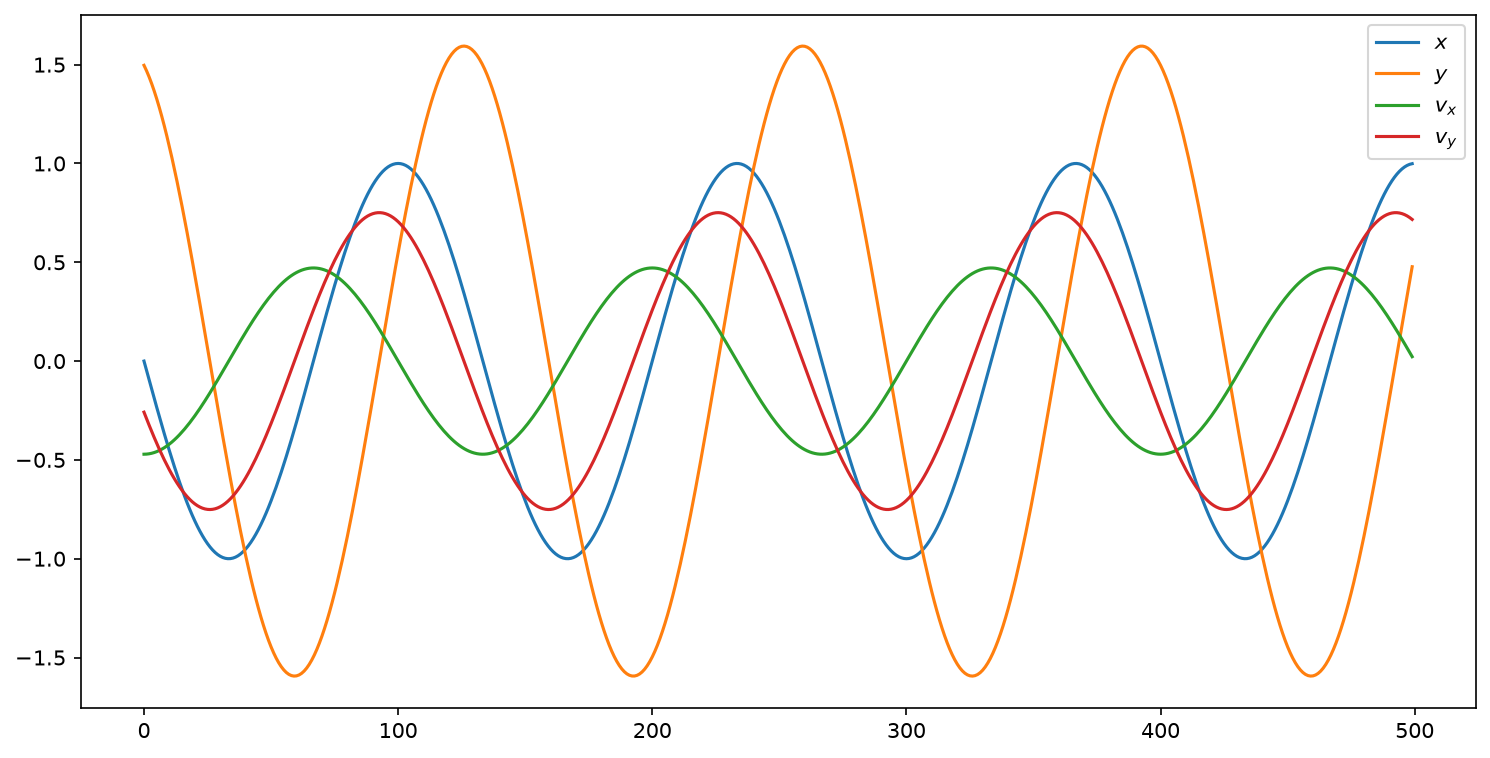

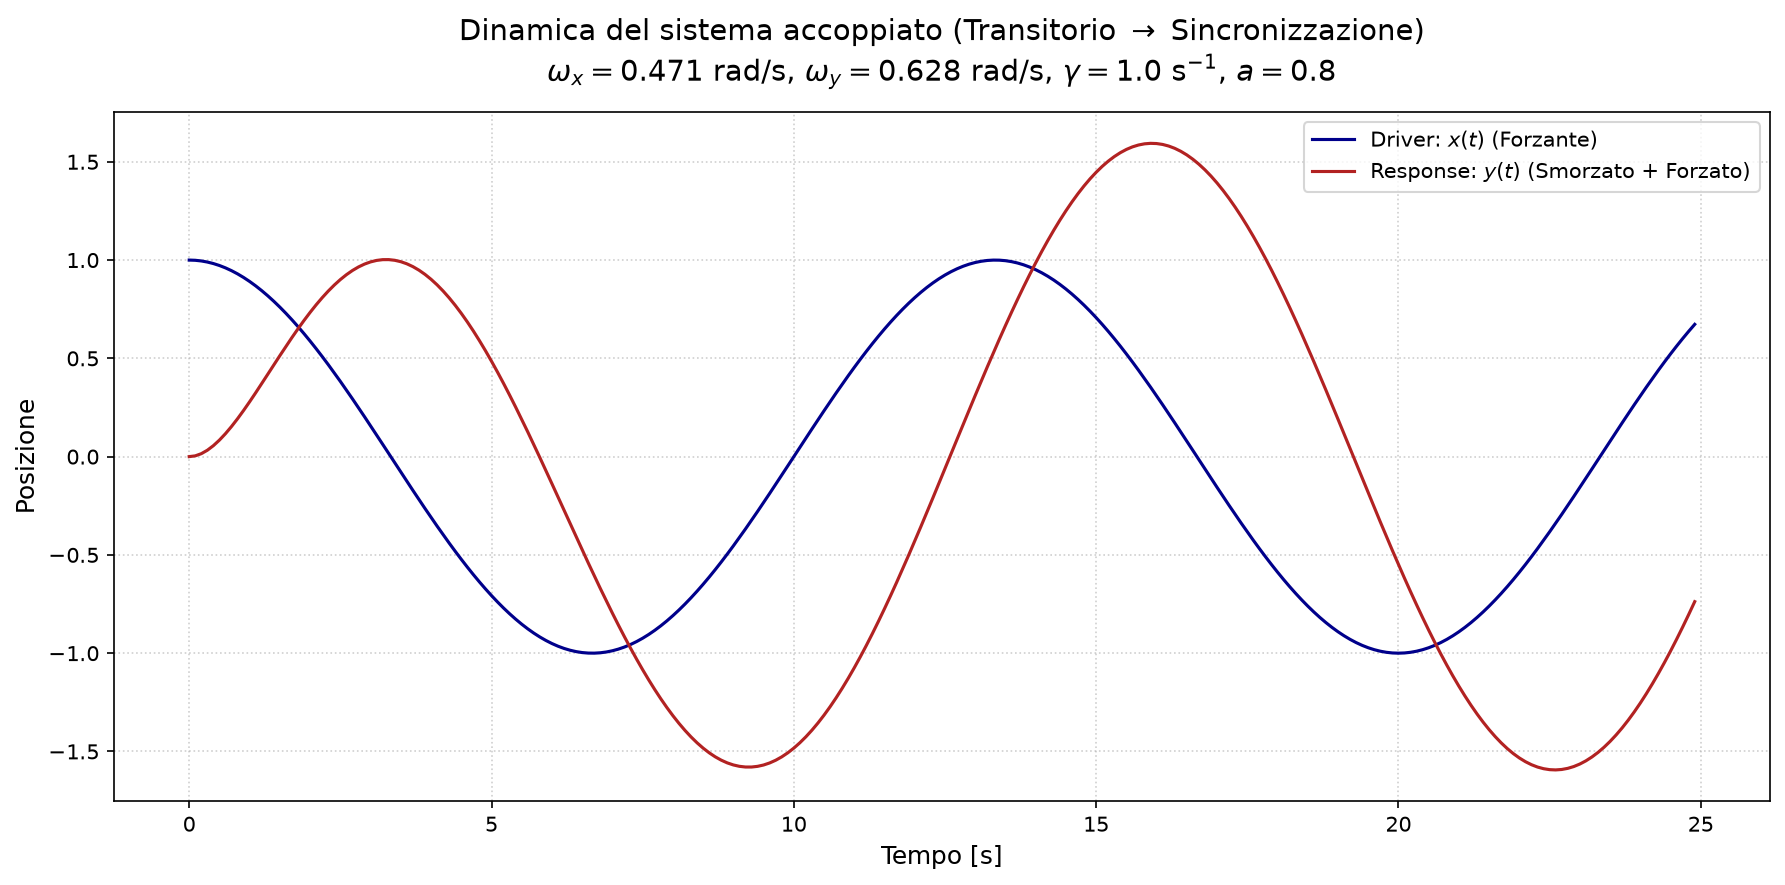

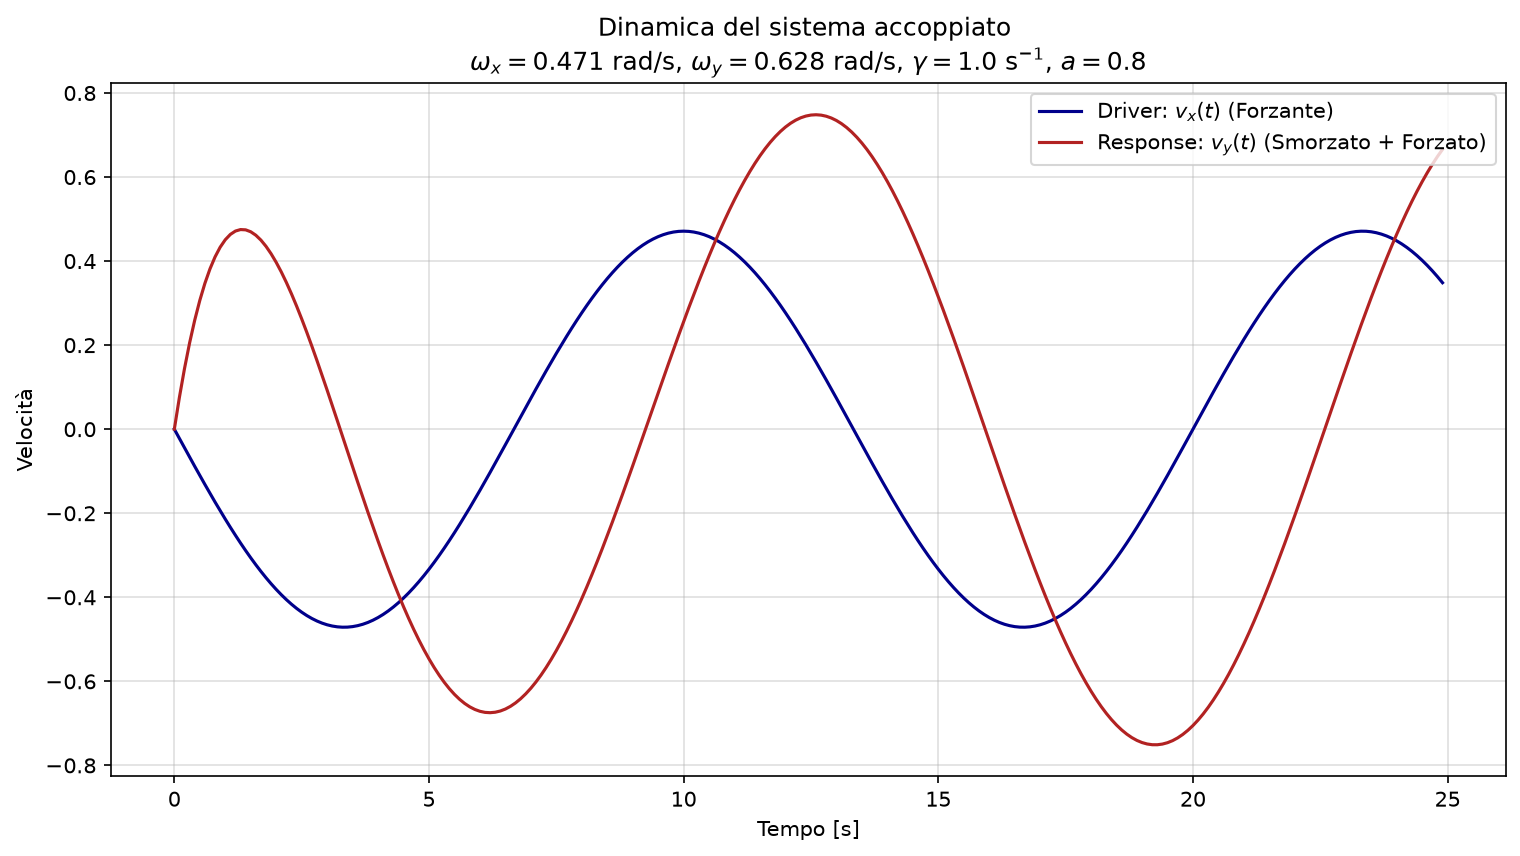

In [15]:
# =============================================================================
# 1. GENERAZIONE DATI: OSCILLATORE ACCOPPIATO (DRIVER-RESPONSE)
# =============================================================================
# Parametri del sistema
omega_x = 1.5 * np.pi * 0.1   # Pulsazione Driver 
omega_y = 2.0 * np.pi * 0.1   # Pulsazione Response
gamma = 1.0                   # Smorzamento Response (dissipazione)
a = 0.8                       # Accoppiamento (Driver -> Response)

dt = 0.1                      
t = np.arange(0.0, 1000.0, dt)

# Definiamo il sistema dinamico 4D ### MEGLIO USARE SOLUZIONE ANALITICA VERA
def oscillatore_accoppiato(stato, t, omega_x, omega_y, gamma, a):
    x, y, v_x, v_y = stato
    
    dxdt = v_x
    dydt = v_y
    dv_xdt = -(omega_x**2) * x
    dv_ydt = a * x - (omega_y**2) * y - gamma * v_y
    
    return [dxdt, dydt, dv_xdt, dv_ydt]

stato_iniziale = [1.0, 0.0, 0.0, 0.0]

# Integrazione numerica
u_integrato = odeint(oscillatore_accoppiato, stato_iniziale, t, args=(omega_x, omega_y, gamma, a))

# Splitting dei dati
n_spin, n_train, n_test = 100, 1000, 2000
i_spin, i_train, i_test = n_spin, n_train + n_spin, n_train + n_spin + n_test

# Il target è u_train
u_spin = u_integrato[:i_spin]
u_train  = u_integrato[i_spin:i_train]
u_test  = u_integrato[i_train:i_test]

# Visualizzazione rapida della fisica generata
plt.figure(figsize=(12, 6), dpi=150)
plt.plot(u_test[:500,:], label=["$x$", "$y$", "$v_x$", "$v_y$"])
plt.legend(loc='upper right', frameon=True)
plt.show()

plt.figure(figsize=(12, 6), dpi=150)
plt.plot(t[:250], u_integrato[:250, 0], color='darkblue', linewidth=1.5, label="Driver: $x(t)$ (Forzante)")
plt.plot(t[:250], u_integrato[:250, 1], color='firebrick', linewidth=1.5, label="Response: $y(t)$ (Smorzato + Forzato)")
plt.title(rf"""Dinamica del sistema accoppiato (Transitorio $\to$ Sincronizzazione)
$\omega_x={omega_x:.3f}$ rad/s, $\omega_y={omega_y:.3f}$ rad/s, $\gamma={gamma:.1f}$ s$^{{-1}}$, $a={a:.1f}$""", 
          fontsize=14, pad=15)
plt.xlabel("Tempo [s]", fontsize=12)
plt.ylabel("Posizione", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6), dpi=150)
plt.plot(t[:250], u_integrato[:250, 2], 'darkblue', label="Driver: $v_x(t)$ (Forzante)")
plt.plot(t[:250], u_integrato[:250, 3], 'firebrick', label="Response: $v_y(t)$ (Smorzato + Forzato)")
plt.title(rf"""Dinamica del sistema accoppiato 
$\omega_x={omega_x:.3f}$ rad/s, $\omega_y={omega_y:.3f}$ rad/s, $\gamma={gamma:.1f}$ s$^{{-1}}$, $a={a:.1f}$""")
plt.xlabel("Tempo [s]")
plt.ylabel("Velocità")
plt.legend(loc='upper right', frameon=True)
plt.grid(alpha=0.4)
plt.show()



# Setup della lRNN e funzioni della dinamica

Inizializzo gli iperparametri necessari per l'architettura del RC.

Creo le matrici necessarie: `W` è la matrice sinaptica, `Win` è la matrice di input e `b` è il vettore di bias.

In [16]:
# =============================================================================
# 2. INIZIALIZZAZIONE DEL RESERVOIR (lRNN)
# =============================================================================
N = 300      # Numero di neuroni
D = 4        # Dimensione dell'input/output
rho = 0.9    # Raggio spettrale
alpha = 0.9  # Leak rate
input_scaling = 1.0 

np.random.seed(42) ### fissato per fare debugging

# Matrice ricorrente W
W_raw = np.random.randn(N, N)
eigenvalues = np.linalg.eigvals(W_raw)
max_eigenvalue = np.max(np.abs(eigenvalues))
W = (W_raw / max_eigenvalue) * rho

# Matrice di input (Win) e bias (b)
Win = input_scaling * np.random.randn(N, D) / np.sqrt(N)
b = np.random.randn(N) / np.sqrt(N)

print(f"Shape di W: {W.shape}, Win: {Win.shape}, b: {b.shape}")

Shape di W: (300, 300), Win: (300, 4), b: (300,)


Implemento il singolo step e la dinamica guidata (open_loop) e autonoma (closed_loop).

Reservoir Computing con lRNN (ODE ed Euler discretization):
\begin{equation*}
\tau\frac{d\mathbf{h}(t)}{dt} = -\mathbf{h}(t) + \left( \mathbf{W} \mathbf{h}(t) + \mathbf{W}_{\text{in}} \mathbf{u}(t) + \mathbf{b} \right)
\end{equation*}

---

$$ \frac{\mathbf{h}_{t+1}-\mathbf{h}_t}{dt} = \frac{1}{\tau} (-\mathbf{h}_t + \mathbf{W}\mathbf{h}_t + \mathbf{W}_{\text{in}}\,\mathbf{u}_t + \mathbf{b})$$

$$ \mathbf{h}_{t+1} = \mathbf{h}_t + \frac{dt}{\tau} (-\mathbf{h}_t + \mathbf{W}\mathbf{h}_t + \mathbf{W}_{\text{in}}\,\mathbf{u}_t + \mathbf{b})$$

Definendo $\alpha=\frac{dt}{\tau}$ si ha infine:
$$\boxed{\mathbf{h}_{t+1} = (1 - \alpha)\,\mathbf{h}_t + \alpha\left( \mathbf{W} \mathbf{h}_t + \mathbf{W}_{\text{in}}\,\mathbf{u}_t + \mathbf{b} \right)}$$

In [17]:
# =============================================================================
# 3. LE FUNZIONI DELLA DINAMICA
# =============================================================================
def step_linear(h_t, u_t, W, Win, b, alpha):
    """
    Equazione di aggiornamento di stato discreto per una lRNN.
    """
    return (1 - alpha) * h_t + alpha * (W @ h_t + Win @ u_t + b)

def open_loop(u_seq, h_init, W, Win, b, alpha):
    """
    Fase di "ascolto": la rete è guidata (driven) dal segnale esterno u_seq.
    """
    h_states = []
    h = h_init
    for u in u_seq:
        h = step_linear(h, u, W, Win, b, alpha)
        h_states.append(h)
    return np.array(h_states)

def closed_loop(steps, h_init, Wout, W, Win, b, alpha):
    """
    Fase "predittiva": la rete si guida da sola. L'uscita diventa il nuovo input.
    """
    y_preds = []
    h = h_init
    for _ in range(steps):
        # Calcolo dell'uscita lineare
        y = Wout @ h
        y_preds.append(y)
        # Aggiornamento dello stato usando l'uscita appena predetta come input
        h = step_linear(h, y, W, Win, b, alpha)
    return np.array(y_preds)

# Addestramento, predizione temporale e confronto visivo

Faccio evolvere la rete con il set di spin-up (washout): i primissimi istanti dell'integrazione vengono fatti scorrere nella rete senza essere registrati. Questo permette di esaurire il transitorio di "accensione" artificiale dei neuroni (che partono da $\mathbf{h}_0 = \mathbf{0}$), assicurando che la matrice di output $\mathbf{W}_{\mathrm{out}}$ venga calcolata esclusivamente su stati interni già perfettamente sincronizzati con il respiro fisico del sistema.

Creo la serie temporale $\mathbf{H}\in\mathbb{R}^{T\times N}$ dello stato interno a partire dalla serie in input $\mathbf{X}$.

Alleno la matrice di output `Wout` mappando gli stati interni $H$ sui target successivi $Y$ tramite i minimi quadrati aggiungendo un parametro regolarizzante, ovvero applicando la regressione di Ridge:
$$\boldsymbol{\mathbf{W}_{\mathrm{out}}} = \mathbf{Y}^T\mathbf{H}\left(\mathbf{H}^T\mathbf{H}+\lambda\mathbf{I}\right)^{-1}$$

Faccio poi evolvere liberamente (in modo autonomo).

In [18]:
# =============================================================================
# 4. ADDESTRAMENTO (RIDGE REGRESSION) E PREDIZIONE TEMPORALE TIME-SHIFT
# =============================================================================
from sklearn.linear_model import ridge_regression

# 4.1 Fase di "riscaldamento" (spin-up) per sincronizzare il serbatoio 
# con lo stato finale prima del training
h_spin_states = open_loop(u_spin, np.zeros(N), W, Win, b, alpha)

# 4.2 Ascolto dei dati di training
h_train = open_loop(u_train, h_spin_states[-1], W, Win, b, alpha)

# Chiedo allo stato h[t] di prevedere il segnale x[t+1]
H_train_shifted = h_train[:-1]  # Prendo gli stati da 0 a T-1
Y_target_shifted = u_train[1:]  # Prendo i target da 1 a T

# 4.3 Calcolo di Wout tramite pseudo-inversa regolarizzata (Tikhonov)
Wout = ridge_regression(H_train_shifted, Y_target_shifted, 1e-10)

# 4.4 Predizione autonoma
y_pred = closed_loop(n_test, h_train[-1], Wout, W, Win, b, alpha)

(1000, 300) (999, 300)


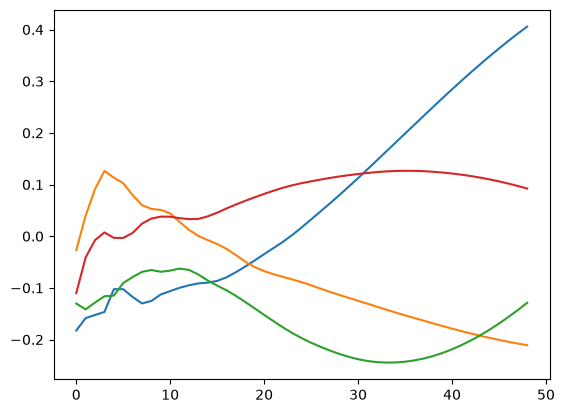

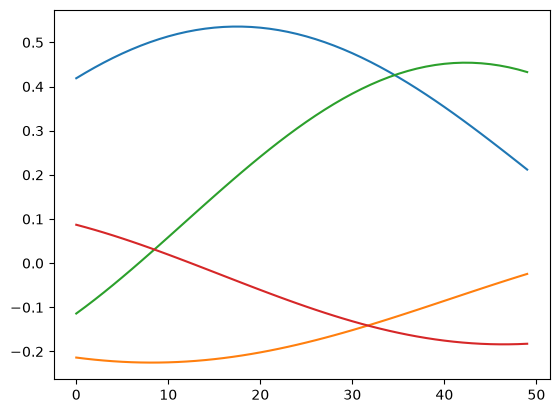

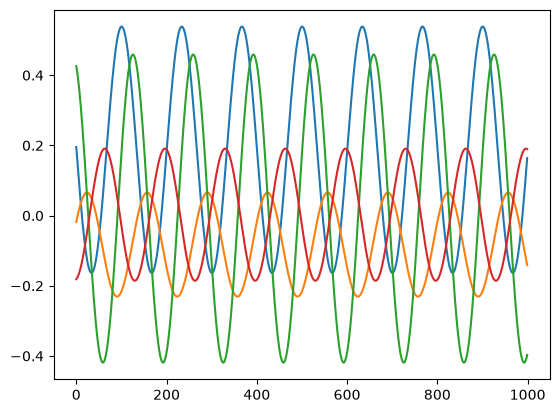

In [6]:
# Do un'occhiata allo stato interno

print(h_train.shape, H_train_shifted.shape)
plt.plot(h_spin_states[1:50, 1:5])
plt.show()
plt.plot(h_spin_states[50:100, 1:5])
plt.show()
plt.plot(h_train[:, 1:5])
plt.show()

Terminato l'addestramento, il sistema viene disconnesso dall'input esterno e lasciato evolvere liberamente (*closed-loop* o predizione autonoma). Se la rete ha implementato correttamente il generatore dinamico del sistema target, la sua evoluzione produrrà traiettorie stabili nello spazio delle fasi, senza divergere all'infinito (esplosione) né decadere a zero (smorzamento).

Comparo quindi l'output predetto con i dati di test.

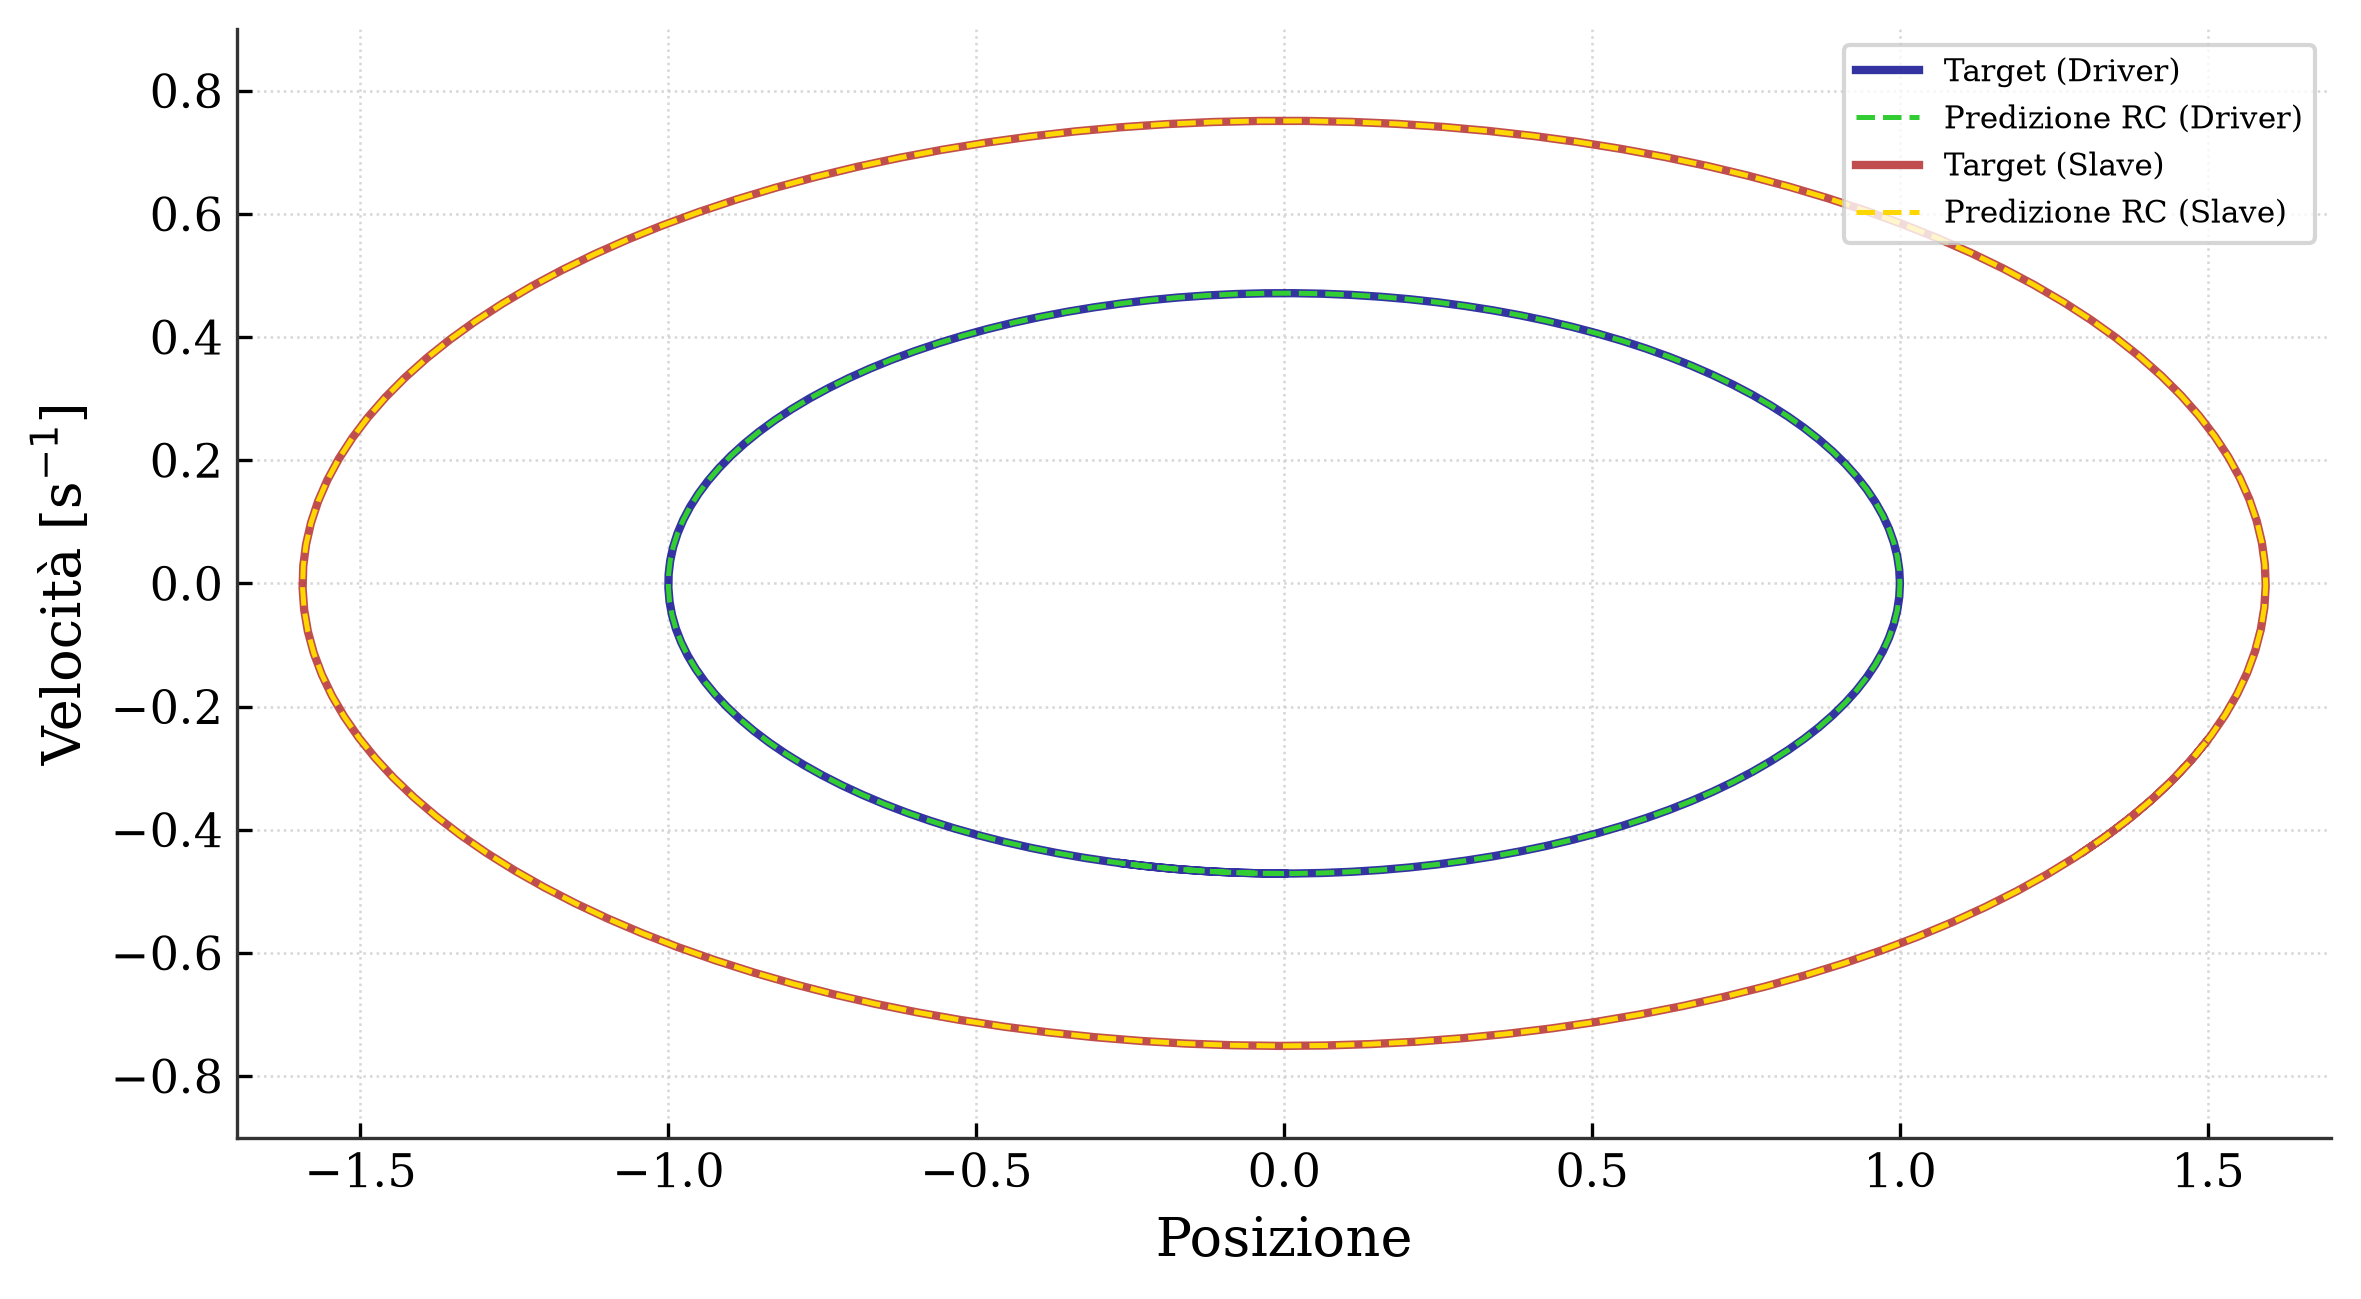

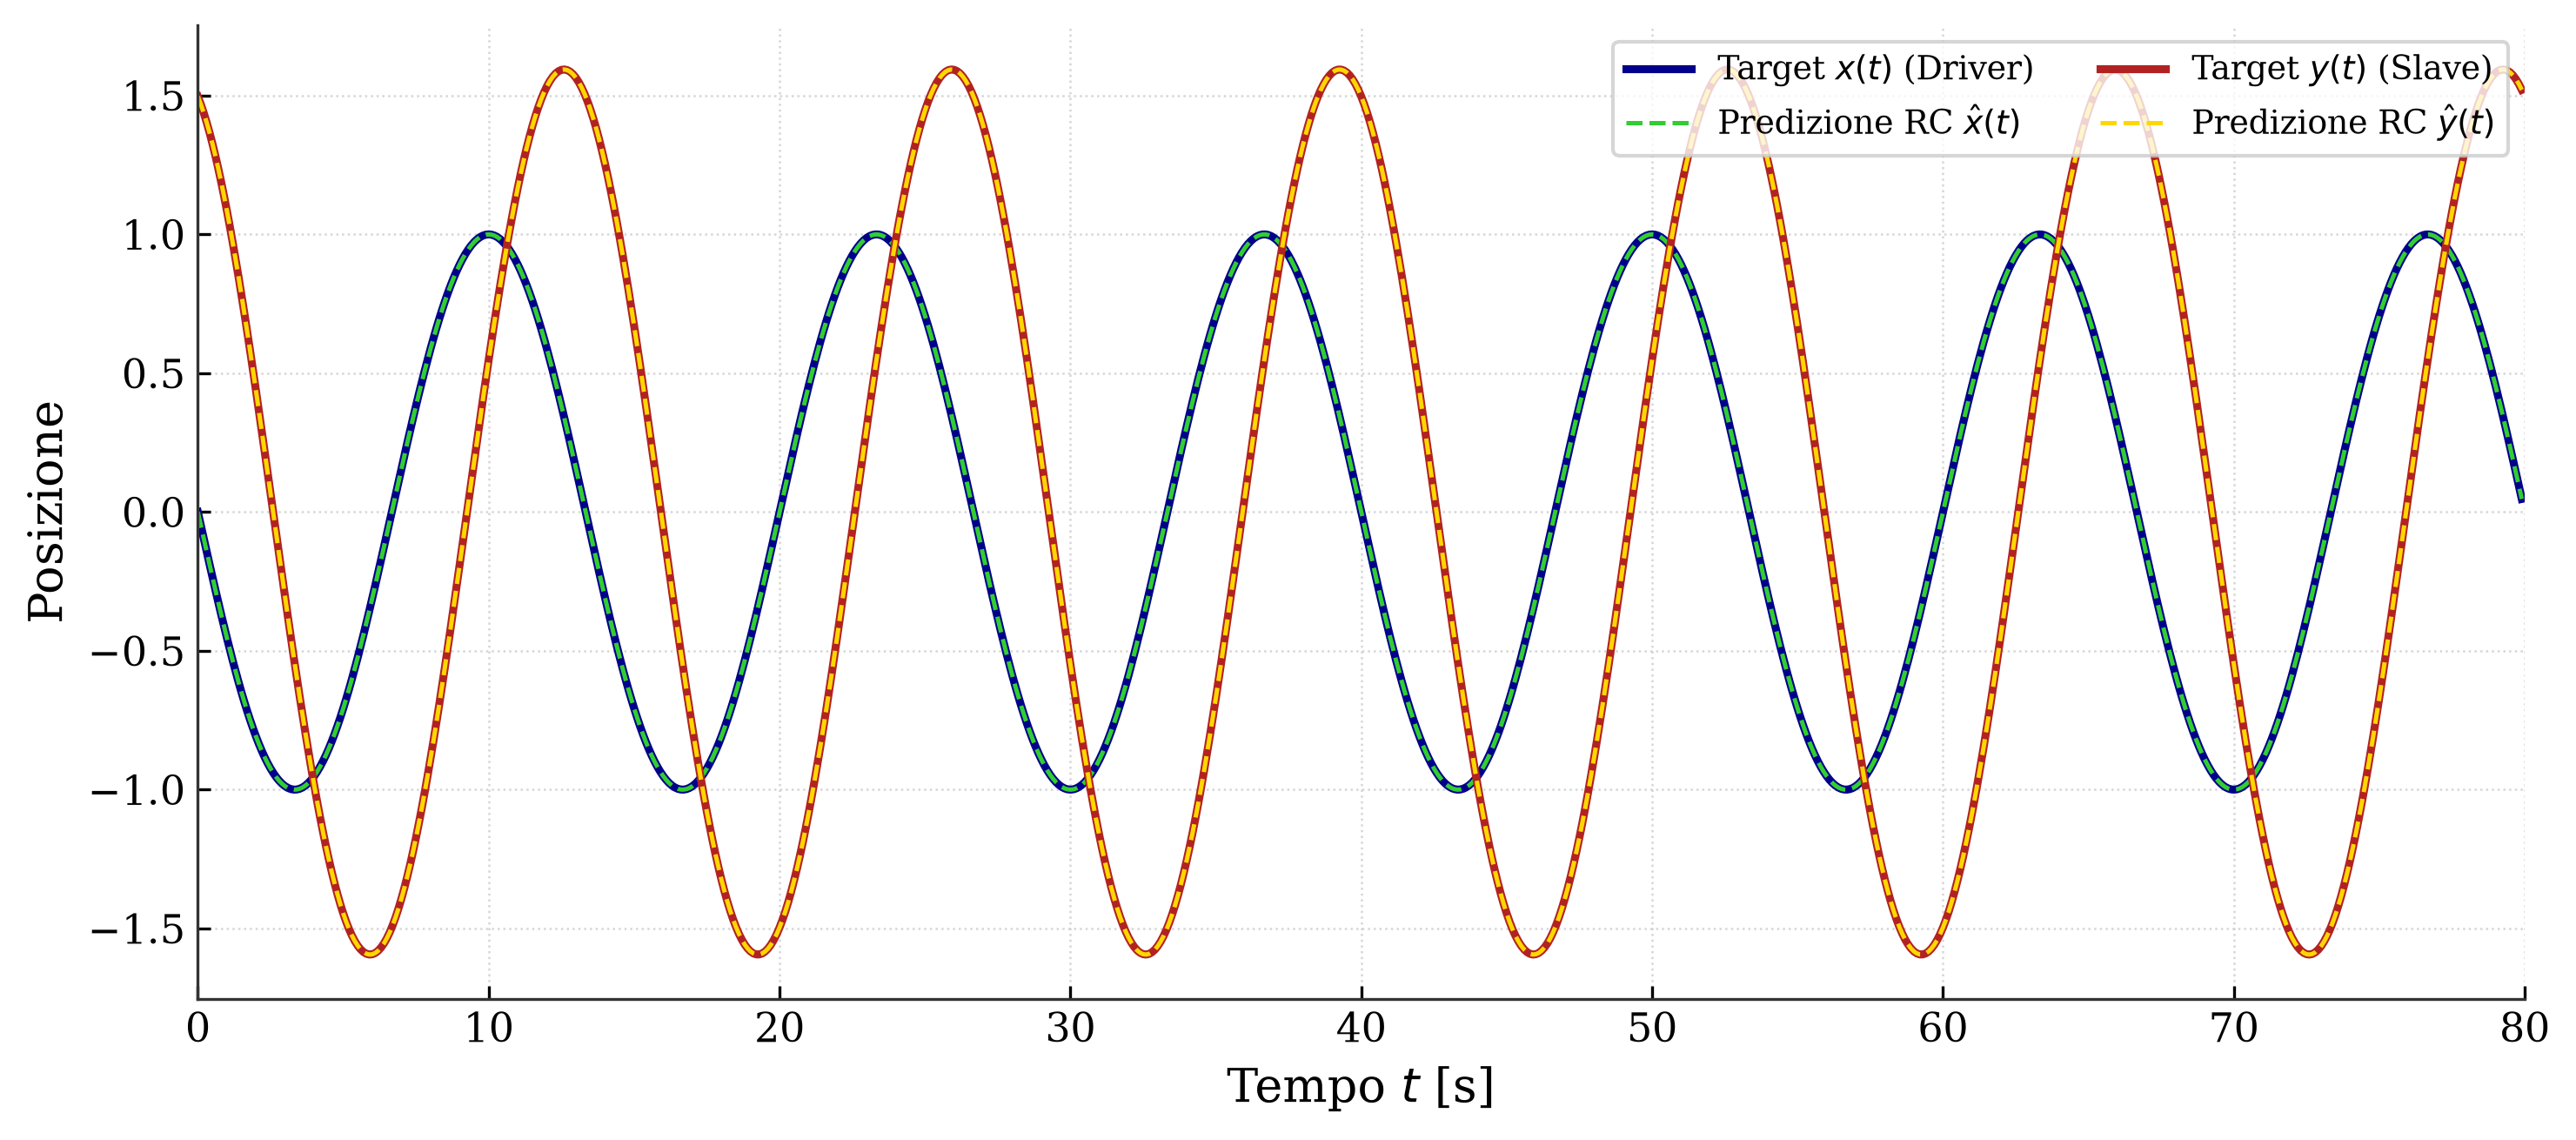

In [7]:
# =============================================================================
# 5. VISUALIZZAZIONE RISULTATI (SISTEMA ACCOPPIATO 4D - UNIFICATA)
# =============================================================================

# Configurazione parametri globali
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13         
plt.rcParams['xtick.labelsize'] = 11        
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['xtick.direction'] = 'in'   
plt.rcParams['ytick.direction'] = 'in'

# ---------------------------------------------------------
# GRAFICO A: SPAZIO DELLE FASI (Driver e Slave Insieme)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# Orbita del Driver (x vs v_x)
ax.plot(u_test[:140, 0], u_test[:140, 2], color='darkblue', linewidth=2.0, alpha=0.8, label='Target (Driver)')
ax.plot(y_pred[:140, 0], y_pred[:140, 2], color='limegreen', linewidth=1.2, linestyle='--', label='Predizione RC (Driver)')

# Orbita dello Slave (y vs v_y)
ax.plot(u_test[:140, 1], u_test[:140, 3], color='firebrick', linewidth=2.0, alpha=0.8, label='Target (Slave)')
ax.plot(y_pred[:135, 1], y_pred[:135, 3], color='gold', linewidth=1.2, linestyle='--', label='Predizione RC (Slave)')

ax.set_xlabel("Posizione")
ax.set_ylabel(r"Velocità [s$^{-1}$]")
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-0.9, 0.9)

ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.8, color='#cccccc', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper right', fontsize=7.5, frameon=True, facecolor='white')
plt.tight_layout()
#plt.savefig('spaziofasi_accoppiato.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRAFICO B: EVOLUZIONE TEMPORALE UNIFICATA (x(t) e y(t))
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=300)
time_test = np.arange(n_test) * dt # tempo fisico

# Evoluzione del Driver (x)
ax.plot(time_test[:800], u_test[:800, 0], color='darkblue', linestyle='-', linewidth=2.2, label='Target $x(t)$ (Driver)')
ax.plot(time_test[:800], y_pred[:800, 0], color='limegreen', linestyle='--', linewidth=1.2, label=r'Predizione RC $\hat{x}(t)$')

# Evoluzione dello Slave (y)
ax.plot(time_test[:800], u_test[:800, 1], color='firebrick', linestyle='-', linewidth=2.2, label='Target $y(t)$ (Slave)')
ax.plot(time_test[:800], y_pred[:800, 1], color='gold', linestyle='--', linewidth=1.2, label=r'Predizione RC $\hat{y}(t)$')

ax.set_xlabel("Tempo $t$ [s]")
ax.set_ylabel("Posizione")
ax.set_xlim(time_test[0], time_test[800])

ax.grid(True, linestyle=':', alpha=0.8, color='#cccccc', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legenda su due colonne (ncol=2) per farla più piatta e meno invasiva
ax.legend(loc='upper right', fontsize=9, frameon=True, facecolor='white', ncol=2)

plt.tight_layout()
#plt.savefig('traiettoria_accoppiato.pdf', dpi=300, bbox_inches='tight')
plt.show()

**Evoluzione Temporale e Spazio delle Fasi (regime stazionario):** 
Nei primi due grafici, valutati sul set di *test*, osserviamo il sistema ben oltre la fine della fase transiente. L'energia dissipativa dello Slave si è esaurita e il sottosistema è ora completamente trascinato dalla forzante. Entrambi gli oscillatori descrivono orbite ellittiche chiuse e stabili (pur con ampiezze e fasi differenti). Le predizioni del Reservoir (linee tratteggiate) si sovrappongono in modo esatto alle traiettorie analitiche target: la rete ha implementato il generatore armonico senza mostrare alcuna deriva di fase o divergenza di ampiezza a lungo termine.

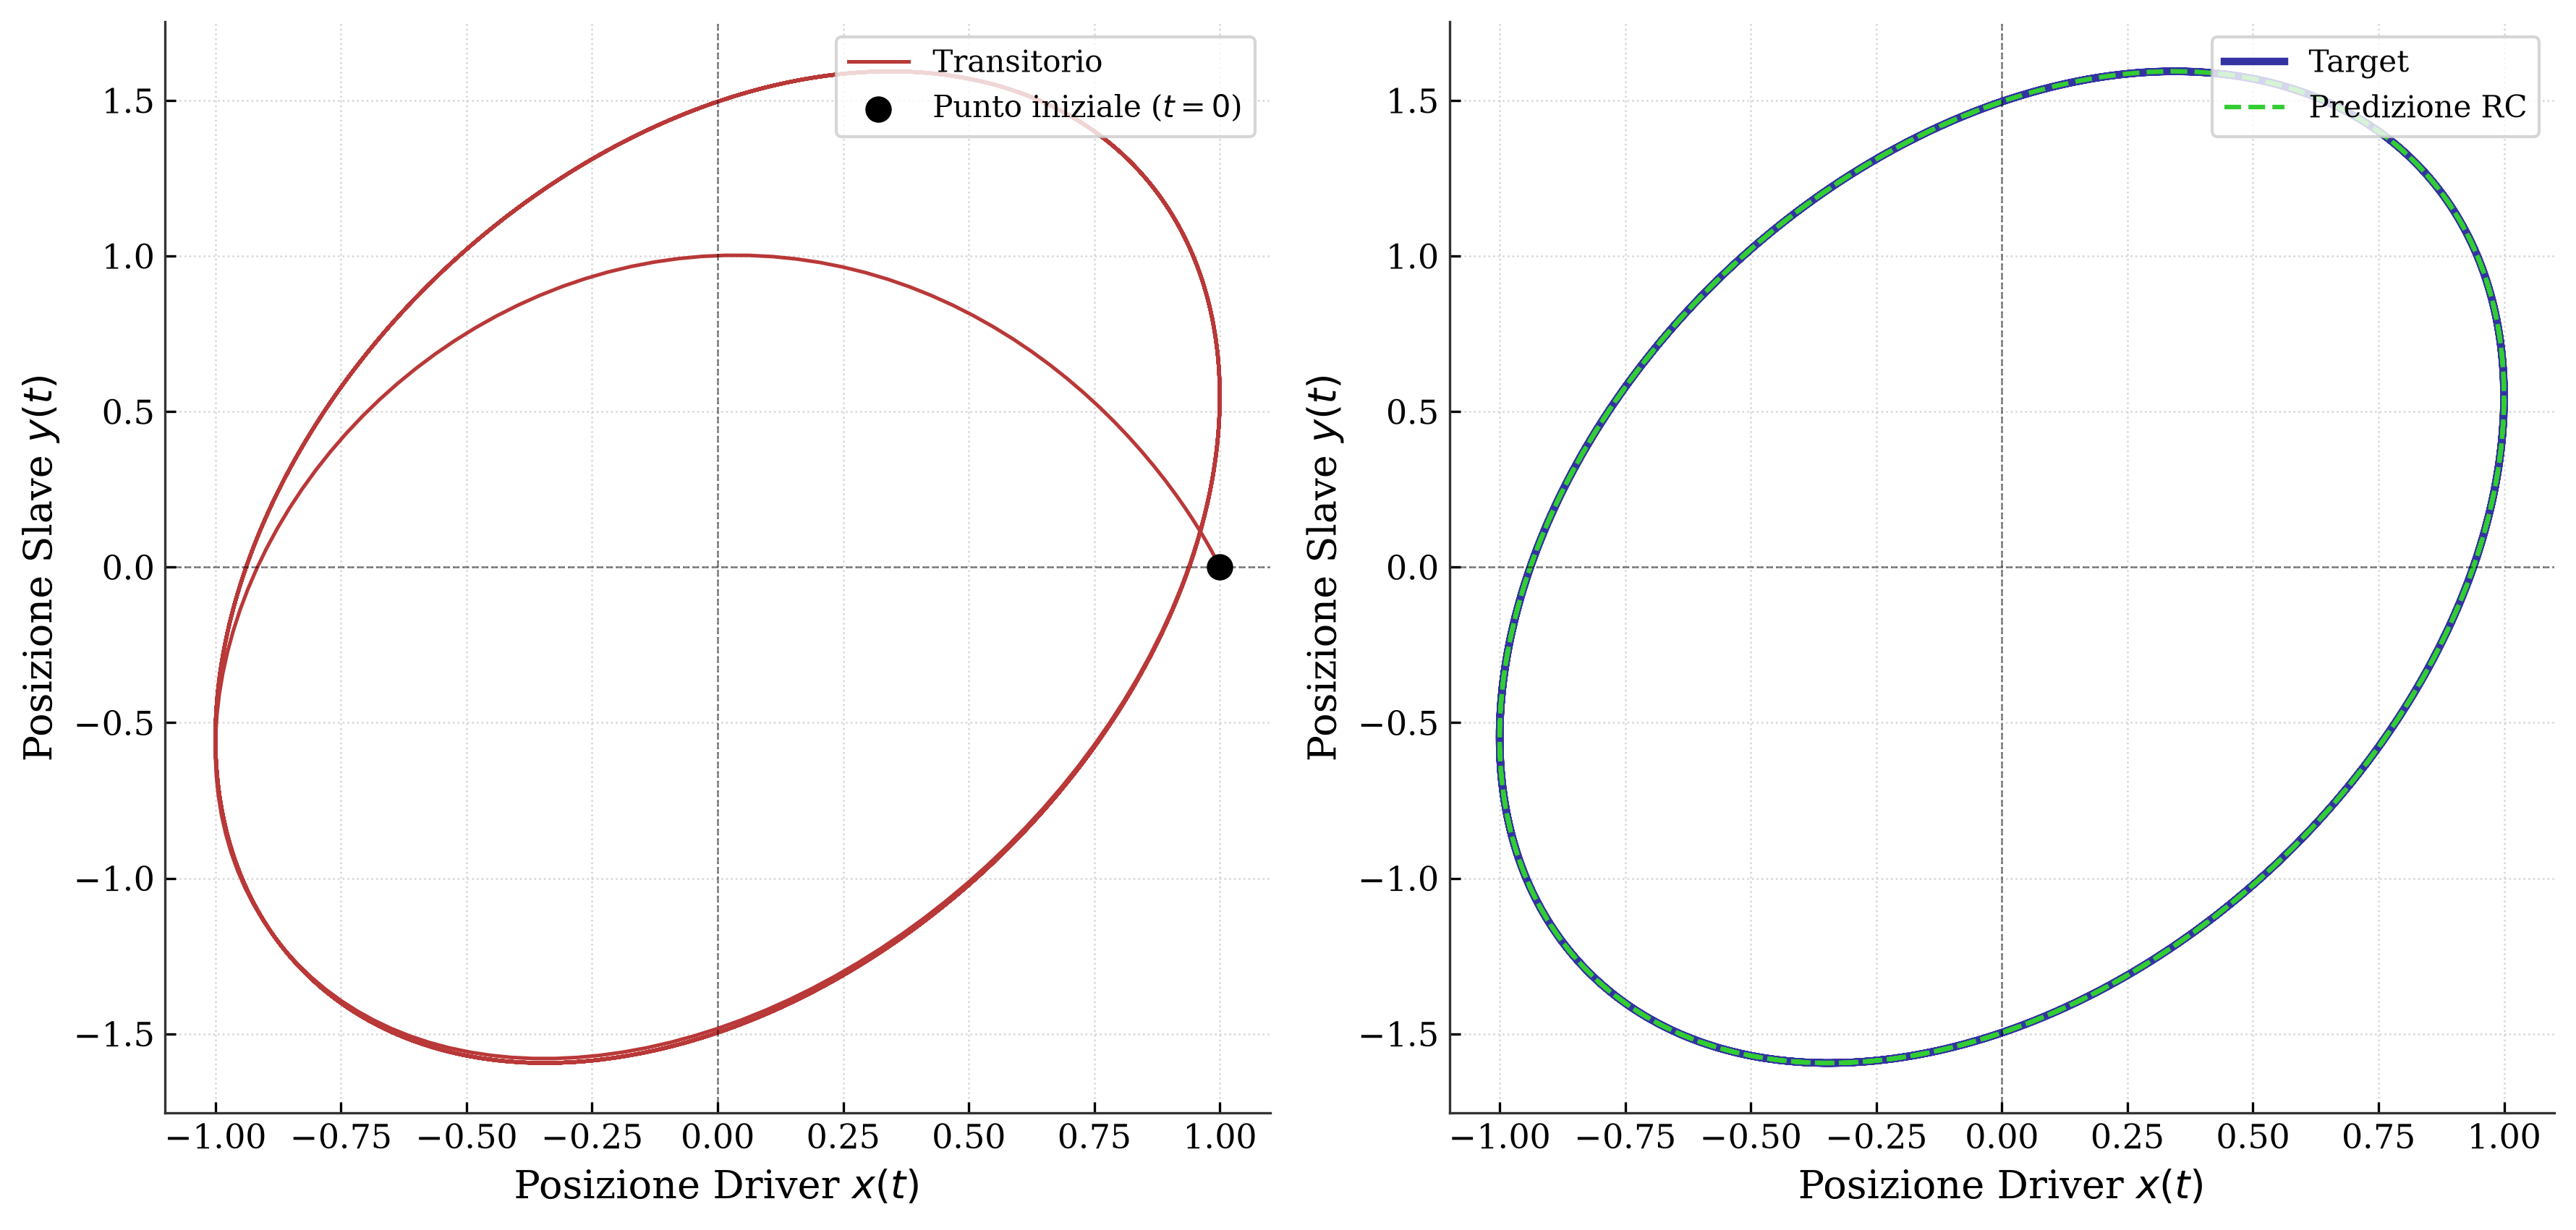

In [8]:
# =============================================================================
# GRAFICO C: ANALISI DELLO SPAZIO DELLE CONFIGURAZIONI (Driver vs Slave) + TRANSITORIO INIZIALE - FIGURA DI LISSAJOUS
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.8), dpi=300)

# -----------------------------------------------------------------------------
# PANNELLO 1: IL TRANSITORIO INIZIALE
# -----------------------------------------------------------------------------
punti_iniziali = 1500

# Plottiamo la traiettoria del transitorio
ax1.plot(u_integrato[:punti_iniziali, 0], u_integrato[:punti_iniziali, 1], 
         color='firebrick', linewidth=1.2, alpha=0.9, label='Transitorio')

# Evidenziamo il punto di partenza esatto (t=0)
ax1.scatter(u_integrato[0, 0], u_integrato[0, 1], 
            color='black', s=60, zorder=5, label='Punto iniziale ($t=0$)')

ax1.set_xlabel("Posizione Driver $x(t)$", fontsize=13)
ax1.set_ylabel("Posizione Slave $y(t)$", fontsize=13)

ax1.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax1.axvline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax1.grid(True, linestyle=':', alpha=0.8, color='#cccccc', linewidth=0.6)

#ax1.set_aspect('equal', adjustable='box')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white')

# -----------------------------------------------------------------------------
# PANNELLO 2: STATO STAZIONARIO (TARGET VS PREDIZIONE RC)
# -----------------------------------------------------------------------------
punti_plot = 500

# Orbita permanente Target e Predizione
ax2.plot(u_test[:punti_plot, 0], u_test[:punti_plot, 1], 
         color='darkblue', linewidth=2.5, alpha=0.8, label='Target')

ax2.plot(y_pred[:250, 0], y_pred[:250, 1], 
         color='limegreen', linestyle='--', linewidth=1.5, label='Predizione RC')

ax2.set_xlabel("Posizione Driver $x(t)$", fontsize=13)
ax2.set_ylabel("Posizione Slave $y(t)$", fontsize=13)

ax2.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax2.axvline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax2.grid(True, linestyle=':', alpha=0.8, color='#cccccc', linewidth=0.6)

#ax2.set_aspect('equal', adjustable='box')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white')

plt.tight_layout()
#plt.savefig('analisi_configurazioni_lissajous.pdf', dpi=300, bbox_inches='tight')
plt.show()


**Spazio delle configurazioni:**
L'analisi di Driver $x$ vs Slave $y$ illustra la riduzione dei gradi di libertà del sistema nel tempo:

1. **Il transitorio iniziale (a sinistra):** A partire dall'istante $t=0$, lo stato dello Slave è governato dalla sovrapposizione lineare tra la propria risposta libera smorzata ($\omega_y, \gamma$) e la risposta forzata ($\omega_x$). In questa finestra temporale il sistema esprime pienamente l'informazione del suo spazio delle fasi a 4 dimensioni, generando una traiettoria a spirale asimmetrica.

2. **Lo stato stazionario (a destra):** Decaduta la componente transiente, la dinamica del sistema collassa su una varietà a dimensionalità ridotta (2D). Lo Slave oscilla a regime esclusivamente alla frequenza del Driver, producendo un'orbita chiusa.

Questa separazione visiva rappresenta la giustificazione fisica delle successive scelte analitiche per l'estrazione spettrale. Un'indagine condotta sui dati a regime (dove l'orbita è confinata in 2D) estrarrà unicamente le *Mode Strengths* dei poli conservativi, rendendo la dinamica smorzata "invisibile". Per svelare l'intero spettro Jacobiano 4D, l'algoritmo di decomposizione modale dovrà necessariamente essere applicato alla finestra temporale contenente il transitorio iniziale.

# Inferenza spettrale

L'obiettivo dell'analisi spettrale è confrontare la dinamica lineare del sistema teorico con quella appresa dalla lRNN in modalità *closed-loop*. A partire dalla matrice di evoluzione discreta effettiva del reservoir si determinano gli autovalori discreti e, mediante la mappatura logaritmica, i corrispondenti autovalori nel dominio continuo.

#### Dal dominio discreto al dominio continuo
Gli autovalori $\lambda_{D,i}$ appartengono all'operatore di evoluzione discreto della lRNN. Per confrontarli con gli autovalori del generatore continuo del sistema fisico, utilizziamo la mappatura logaritmica esatta:
$$\boxed{ \lambda_{C,i} = \frac{\operatorname{ln}(\lambda_{D,i})}{\Delta t} }.$$
Qui $\operatorname{ln}$ denota il ramo principale del logaritmo complesso. La relazione è esatta nel senso che associa al propagatore discreto $\mathbf{W}_{\mathrm{eff}}^D$ il corrispondente generatore continuo equivalente; non implica, di per sé, che tale generatore coincida esattamente con il generatore fisico originale. Nel seguito gli autovalori $\lambda_{C,i}$ ricavati dal reservoir vengono confrontati con gli autovalori teorici della matrice dinamica del sistema fisico $\mathbf{A}$.

## Decomposizione modale e calcolo delle Mode Strengths: raffinamenti

Poiché il reservoir opera in uno spazio di dimensione elevata ($N=300$), la sua dinamica closed-loop genera in generale un insieme di $N$ autovalori. Solo una parte di questi è associata alla dinamica del sistema target, mentre gli altri possono rappresentare gradi di libertà ridondanti del reservoir. Per identificare i modi rilevanti non è quindi sufficiente considerare la sola posizione degli autovalori: è necessario quantificare anche quanto ciascun modo sia eccitato e quanto contribuisca all'osservabile ricostruita.

A questo scopo introduciamo la Mode Strength, ottenuta dalla decomposizione modale dello stato interno del reservoir e dalla successiva proiezione dei singoli modi nello spazio di output.

Rispetto al caso dell'oscillatore armonico semplice, nel quale i modi fisici sono puramente oscillatori e persistenti, il sistema accoppiato considerato nel presente notebook contiene sia modi persistenti sia modi dissipativi transitori. Inoltre, la presenza del termine di bias rende la dinamica closed-loop affine. Queste caratteristiche richiedono una formulazione più generale e raffinata della decomposizione modale e una definizione della rilevanza dei modi che tenga conto della loro evoluzione temporale.

### Dinamica affine (bias) e traslazione rispetto al punto fisso

In modalità *closed-loop*, l'output del reservoir $\mathbf{u}_t=\mathbf{W}_{\mathrm{out}}\mathbf{h}_t$ viene reiniettato in ingresso. L'equazione di aggiornamento di stato discreto per una lRNN diventa quindi
$$ \mathbf{h}_{t+1} = \mathbf{W_{eff}^D}\mathbf{h}_t+\mathbf{d} $$

dove 
$$ \mathbf{W_{eff}^D} = \mathbf{I} + \alpha \left(\mathbf{W} + \mathbf{W}_{\mathrm{in}}\mathbf{W}_{\mathrm{out}} - \mathbf{I} \right) $$
è la matrice efficace discreta, mentre
$$ \mathbf{d}=\alpha\mathbf{b} $$
rappresenta il termine costante associato al bias.

La presenza di $\mathbf{d}$ rende la dinamica affine anziché lineare rispetto all'origine; in particolare, l'origine non costituisce in generale un punto fisso.
Gli autovalori della matrice $\mathbf{W}_{\mathrm{eff}}^D$ continuano tuttavia a determinare l'evoluzione delle perturbazioni attorno al punto di equilibrio; il termine costante $\mathbf{d}$ determina invece la posizione di tale equilibrio.

Per separare la componente dinamica dalle traslazioni statiche introdotte dal bias, consideriamo il punto fisso $\mathbf{h}^*$ della dinamica affine, definito da $\mathbf{h}^*=\mathbf{W_{eff}^D}\mathbf{h}^*+\mathbf{d},$ e quindi

$$\boxed{\mathbf{h}^*=(\mathbf{I}-\mathbf{W}_{\mathrm{{eff}}^D})^{-1}\mathbf{d}}.$$

Introducendo la variabile traslata

$$\delta\mathbf{h}_t=\mathbf{h}_t-\mathbf{h}^*$$

si ottiene una dinamica lineare omogenea:

$$\delta\mathbf{h}_{t+1}=\mathbf{W}_{\mathrm{{eff}}^D}\,\delta\mathbf{h}_t.$$

È rispetto a questa variabile traslata, e non rispetto allo stato assoluto $\mathbf{h}_t$, che viene effettuata la decomposizione modale. La motivazione di questa scelta diventa evidente, infatti, considerando la forma generale della soluzione; lo stato assoluto, una volta introdotto il punto fisso, può essere scritto come sovrapposizione tra l'equilibrio e l'evoluzione temporale delle perturbazioni:

$$\mathbf{h}_t = \mathbf{h}^* + \delta\mathbf{h}_t = \mathbf{h}^* + \sum_{i=1}^N c_i(0) \lambda_{D,i}^t \mathbf{v}_i$$

dove $\lambda_{D,i}$ e $\mathbf{v}_i$ sono rispettivamente gli autovalori e gli autovettori di $\mathbf{W}_{\text{eff}}^D$, mentre $c_i(0)$ sono i coefficienti di eccitazione iniziali. 

Se, al contrario, si decomponesse direttamente lo stato assoluto $\mathbf{h}_t$ sugli autovettori di $\mathbf{W}_{\mathrm{eff}}^D$, i coefficienti modali dovrebbero rappresentare non solo la componente dinamica, ma anche il contributo statico $\mathbf{h}^*$, che tuttavia non è un modo dinamico associato agli autovalori di $\mathbf{W}_{\mathrm{eff}}^D$. Questo problema è particolarmente critico per i modi dissipativi: per $\vert{}\lambda_{D,i}\vert{}<1$, i contributi dinamici $c_i(0)\lambda_{D,i}^t\mathbf{v}_i$ tendono a zero per $t\rightarrow\infty$, mentre lo stato completo tende al valore non nullo $\mathbf{h}^*$. Un offset costante non può essere rappresentato asintoticamente come combinazione di soli modi dissipativi; forzare questa scomposizione rischia quindi di contaminare i coefficienti modali, facendo apparire come dinamicamente rilevanti modi che stanno invece compensando l'offset.

A questo punto consideriamo la decomposizione spettrale dell'operatore discreto

$$\mathbf{W}_{\mathrm{eff}}^D\mathbf{V} = \mathbf{V}\mathbf{\Lambda},$$
con
$$\mathbf{\Lambda} = \mathrm{diag}(\lambda_{D,1},\ldots,\lambda_{D,N})$$
dove $\lambda_{D,i}$ sono gli autovalori dell'operatore discreto closed-loop e $\mathbf{V}$ contiene i corrispondenti autovettori destri.
Assumendo che $\mathbf{W}_{\text{eff}}^D$ sia diagonalizzabile, lo stato traslato può essere espresso nella base modale come
$$\delta\mathbf{h}_t = \mathbf{V}\mathbf{c}(t)$$
con coefficienti modali
$$\boxed{ \mathbf{c}(t) = \mathbf{V}^{-1}\delta\mathbf{h}_t }.$$
Il coefficiente $c_i(t)$ misura quindi esclusivamente l'attivazione dell' i-esimo modo nello stato interno al tempo $t$. 

### Mode Strengths calcolate come media temporale
La rilevanza di un modo per l'osservabile ricostruita dipende da due fattori distinti: dalla sua eccitabilità nello stato interno, quantificata dal coefficiente modale $c_i(t)$; dalla sua osservabilità attraverso il readout, quantificata dalla proiezione del corrispondente autovettore nello spazio di output. Nel caso del reservoir, la matrice di osservazione è la matrice di readout $\mathbf{W}_{\mathrm{out}}\in\mathbb{R}^{d\times N}$.  

La Mode Strength istantanea si definisce pertanto come il prodotto tra l'eccitabilità del modo e il suo fattore di readout:
$$S_i(t) = \vert{}c_i(t)\vert{}\,\Vert{}\mathbf{W}_{\mathrm{out}}\mathbf{v}_i\Vert{}_2.$$
Nella trattazione sull'oscillatore armonico semplice, è stato introdotto il vettore ampiezza modale $\boldsymbol{\xi}_i(t) = c_i(t)(\mathbf{W}_{\mathrm{out}}\mathbf{v}_i)$. La Mode Strength istantanea si definisce pertanto come la norma euclidea di tale vettore, ovvero il prodotto tra l'eccitabilità del modo e il suo fattore di osservabilità:
$$S_i(t) = \Vert{}\boldsymbol{\xi}_i(t)\Vert{}_2 = \vert{}c_i(t)\vert{}\,\Vert{}\mathbf{W}_{\mathrm{out}}\mathbf{v}_i\Vert{}_2$$

Nei sistemi puramente conservativi questa definizione è sufficiente, poiché i coefficienti di attivazione $\vert{}c_i(t)\vert{}$ restano costanti nel tempo (valutabili a un singolo istante, ad esempio all'inizio della traiettoria $\mathbf{c} = \mathbf{V}^{-1}\mathbf{h}(0)$). 

Nel sistema accoppiato, invece, coesistono modi persistenti e modi dissipativi. La Mode Strength istantanea dipende quindi dalla scelta dell'istante di osservazione: i modi con parte reale negativa possono risultare fortemente eccitati all'inizio della traiettoria e diventare trascurabili a tempi successivi.

Per ottenere una quantità rappresentativa dell'intera finestra temporale analizzata e coerente con la funzione di costo dell'algoritmo di regressione (che minimizza l'errore sull'intero intervallo), definiamo quindi la Mode Strength mediata nel tempo:
$$\boxed{ \overline{S}_i = \Vert{}\mathbf{W}_{\text{out}}\mathbf{v}_i\Vert{}_2 \left( \frac{1}{T} \sum_{t=1}^{T} \vert{}c_i(t)\vert{} \right) }$$

### Mode Strengths teoriche e ground truth

Per valutare la misura analitica del peso spettrale di ciascun polo del sistema originale, calcoliamo una quantità analoga teorica, proiettando la traiettoria analitica $\mathbf{u}(t)$ sugli autovettori della matrice Jacobiana $\mathbf{A}$. Questo fornisce un *ground truth* che fissa la scala cromatica comune delle Mode Strengths in tutte le successive *heat map*, rendendo confrontabili visivamente i poli del reservoir con quelli teorici, senza normalizzare separatamente teoria e reservoir.

Considerando

$$
\mathbf{A}\mathbf{V}_A
=
\mathbf{V}_A\mathbf{\Lambda}_A
$$

la decomposizione spettrale della matrice dinamica continua del sistema fisico. Per la traiettoria $\mathbf{u}(t)$, otteniamo i coefficienti modali teorici come

$$
\mathbf{c}_A(t)
=
\mathbf{V}_A^{-1}
\left[
\mathbf{u}(t)-\mathbf{u}^*
\right].
$$

Nel sistema fisico considerato non è presente un termine costante, pertanto il punto fisso è

$$
\mathbf{u}^*=\mathbf{0}.
$$

Applicando la stessa definizione temporale delle Mode Strengths, otteniamo

$$
\boxed{
\overline{S}_{A,i}
=
\|\mathbf{O}_A\,\mathbf{v}_{A,i}\|_2
\left(
\frac{1}{T}
\sum_{t=1}^{T}
|c_{A,i}(t)|
\right)}
$$

dove $\mathbf{O}_A$ rappresenta la matrice di osservazione teorica considerata (es. la matrice identità per il sistema completo o un vettore di selezione per l'ablazione spaziale).

## Ruolo della finestra temporale: regime e transitorio

In un sistema parzialmente dissipativo, la quantità di informazione disponibile per l'inferenza dipende criticamente dalla finestra temporale utilizzata per l'addestramento. L'analisi successiva viene quindi svolta spostando la finestra di training dal regime al transitorio, in primo luogo fornendo in input l'intero stato $\mathbf{r}(t)$, poi, ad ultimo, fornendo una sola osservabile scalare $y(t)$.

#### Inferenza a regime: con spin-up
Dopo uno spin-up sufficientemente lungo, i contributi associati ai modi dissipativi decadono come $e^{-\gamma t/2}$ e diventano trascurabili. La risposta dello Slave è quindi dominata dalla componente forzata alla frequenza del Driver $\omega_x$.
La dinamica osservata durante il regime asintotico è pertanto caratterizzata prevalentemente dalla coppia di autovalori $\lambda=\pm i\omega_x$.
In questa configurazione, i modi dissipativi risultano scarsamente eccitati nella finestra di training e la loro Mode Strength teorica tende a zero all'aumentare del tempo di osservazione.

#### Inferenza sul transitorio: senza spin-up
Per studiare anche i modi dissipativi, la rete viene invece inizializzata a $\mathbf{h}_0=\mathbf{0}$ e addestrata direttamente sui dati a partire da $t=0$, includendo quindi la fase transitoria della dinamica fisica.
In questa finestra sono simultaneamente presenti la componente persistente associata al Driver e le componenti transitorie associate alla dinamica naturale smorzata dello Slave.

In [19]:
# =============================================================================
# 6. INFERENZA SPETTRALE (Decomposizione modale e mode strengths 4D)
# =============================================================================

### CALCOLO DELLA DECOMPOSIZIONE MODALE MEDIATA NEL TEMPO ###

def compute_time_averaged_mode_strengths(V, trajectory, fixed_point, observation_matrix):
    """
    Calcola la Mode Strength mediata nel tempo: S_k = || Obs @ V_k || * (1/T sum |c_k(t)|)
    
    Parametri:
    - V: Matrice degli autovettori (N x N per la rete, 4 x 4 per la teoria)
    - trajectory: Serie temporale degli stati (T x N per la rete, T x 4 per la teoria)
    - fixed_point: Vettore del punto fisso (h_star per la rete, array di zeri per la teoria)
    - observation_matrix: Matrice di mappatura verso l'output (Wout per la rete, Identità per teoria 4D, vettore [0,1,0,0] per teoria 1D)
    """
    T = trajectory.shape[0]
    
   # 1. Spostamento dal punto fisso e trasposizione -> shape: (Dimensioni, T)
    delta_traj = (trajectory - fixed_point).T
    
   # 2. Proiezione per ottenere l'evoluzione temporale dei coefficienti c_k(t)
    C_t = la.solve(V, delta_traj)
    
   # 3. Attivazione Temporale Media: 1/T * sum(|c_k(t)|) lungo il tempo
    avg_temporal_activation = np.mean(np.abs(C_t), axis=1)
    
   # 4. Guadagno Spaziale: || Obs @ V_k ||
    spatial_gain = np.linalg.norm(observation_matrix @ V, axis=0)
    
   # 5. Mode Strength finale (prodotto elemento per elemento)
    S_k = spatial_gain * avg_temporal_activation
    
    return S_k

# 1. Sistema originario (teorico continuo) - Matrice Jacobiana 4x4
A = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [-omega_x**2, 0, 0, 0],
    [a, -omega_y**2, 0, -gamma]
])

# 2. Calcolo MODE STRENGTHS degli autovalori TEORICI
lambda_A, V_A = la.eig(A)
#c_A = la.solve(V_A, u_train[-1])
#mode_strengths_A = V_A @ np.diag(c_A)
#S_A = np.linalg.norm(mode_strengths_A, axis=0)

### Calcolo MEDIATO NEL TEMPO
S_A = compute_time_averaged_mode_strengths(V=V_A, 
                                           trajectory=u_train, 
                                           fixed_point=np.zeros(4), 
                                           observation_matrix=np.eye(4))

# 3. Reservoir libero (per riferimento visivo)
I = np.identity(N)
tau = dt / alpha
W_free_C = (W - I) / tau
lambda_W_free_C = la.eigvals(W_free_C)

# 4. Propagatore discreto accoppiato e mappatura esatta al continuo
W_tot = W + Win @ Wout
W_eff_D = I + alpha * (W_tot - I)
lambda_D, V = la.eig(W_eff_D)
# Applichiamo il logaritmo per ritornare al dominio continuo
lambda_C_exact = np.log(lambda_D) / dt

# 5. Calcolo MODE STRENGTHS RESERVOIR
#h0 = h_train[-1]
#c = la.solve(V, h0)
#mode_strengths_matrix = Wout @ V @ np.diag(c)
# Calcoliamo la Mode Strength globale S_i come norma lungo le 4 dimensioni
#S = np.linalg.norm(mode_strengths_matrix, axis=0)

### DECOMPOSIZIONE MODALE (Punto fisso + Media Temporale)
# Matrice dinamica closed-loop
M = W_eff_D
# Termine affine
d = alpha * b
# Punto fisso della dinamica:
# h_star = M h_star + d
h_star = la.solve(np.eye(N) - M, d)
# Stato iniziale relativo al punto fisso
#h0 = h_train[-1]
#delta_h0 = h0 - h_star
# Coordinate modali
#c = la.solve(V, delta_h0)
# Contributo di ciascun modo all'output fisico
#mode_strengths_matrix = Wout @ V @ np.diag(c)
# Strength globale
#S = np.linalg.norm(mode_strengths_matrix, axis=0)
S = compute_time_averaged_mode_strengths(V=V, 
                                         trajectory=h_train, 
                                         fixed_point=h_star, 
                                         observation_matrix=Wout)

# =============================================================================
# STAMPA A SCHERMO DEGLI AUTOVALORI DOMINANTI
# =============================================================================
# np.argsort ordina i valori dal più piccolo al più grande in base alla Mode Strength (S).
# Essendo un sistema a 4 dimensioni fisiche, prendiamo gli ultimi 4 elementi ([-4:]).
indici_dominanti = np.argsort(S)[-4:]

# Estraiamo i 4 autovalori dominanti calcolati con la mappatura logaritmica esatta
lambda_C_dominanti_exact = lambda_C_exact[indici_dominanti]

print("=== INFERENZA SPETTRALE SISTEMA 4D ===")
print("Autovalori Teorici (lambda_A):")
for val in lambda_A:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")

print("\nAutovalori Inferiti Dominanti (lambda_C_exact):")
for val in lambda_C_dominanti_exact:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")
print("=========================================================")

=== INFERENZA SPETTRALE SISTEMA 4D ===
Autovalori Teorici (lambda_A):
  -0.000000 + 0.471239j rad/s
  -0.000000 + -0.471239j rad/s
  -0.500000 + 0.380505j rad/s
  -0.500000 + -0.380505j rad/s

Autovalori Inferiti Dominanti (lambda_C_exact):
  -0.500603 + -0.380577j rad/s
  -0.500603 + 0.380577j rad/s
  -0.000000 + 0.471239j rad/s
  -0.000000 + -0.471239j rad/s


L'output a terminale conferma la precisione dell'algebra lineare del reservoir. Gli autovalori inferiti dominanti ricalcano le coordinate teoriche del sistema Jacobiano $\mathbf{A}$ fino alla terza/quarta cifra decimale. 

# Visualizzazione dello spettro nel dominio continuo

Nel grafico seguente viene visualizzato lo spettro continuo inferito dalla rete nella configurazione a regime, ottenuta dopo uno *spin-up* iniziale. La finestra di training è quindi costituita prevalentemente dalla risposta asintotica del sistema.

Poiché i modi naturali dissipativi dello Slave decadono esponenzialmente secondo un fattore proporzionale a $e^{-\gamma t/2}$, il loro contributo diventa trascurabile dopo un tempo sufficientemente lungo. La dinamica osservata a regime è pertanto dominata dalla componente persistente indotta dal Driver, caratterizzata dalla coppia di autovalori $\lambda=\pm i\omega_x$.

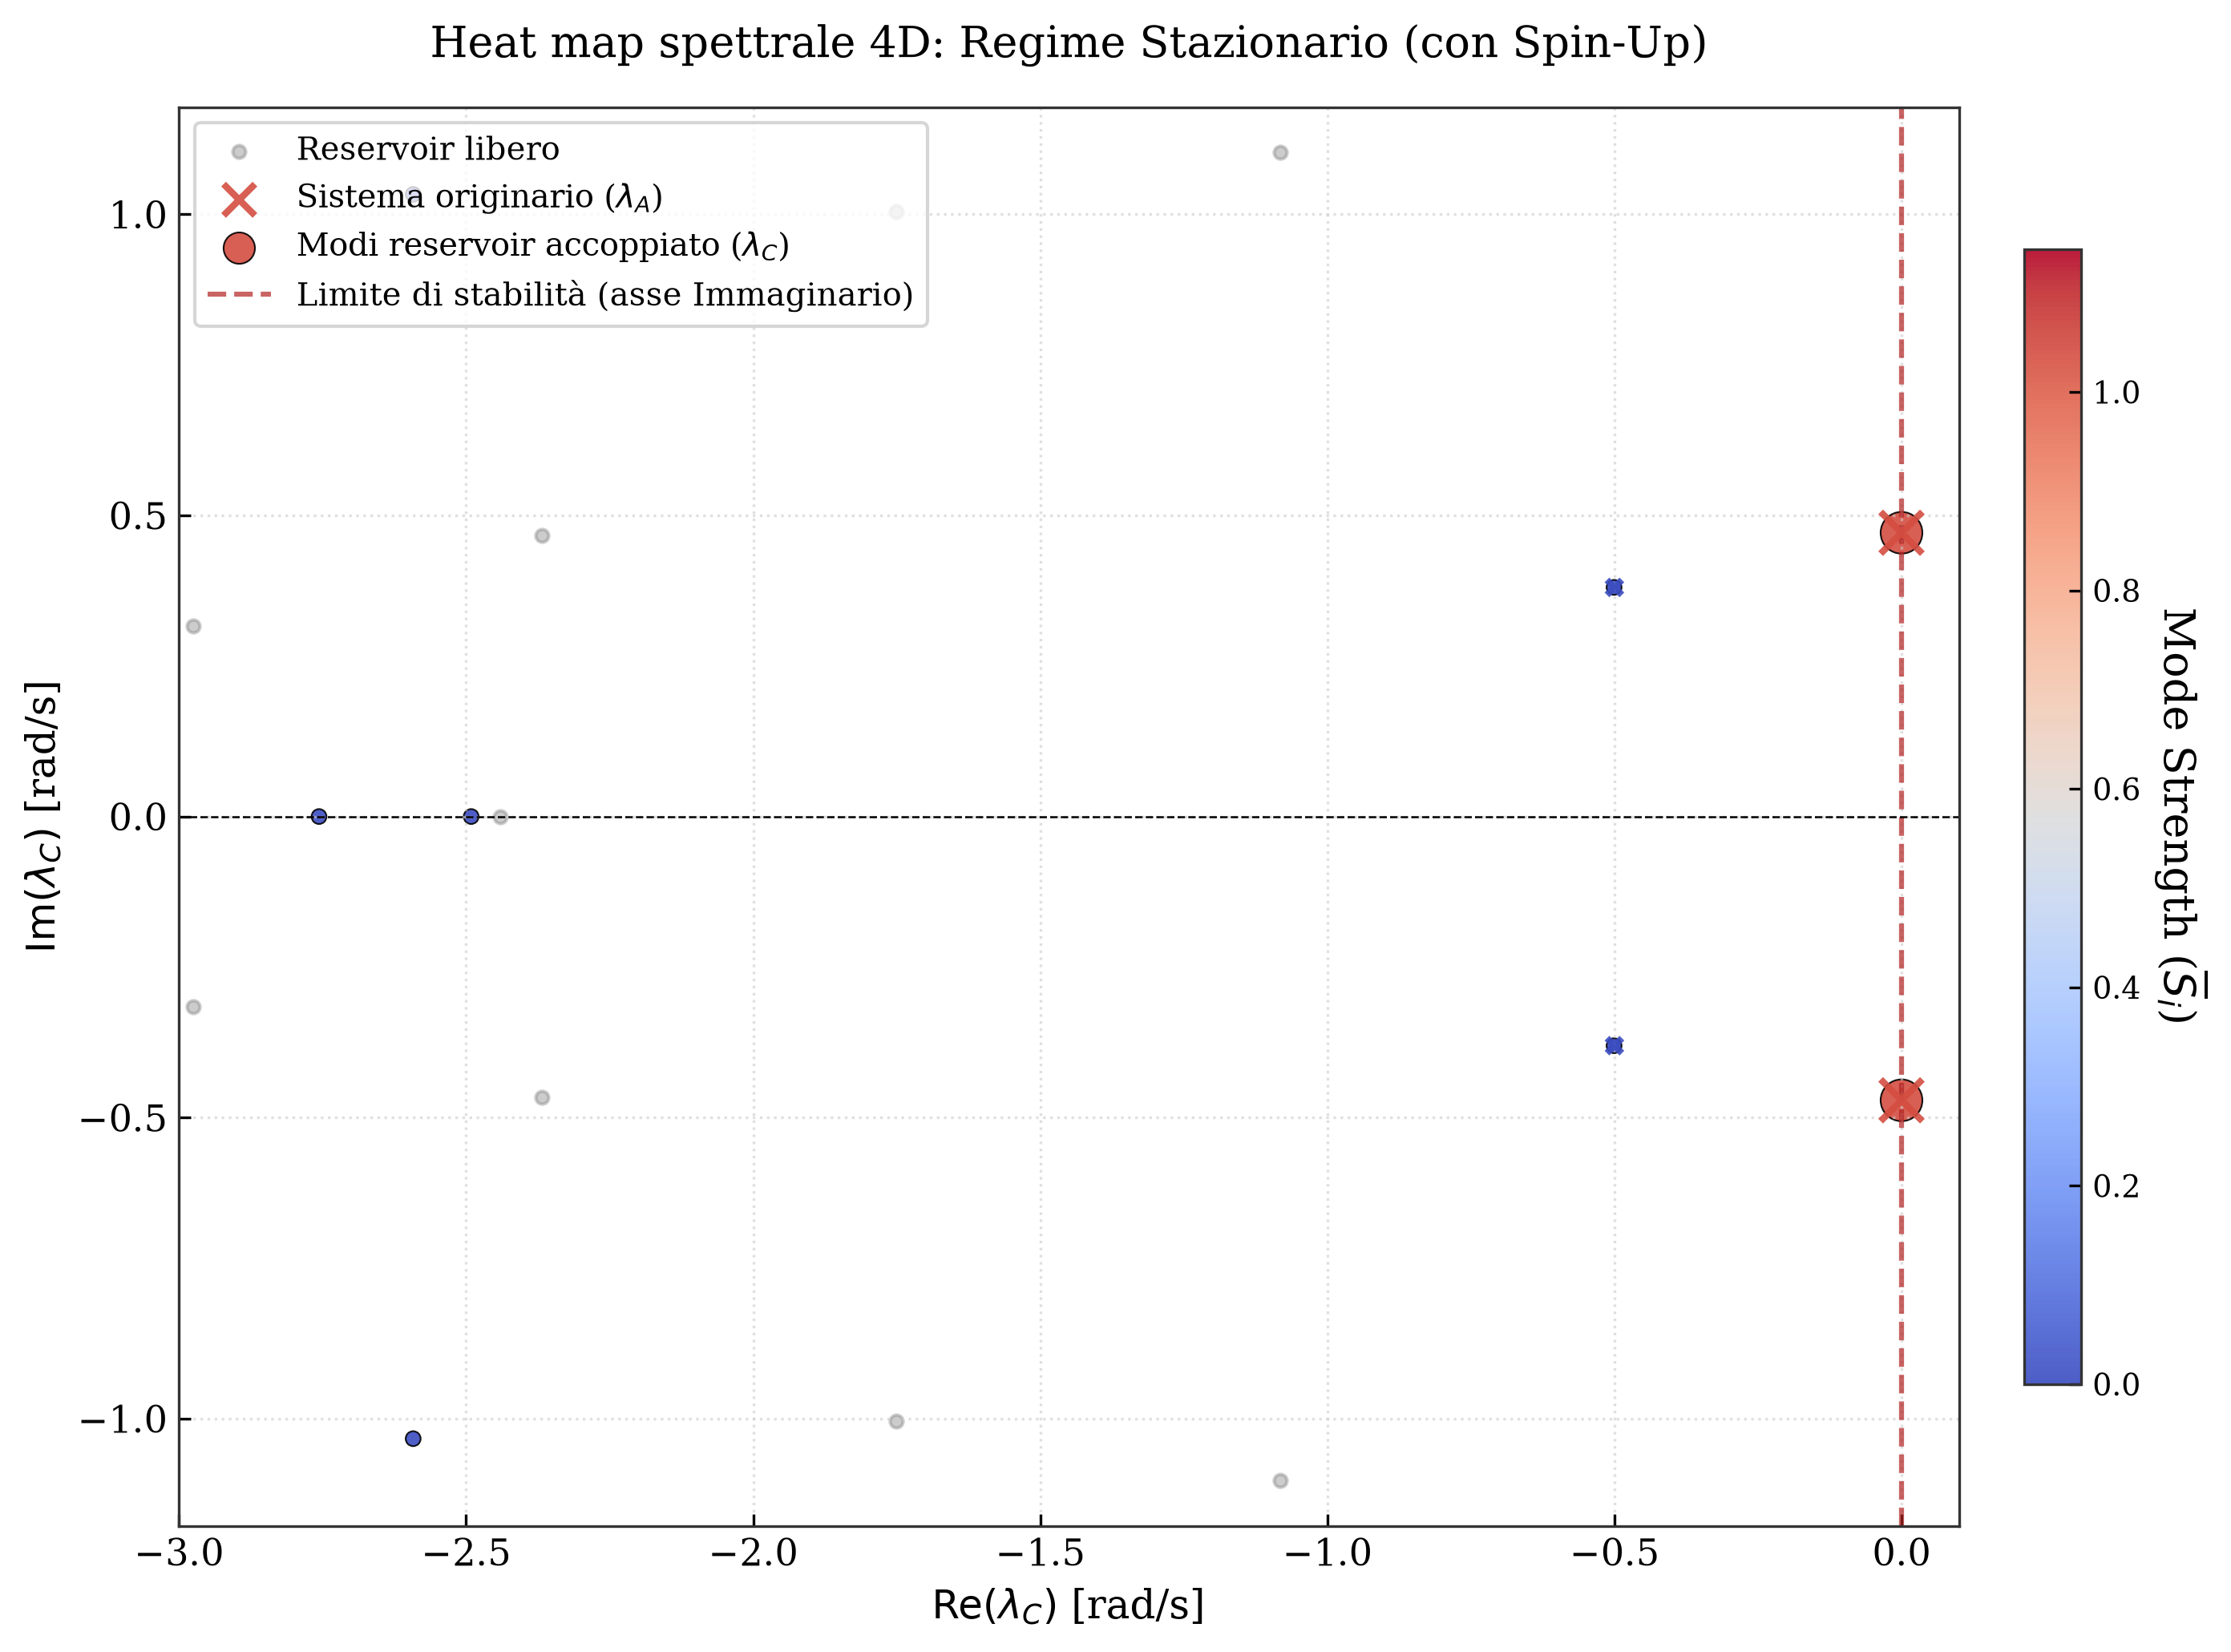

In [10]:
# =============================================================================
# 7. VISUALIZZAZIONE DELLO SPETTRO NEL DOMINIO CONTINUO (SISTEMA 4D)
# =============================================================================
plt.figure(figsize=(10, 7), dpi=300)

# Calcoliamo il fondo scala + 10%
S_max = np.max(S_A) * 1.1

# 1. Nuvola del Reservoir libero
plt.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), 
            s=15, color="gray", alpha=0.4, zorder=1, label="Reservoir libero")

# 2. Target Teorico (con mode strenght)
plt.scatter(np.real(lambda_A), np.imag(lambda_A), 
            marker='x', c=S_A, cmap='coolwarm', 
            vmin=0, vmax=S_max,
            s=20 + 150 * (S_A / S_max), 
            alpha=0.9, linewidth=2, zorder=3,
            label=r'Sistema originario ($\lambda_A$)')

# 3. Nuvola del Reservoir Accoppiato (heat map basata su mode strength)
scatter = plt.scatter(np.real(lambda_C_exact), np.imag(lambda_C_exact), 
                      c=S, cmap='coolwarm', 
                      vmin=0, vmax=S_max,
                      s=20 + 150 * np.clip(S / S_max, 0, 1.2),  # taglio di sicurezza per poli spuri
                      alpha=0.9, edgecolors='k', linewidth=0.5, 
                      label=r"Modi reservoir accoppiato ($\lambda_C$)")

# Assi di riferimento
plt.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7, label="Limite di stabilità (asse Immaginario)")
plt.axhline(0, color='black', lw=0.6, ls='--')

# Limiti assi
lim_x_min = -3.0 
plt.xlim(lim_x_min, 0.1)
plt.ylim(-omega_x * 2.5, omega_x * 2.5)

cbar = plt.colorbar(scatter, shrink=0.8, pad=0.03)
cbar.set_label(r'Mode Strength ($\overline{S}_i$)', rotation=270, labelpad=20, fontsize=13)
cbar.ax.tick_params(labelsize=9)

plt.xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
plt.ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
plt.legend(loc="upper left", fontsize=9.5, frameon=True, facecolor='white')

plt.title("Heat map spettrale 4D: Regime Stazionario (con Spin-Up)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

Come atteso, nella *heat map* spettrale i modi conservativi associati alla frequenza del Driver, sull'asse immaginario, presentano le Mode Strengths maggiori, mentre i modi dissipativi della rete, a $\mathrm{Re}(\lambda) = -0.5$, risultano fortemente attenuati.

La presenza di ulteriori autovalori nel reservoir non implica necessariamente l'esistenza di ulteriori modi fisici del sistema: tali autovalori appartengono alla dinamica interna $N$-dimensionale della rete e vengono valutati in termini di rilevanza rispetto all'osservabile attraverso la Mode Strength.

# Addestramento sul transitorio iniziale - inferenza spettrale e visualizzazione 

Per verificare se la rete sia in grado di apprendere anche i modi dissipativi, l'addestramento viene effettuato direttamente sulla fase transitoria della dinamica, omettendo intenzionalmente il *washout* iniziale.

Questa finestra temporale contiene l'espressione di tutti e 4 i gradi di libertà fisici, poiché sono simultaneamente presenti la componente persistente associata alla forzante del Driver e i contributi transitori associati alla dinamica naturale smorzata dello Slave. La finestra viene pertanto scelta in modo da mantenere nell'insieme di training questa informazione.

RMSE Training (4D Transitorio): 3.169519e-09
=== INFERENZA SPETTRALE SISTEMA 4D (Transitorio, Senza Spin-Up) ===
Autovalori Teorici (lambda_A):
  -0.000000 + 0.471239j rad/s
  -0.000000 + -0.471239j rad/s
  -0.500000 + 0.380505j rad/s
  -0.500000 + -0.380505j rad/s

Autovalori Inferiti Dominanti (lambda_C_breve):
  -0.503053 + -0.379976j rad/s
  -0.503053 + 0.379976j rad/s
  0.000011 + -0.471277j rad/s
  0.000011 + 0.471277j rad/s


/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.872313182080647e-17.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


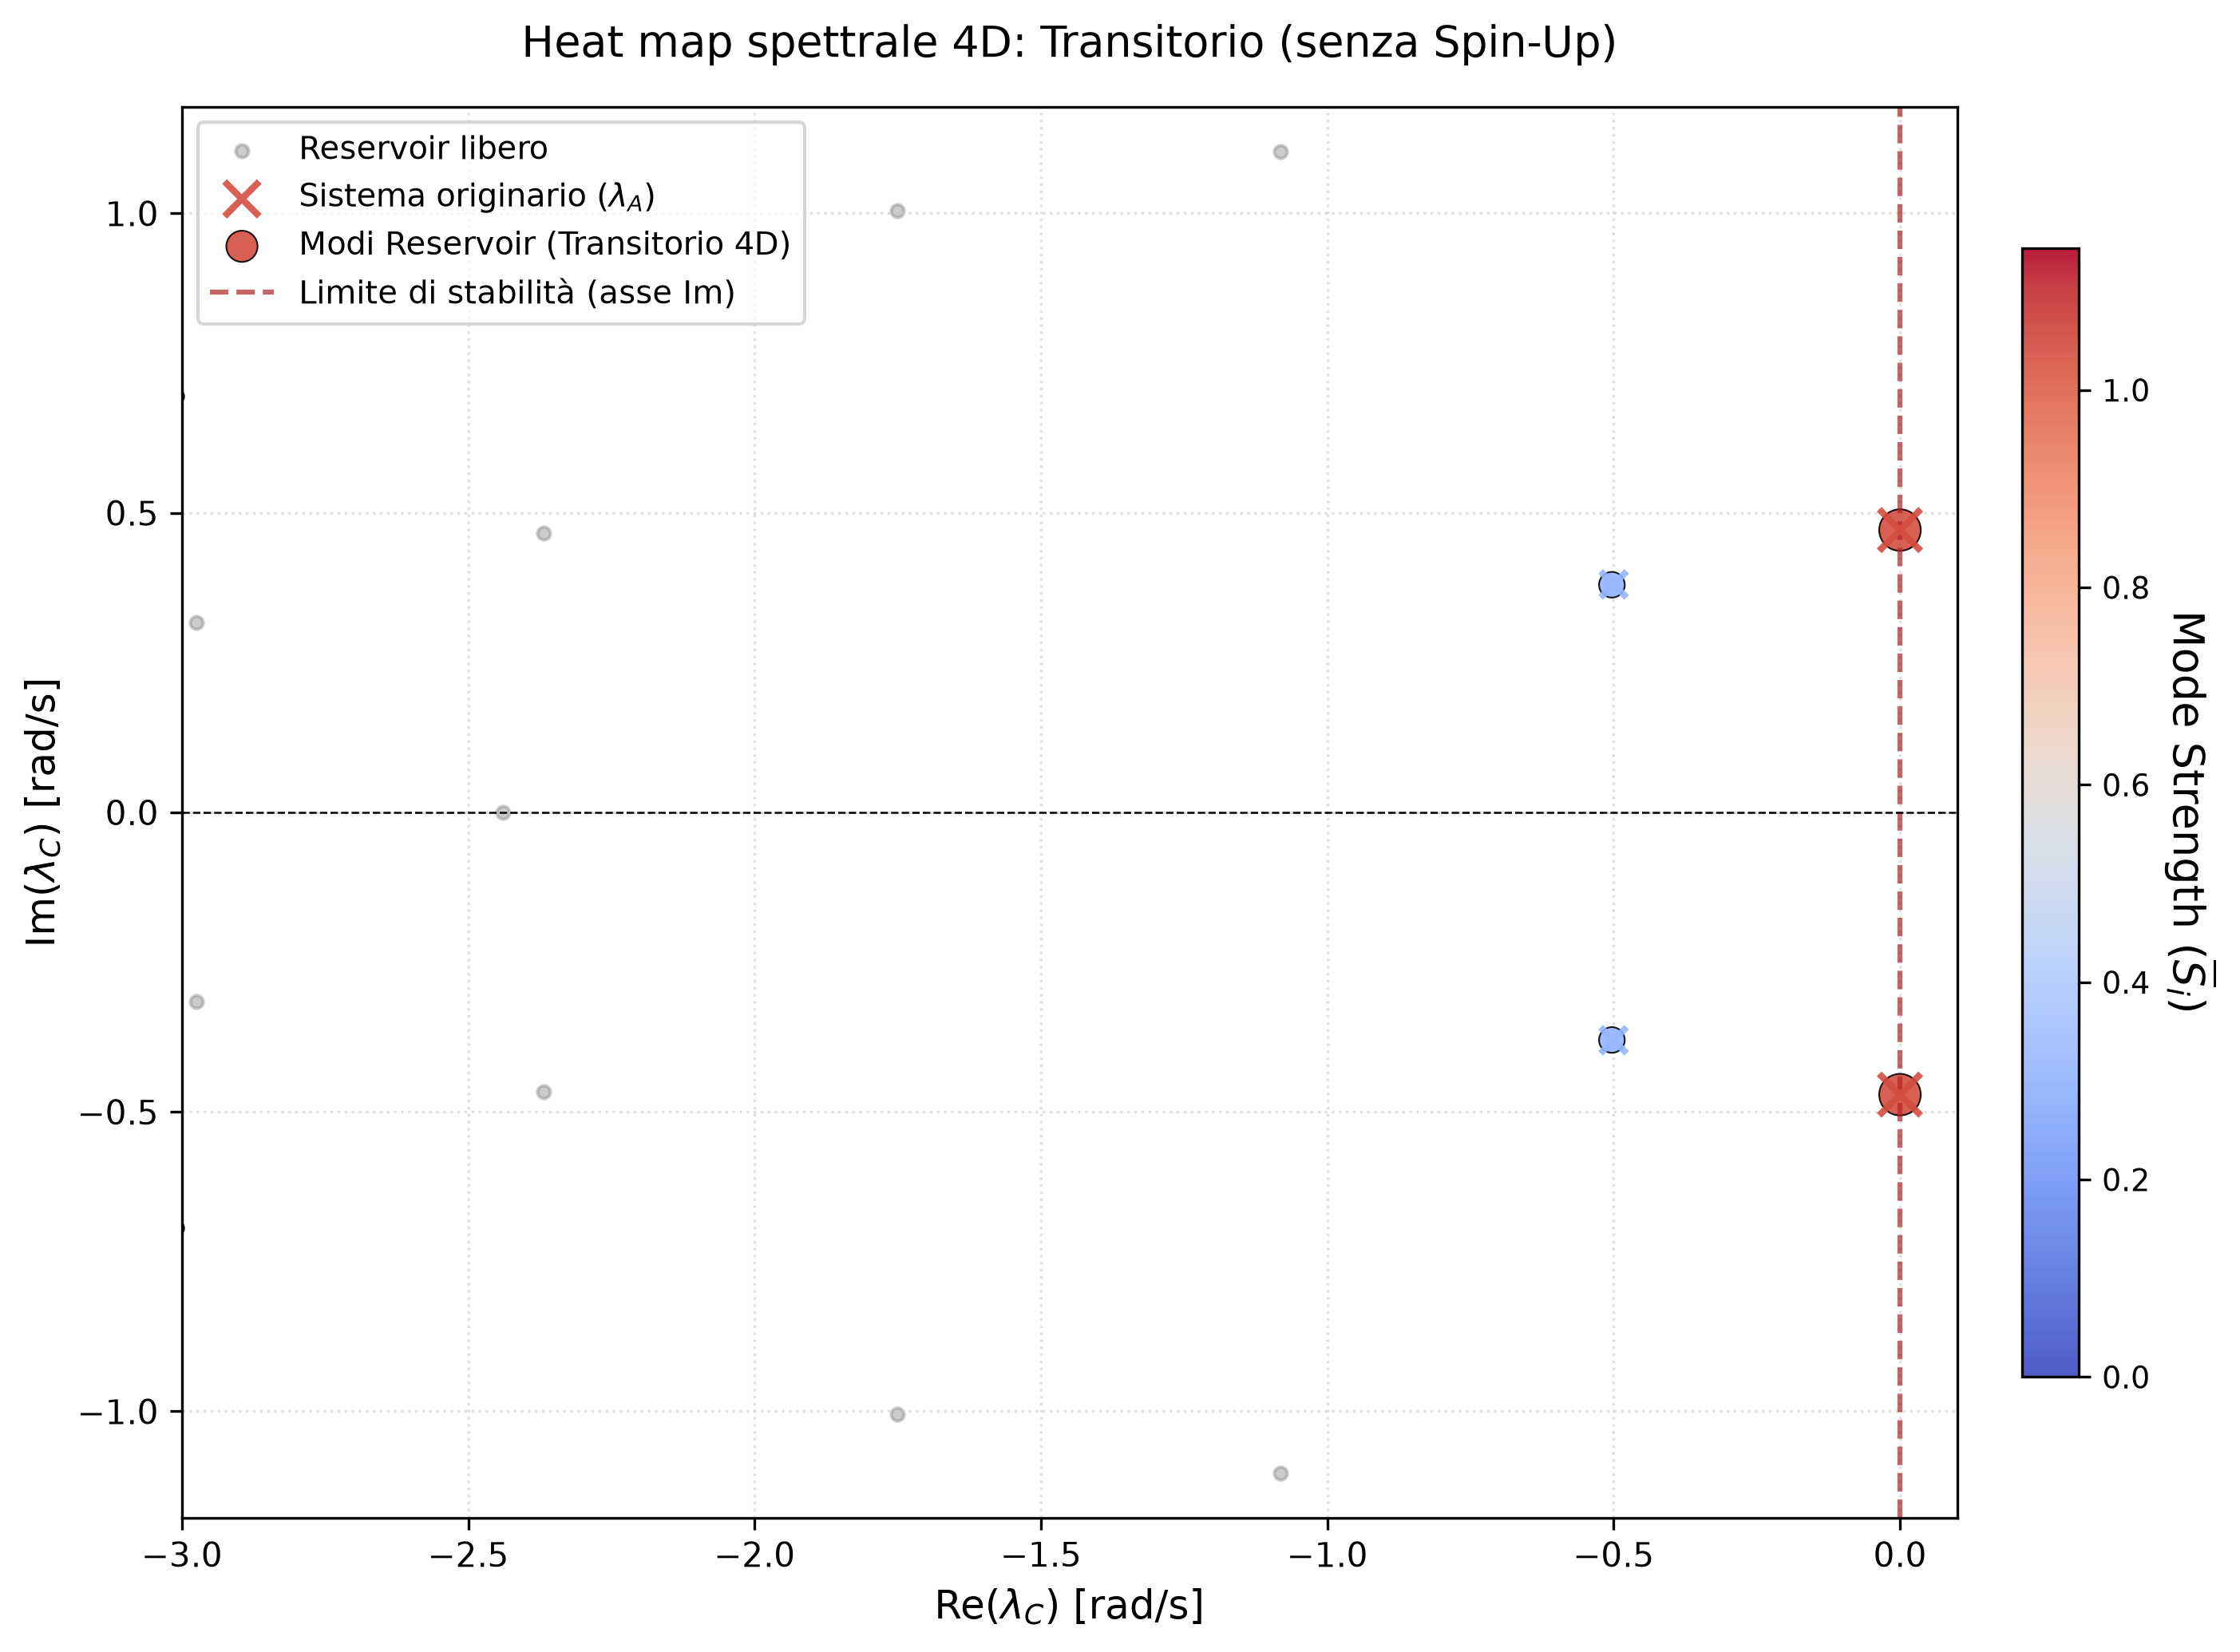

In [7]:
# =============================================================================
# 7-BIS. INFERENZA SPETTRALE 4D SUL TRANSITORIO (Senza Spin-Up)
# =============================================================================

# 1. Selezioniamo la fase iniziale (il transitorio) con tutte e 4 le dimensioni (D = 4)
n_train_breve = 100  # Primi 10 secondi fisici da t=0
u_train_breve = u_integrato[:n_train_breve]

# 2. Usiamo la matrice Win standard (D = 4), partendo da zeri (senza spin-up)
h_train_breve = open_loop(u_train_breve, np.zeros(N), W, Win, b, alpha)

# 3. Addestramento con regressione di Ridge sulle 4 dimensioni
H_train_shifted = h_train_breve[:-1]
Y_target_shifted = u_train_breve[1:]
Wout_breve = ridge_regression(H_train_shifted, Y_target_shifted, 1e-13)  # shape (4, N)

# --- CALCOLO RMSE TRAINING (4D Transitorio) ---
train_pred_breve = H_train_shifted @ Wout_breve.T
rmse_train_breve = np.sqrt(np.mean((train_pred_breve - Y_target_shifted)**2))
print(f"RMSE Training (4D Transitorio): {rmse_train_breve:.6e}")

# =============================================================================
# INFERENZA SPETTRALE DEL SISTEMA ALLENATO SUL TRANSITORIO 4D
# =============================================================================
# 1. Propagatore discreto accoppiato e mappatura esatta al continuo
W_tot_breve = W + Win @ Wout_breve
W_eff_D_breve = np.identity(N) + alpha * (W_tot_breve - np.identity(N))
lambda_D_breve, V_breve = la.eig(W_eff_D_breve)
lambda_C_breve = np.log(lambda_D_breve) / dt

# 2. Calcolo MODE STRENGTHS RESERVOIR
#h0_breve = h_train_breve[0]
#c_breve = la.solve(V_breve, h0_breve)
#mode_strengths_matrix_breve = Wout_breve @ V_breve @ np.diag(c_breve)
#S_breve = np.linalg.norm(mode_strengths_matrix_breve, axis=0)

### DECOMPOSIZIONE MODALE (Punto fisso + Media Temporale)
M_breve = W_eff_D_breve
d = alpha * b
# Punto fisso della dinamica affine closed-loop
h_star_breve = la.solve(np.eye(N) - M_breve, d)
# Stato iniziale relativo al punto fisso
#h0_breve = h_train_breve[10]
#delta_h0_breve = h0_breve - h_star_breve
# Coordinate modali
#c_breve = la.solve(V_breve, delta_h0_breve)
# Contributo dei modi all'output
#mode_strengths_matrix_breve = (Wout_breve @ V_breve @ np.diag(c_breve))
#S_breve = np.linalg.norm(mode_strengths_matrix_breve, axis=0)
S_breve = compute_time_averaged_mode_strengths(V=V_breve, 
                                               trajectory=h_train_breve, 
                                               fixed_point=h_star_breve, 
                                               observation_matrix=Wout_breve)

# 3. Calcolo MODE STRENGTHS TEORICHE sincronizzate sul transitorio
### Calcolo MEDIATO NEL TEMPO
#c_A_breve = la.solve(V_A, u_train_breve[0])
#mode_strengths_A_breve = V_A @ np.diag(c_A_breve)
#S_A_breve = np.linalg.norm(mode_strengths_A_breve, axis=0)
S_A_breve = compute_time_averaged_mode_strengths(V=V_A, 
                                                 trajectory=u_train_breve, 
                                                 fixed_point=np.zeros(4), 
                                                 observation_matrix=np.eye(4))

# =============================================================================
# STAMPA A SCHERMO 
# =============================================================================
indici_dominanti_breve = np.argsort(S_breve)[-4:]
lambda_C_dominanti_breve = lambda_C_breve[indici_dominanti_breve]

print("=== INFERENZA SPETTRALE SISTEMA 4D (Transitorio, Senza Spin-Up) ===")
print("Autovalori Teorici (lambda_A):")
for val in lambda_A:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")

print("\nAutovalori Inferiti Dominanti (lambda_C_breve):")
for val in lambda_C_dominanti_breve:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")
print("=====================================================================")

# =============================================================================
# VISUALIZZAZIONE
# =============================================================================
plt.figure(figsize=(10, 7), dpi=300)

S_max_breve = np.max(S_A_breve) * 1.1

# Nuvola del Reservoir libero
plt.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), 
            s=15, color="gray", alpha=0.4, zorder=1, label=r"Reservoir libero")

# Target Teorico (i 4 poli)
plt.scatter(np.real(lambda_A), np.imag(lambda_A), 
            marker='x', c=S_A_breve, cmap='coolwarm', 
            vmin=0, vmax=S_max_breve,
            s=20 + 150 * (S_A_breve / S_max_breve),
            alpha=0.9, linewidth=2, zorder=3,
            label=r'Sistema originario ($\lambda_A$)')

# Spettro inferito dal Reservoir (addestrato sul transitorio 4D)
scatter = plt.scatter(np.real(lambda_C_breve), np.imag(lambda_C_breve), 
                      c=S_breve, cmap='coolwarm', 
                      vmin=0, vmax=S_max_breve,
                      s=20 + 150 * np.clip(S_breve / S_max_breve, 0, 1.2),  # taglio di sicurezza per poli spuri
                      alpha=0.9, edgecolors='k', linewidth=0.5, zorder=2, 
                      label=r"Modi Reservoir (Transitorio 4D)")

plt.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7, label="Limite di stabilità (asse Im)")
plt.axhline(0, color='black', lw=0.6, ls='--')

# Limiti assi
lim_x_min = -3.0 
plt.xlim(lim_x_min, 0.1)
plt.ylim(-omega_x * 2.5, omega_x * 2.5)

cbar = plt.colorbar(scatter, shrink=0.8, pad=0.03)
cbar.set_label(r'Mode Strength ($\overline{S}_i$)', rotation=270, labelpad=20, fontsize=13)
cbar.ax.tick_params(labelsize=9)

plt.xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
plt.ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
plt.legend(loc="upper left", fontsize=9.5, frameon=True, facecolor='white')

plt.title("Heat map spettrale 4D: Transitorio (senza Spin-Up)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In questa finestra iniziale, le *Time-Averaged Mode Strengths* analitiche confermano un'alta eccitazione sia dei poli conservativi sia di quelli smorzati. Le Mode Strengths teoriche e quelle inferite vengono calcolate sulla stessa finestra temporale mediante la definizione mediata nel tempo introdotta precedentemente. Poiché i modi dissipativi decadono esponenzialmente, la loro Mode Strength *media* risulta fisiologicamente inferiore a quella dei modi persistenti, estituendo un valore cromaticamente intermedio che rappresenta l'integrale del decadimento.

## Calcolo incertezze

In [9]:
# ============================================================
# STIMA DELL'INCERTEZZA SU PIU REALIZZAZIONI DEL RESERVOIR
# ============================================================

N_REALIZZAZIONI = 50
N_MODI_DOMINANTI = 4
SEED_INIZIALE = 0

autovalori_driver = []
autovalori_slave = []
seed_scartati = []


for seed in range(SEED_INIZIALE, SEED_INIZIALE + N_REALIZZAZIONI):

    try:
        rng = np.random.default_rng(seed)

        # ----------------------------------------------------
        # 1. Inizializzazione casuale di W, Win e b
        # ----------------------------------------------------

        W_raw = rng.standard_normal((N, N))

        autovalori_W_raw = la.eigvals(W_raw)
        raggio_spettrale_raw = np.max(np.abs(autovalori_W_raw))

        W_seed = rho * W_raw / raggio_spettrale_raw

        Win_seed = (
            input_scaling
            * rng.standard_normal((N, D))
            / np.sqrt(N)
        )

        b_seed = rng.standard_normal(N) / np.sqrt(N)

        # ----------------------------------------------------
        # 2. Addestramento open-loop
        # ----------------------------------------------------

        h_train_breve = open_loop(
            u_train_breve,
            np.zeros(N),
            W_seed,
            Win_seed,
            b_seed,
            alpha
        )

        H_train_shifted = h_train_breve[:-1]
        Y_target_shifted = u_train_breve[1:]

        Wout_breve = ridge_regression(
            H_train_shifted,
            Y_target_shifted,
            alpha=1e-13
        )

        Wout_breve = np.asarray(Wout_breve).reshape(D, N)

        # ----------------------------------------------------
        # 3. Costruzione dell'operatore efficace
        # ----------------------------------------------------

        W_tot = W_seed + Win_seed @ Wout_breve

        W_eff_D = (
            np.eye(N)
            + alpha * (W_tot - np.eye(N))
        )

        lambda_D, V = la.eig(W_eff_D)

        # Conversione discreto-continuo mediante il logaritmo principale
        lambda_C = np.log(lambda_D.astype(complex)) / dt

        # ----------------------------------------------------
        # 4. Calcolo delle Mode Strengths
        # ----------------------------------------------------

        d_seed = alpha * b_seed

        h_star = la.solve(
            np.eye(N) - W_eff_D,
            d_seed
        )

        S = compute_time_averaged_mode_strengths(
            V,
            h_train_breve,
            h_star,
            Wout_breve
        )

        S = np.asarray(S).reshape(-1)

        # ----------------------------------------------------
        # 5. Selezione dei quattro modi dominanti
        # ----------------------------------------------------

        indici_dominanti = np.argsort(S)[-N_MODI_DOMINANTI:]
        lambda_dominanti = lambda_C[indici_dominanti]

        # Conserviamo un solo elemento di ogni coppia coniugata,
        # scegliendo gli autovalori con parte immaginaria positiva.
        lambda_positivi = lambda_dominanti[
            np.imag(lambda_dominanti) > 0
        ]

        if len(lambda_positivi) != 2:
            raise ValueError(
                f"Trovati {len(lambda_positivi)} modi a frequenza "
                "positiva anziche 2."
            )

        # Il driver è il modo con parte reale più vicina a zero.
        indice_driver = np.argmin(
            np.abs(np.real(lambda_positivi))
        )

        # Lo slave è l'altro modo.
        indice_slave = 1 - indice_driver

        lambda_driver = lambda_positivi[indice_driver]
        lambda_slave = lambda_positivi[indice_slave]

        autovalori_driver.append(lambda_driver)
        autovalori_slave.append(lambda_slave)

    except Exception as errore:
        seed_scartati.append((seed, str(errore)))
        print(f"Seed {seed} scartato: {errore}")


# ============================================================
# 6. CONVERSIONE IN ARRAY
# ============================================================

autovalori_driver = np.asarray(
    autovalori_driver,
    dtype=complex
)

autovalori_slave = np.asarray(
    autovalori_slave,
    dtype=complex
)

N_VALIDE = len(autovalori_driver)

if N_VALIDE < 2:
    raise RuntimeError(
        "Sono necessarie almeno due realizzazioni valide "
        "per calcolare la deviazione standard."
    )


# ============================================================
# 7. MEDIA E DEVIAZIONE STANDARD CAMPIONARIA
# ============================================================

media_driver_re = np.mean(np.real(autovalori_driver))
media_driver_im = np.mean(np.imag(autovalori_driver))

std_driver_re = np.std(
    np.real(autovalori_driver),
    ddof=1
)
std_driver_im = np.std(
    np.imag(autovalori_driver),
    ddof=1
)


media_slave_re = np.mean(np.real(autovalori_slave))
media_slave_im = np.mean(np.imag(autovalori_slave))

std_slave_re = np.std(
    np.real(autovalori_slave),
    ddof=1
)
std_slave_im = np.std(
    np.imag(autovalori_slave),
    ddof=1
)


# ============================================================
# 8. STAMPA DEI RISULTATI
# ============================================================

print("\n" + "=" * 65)
print("STATISTICA SULLE REALIZZAZIONI CASUALI DEL RESERVOIR")
print("=" * 65)

print(f"Realizzazioni richieste: {N_REALIZZAZIONI}")
print(f"Realizzazioni valide:    {N_VALIDE}")
print(f"Realizzazioni scartate:  {len(seed_scartati)}")

print("\nRisultati completi:")

print(
    "Driver: "
    f"({media_driver_re:.6f} +/- {std_driver_re:.6f}) "
    f"+ i({media_driver_im:.6f} +/- {std_driver_im:.6f})"
)

print(
    "Slave:  "
    f"({media_slave_re:.6f} +/- {std_slave_re:.6f}) "
    f"+ i({media_slave_im:.6f} +/- {std_slave_im:.6f})"
)

print("\nRisultati con due cifre significative:")

print(
    "Driver: "
    f"({media_driver_re:.2g} +/- {std_driver_re:.2g}) "
    f"+ i({media_driver_im:.2g} +/- {std_driver_im:.2g})"
)

print(
    "Slave:  "
    f"({media_slave_re:.2g} +/- {std_slave_re:.2g}) "
    f"+ i({media_slave_im:.2g} +/- {std_slave_im:.2g})"
)


# ============================================================
# 9. EVENTUALE ELENCO DEI SEED SCARTATI
# ============================================================

if seed_scartati:
    print("\nSeed scartati:")

    for seed, motivo in seed_scartati:
        print(f"  seed {seed}: {motivo}")

/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.793256316881117e-17.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.7075663693707197e-17.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.598129412571314e-17.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.


STATISTICA SULLE REALIZZAZIONI CASUALI DEL RESERVOIR
Realizzazioni richieste: 50
Realizzazioni valide:    50
Realizzazioni scartate:  0

Risultati completi:
Driver: (-0.000033 +/- 0.000207) + i(0.471263 +/- 0.000097)
Slave:  (-0.501732 +/- 0.012387) + i(0.380258 +/- 0.007771)

Risultati con due cifre significative:
Driver: (-3.3e-05 +/- 0.00021) + i(0.47 +/- 9.7e-05)
Slave:  (-0.5 +/- 0.012) + i(0.38 +/- 0.0078)


/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.527988843618783e-17.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


In [10]:
#### ALTERNATIVA ####

N_REALIZZAZIONI = 50
autovalori_driver = []
autovalori_slave = []

# Ripetiamo l'esperimento per 50 seed diversi
for seed in range(N_REALIZZAZIONI):
    np.random.seed(seed)
    
    # 1. Inizializzazione casuale (W, Win, b)
    W_raw = np.random.randn(N, N)
    max_eig = np.max(np.abs(la.eigvals(W_raw)))
    W_seed = (W_raw / max_eig) * rho
    Win_seed = input_scaling * np.random.randn(N, D) / np.sqrt(N) # Usa D_1d per il caso 1D
    b_seed = np.random.randn(N) / np.sqrt(N)
    
    # 2. Addestramento (es. sul transitorio breve)
    # Assicurati di avere u_train_breve già definito come nel tuo codice
    h_train_breve = open_loop(u_train_breve, np.zeros(N), W_seed, Win_seed, b_seed, alpha)
    H_train_shifted = h_train_breve[:-1]
    Y_target_shifted = u_train_breve[1:]
    
    Wout_breve_raw = ridge_regression(H_train_shifted, Y_target_shifted, alpha=1e-13)
    Wout_breve = Wout_breve_raw.reshape(D, N)
    
    # 3. Inferenza spettrale
    W_tot = W_seed + Win_seed @ Wout_breve
    W_eff_D = np.identity(N) + alpha * (W_tot - np.identity(N))
    lambda_D, V = la.eig(W_eff_D)
    lambda_C = np.log(lambda_D) / dt
    
    # 4. Calcolo Mode Strengths e selezione (usando la tua funzione)
    d = alpha * b_seed
    h_star = la.solve(np.eye(N) - W_eff_D, d)
    S = compute_time_averaged_mode_strengths(V, h_train_breve, h_star, Wout_breve)
    
    # Estraiamo i 4 poli dominanti e li ordiniamo per parte immaginaria per accoppiarli
    indici_dom = np.argsort(S)[-4:]
    lambda_dom = lambda_C[indici_dom]
    lambda_dom_sorted = lambda_dom[np.argsort(np.imag(lambda_dom))] 
    
    # lambda_dom_sorted avrà i 4 poli: 2 per lo Slave (im < 0 e im > 0) e 2 per il Driver
    # Salviamo solo quelli a frequenza positiva per fare la statistica
    autovalori_slave.append(lambda_dom_sorted[1]) # Esempio: polo con Re negativa e Im positiva
    autovalori_driver.append(lambda_dom_sorted[3]) # Esempio: polo con Re nulla e Im positiva

# --- Calcolo Media e Deviazione Standard (Errore Sperimentale) ---
media_driver = np.mean(autovalori_driver)
err_driver_re = np.std(np.real(autovalori_driver))
err_driver_im = np.std(np.imag(autovalori_driver))

media_slave = np.mean(autovalori_slave)
err_slave_re = np.std(np.real(autovalori_slave))
err_slave_im = np.std(np.imag(autovalori_slave))

print("=== STATISTICA SU 50 REALIZZAZIONI ===")
print(f"Driver Inferito: ({np.real(media_driver):.4f} +/- {err_driver_re:.4f}) + i({np.imag(media_driver):.4f} +/- {err_driver_im:.4f})")
print(f"Slave Inferito : ({np.real(media_slave):.4f} +/- {err_slave_re:.4f}) + i({np.imag(media_slave):.4f} +/- {err_slave_im:.4f})")

/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.622774953518408e-17.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1121314883742625e-17.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/ileni/Desk

=== STATISTICA SU 50 REALIZZAZIONI ===
Driver Inferito: (0.0000 +/- 0.0001) + i(0.4712 +/- 0.0002)
Slave Inferito : (-0.4997 +/- 0.0107) + i(-0.3802 +/- 0.0052)


/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


# Ablazione dell'input e analisi PCA

## Ricostruzione della dinamica da una singola osservabile

Nei contesti sperimentali reali, l'accesso simultaneo a tutte le coordinate dello spazio delle fasi (posizioni e velocità) è raramente possibile. Di norma, il sistema viene campionato attraverso l'osservazione di una singola variabile scalare nel tempo.

È quindi di interesse verificare se una rappresentazione ricorrente sia in grado di recuperare l'informazione dinamica latente a partire da una singola serie temporale.

Nel presente esperimento di ablazione dell'input, il reservoir riceve esclusivamente la posizione dello Slave $y(t)$ ($D=1$), mentre la forzante $x(t)$ e le velocità non vengono fornite. La scelta di $y(t)$ è strettamente motivata dalla struttura fisica del sistema: la sua equazione differenziale contiene sia la dinamica propria dello Slave, sia il termine di accoppiamento guidato dal Driver. Pertanto, per i parametri e le condizioni iniziali qui considerate, l'osservabile è modulata sia dalla propria frequenza naturale smorzata ($\omega_y, \gamma$) sia da quella della forzante ($\omega_x$).

L'obiettivo è verificare empiricamente che, nonostante la drastica riduzione dimensionale, la matrice effettiva del Reservoir conserva intatta la traccia latente dell'intero generatore dinamico 4D originale, permettendo un'estrazione spettrale completa.

Grazie alla propria memoria temporale, la lRNN costruisce uno stato interno $\mathbf{h}_t$ che dipende dalla storia passata dell'osservabile. In condizioni di stabilità dell'operatore del reservoir libero $\mathbf{W}_{\mathrm{free}}^D = \mathbf{I} + \alpha(\mathbf{W} - \mathbf{I})$, tale dipendenza assume la forma di una combinazione pesata di input presenti e ritardati, ovvero agendo come una linea di ritardo temporale, rendendo possibile una rappresentazione ad alta dimensionalità della storia dell'osservabile scalare.

Questo esperimento è concettualmente legato all'idea di ricostruzione dello spazio degli stati mediante osservazioni ritardate (Teorema di Embedding di Takens). Tuttavia, il presente test non costituisce una dimostrazione del Teorema, né implica automaticamente che la rappresentazione interna del reservoir sia un embedding diffeomorfo dello stato fisico, specialmente considerando che l'informazione a 4 dimensioni risiede unicamente nel transitorio dissipativo e non nell'attrattore asintotico. 
L'obiettivo è invece fornire un'evidenza numerica: verificare empiricamente se la memoria del reservoir contenga informazione sufficiente a recuperare, attraverso l'inferenza spettrale, i quattro autovalori del generatore dinamico originale $\mathbf{A}$.

## Inferenza 1D a Regime
Iniziamo l'indagine valutando la rete a regime (con *spin-up*). Analiticamente, esaurito il transitorio dello Slave, il segnale di training è dominato dalla componente periodica alla frequenza del Driver. L'informazione intrinseca del segnale è pertanto collassata su sole due dimensioni.
Ci aspettiamo pertanto che i modi fisici associati alla coppia $\lambda=\pm i\omega_x$ presentino le Mode Strengths maggiori, mentre gli altri autovalori del reservoir non siano necessariamente associati a dinamiche fisiche rilevanti.

=== INFERENZA SPETTRALE 1D (Con Spin-Up) ===
Autovalori Teorici (lambda_A):
  -0.000000 + 0.471239j rad/s
  -0.000000 + -0.471239j rad/s
  -0.500000 + 0.380505j rad/s
  -0.500000 + -0.380505j rad/s

Autovalori Inferiti Dominanti (lambda_C_exact_1d):
  -0.499742 + -0.380794j rad/s
  -0.499742 + 0.380794j rad/s
  -0.000000 + -0.471239j rad/s
  -0.000000 + 0.471239j rad/s


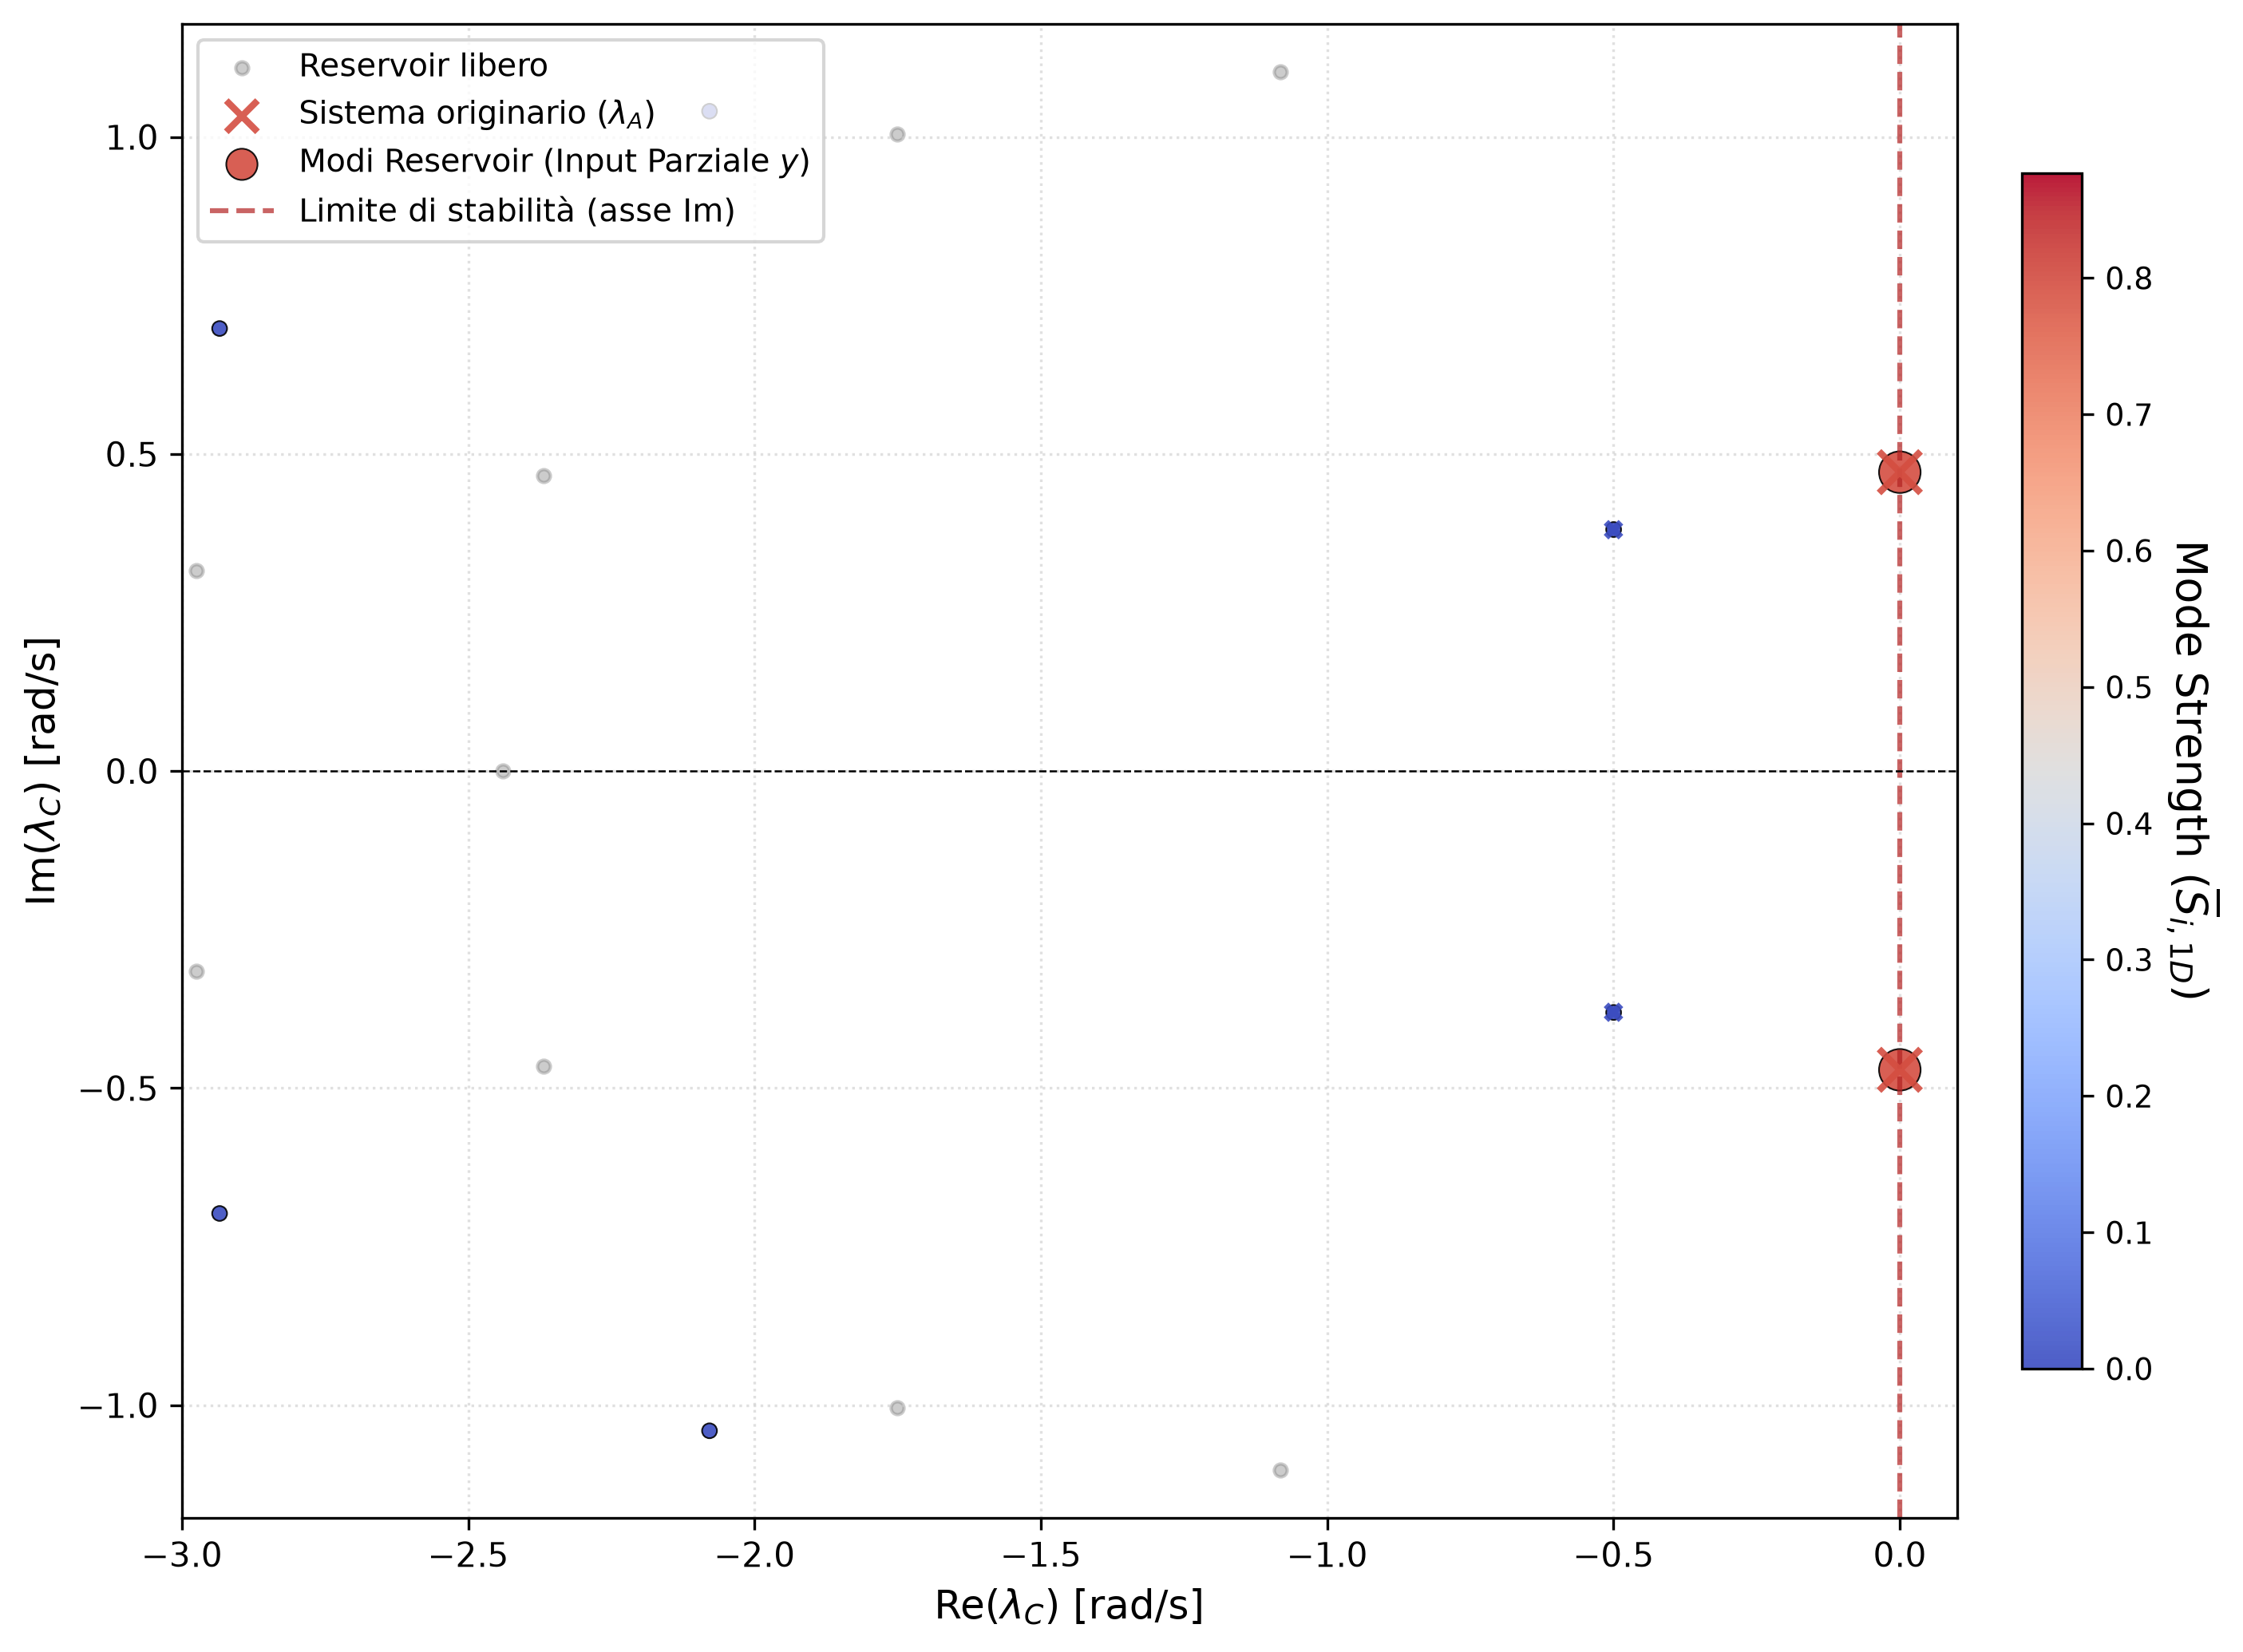

In [20]:
# =============================================================================
# 8. ABLAZIONE DELL'INPUT E TAKENS (1D -> 4D) A REGIME (con Spin-up)
# =============================================================================

# 1. Estraiamo una singola variabile. Scegliamo lo Slave y(t) (indice 1)
# perché è l'unica osservabile che "sente" l'intero sistema
u_spin_1d = u_spin[:, 1].reshape(-1, 1)
u_train_1d = u_train[:, 1].reshape(-1, 1)

# 2. Reinizializziamo Win per accettare D = 1
D_1d = 1
rng = np.random.default_rng(123) # fissato il seed per stabilità nella comparazione
Win_1d = input_scaling * rng.standard_normal((N, 1)) / np.sqrt(N)

# 3. Evoluzione del sistema in ascolto (solo variabile y)
h_spin_1d = open_loop(u_spin_1d, np.zeros(N), W, Win_1d, b, alpha)
h_train_1d = open_loop(u_train_1d, h_spin_1d[-1], W, Win_1d, b, alpha)

# 4. Addestramento
H_train_shifted_1d = h_train_1d[:-1]
Y_target_shifted_1d = u_train_1d[1:]
Wout_1d_raw = ridge_regression(H_train_shifted_1d, Y_target_shifted_1d, 1e-14)
Wout_1d = Wout_1d_raw.reshape(1, N) # shape (1, N)

# =============================================================================
# 9. INFERENZA SPETTRALE
# =============================================================================
# 1. Propagatore discreto e mappatura continua
W_tot_1d = W + Win_1d @ Wout_1d
W_eff_D_1d = np.identity(N) + alpha * (W_tot_1d - np.identity(N))

lambda_D_1d, V_1d = la.eig(W_eff_D_1d)
lambda_C_exact_1d = np.log(lambda_D_1d) / dt

# 2. Calcolo MODE STRENGTHS  sulla variabile osservata
#h0_1d = h_train_1d[-1]
#c_1d = la.solve(V_1d, h0_1d)
#mode_strengths_matrix_1d = Wout_1d @ V_1d @ np.diag(c_1d)
#S_1d = np.abs(mode_strengths_matrix_1d).flatten()

### DECOMPOSIZIONE MODALE 1D (Punto fisso + Media Temporale)
M_1d = W_eff_D_1d
d = alpha * b
# Punto fisso della dinamica affine del reservoir 1D
h_star_1d = la.solve(np.eye(N) - M_1d, d)
# Stato relativo al punto fisso
#h0_1d = h_train_1d[-1]
#delta_h0_1d = h0_1d - h_star_1d
# Coordinate modali
#c_1d = la.solve(V_1d, delta_h0_1d)
# Contributo di ogni modo all'unico output y(t)
#mode_strengths_matrix_1d = (Wout_1d @ V_1d @ np.diag(c_1d))
# Essendo un output 1D, prendiamo direttamente il modulo
#S_1d = np.abs(mode_strengths_matrix_1d[0, :])

#mode_strengths_A_1d = mode_strengths_A[1, :] 
#S_A_1d = np.abs(mode_strengths_A_1d)
#S_A_1d_norm = S_A_1d / np.max(S_A_1d)
#S_1d_norm = S_1d / np.max(S_1d)
#S_global_max = max(np.max(S_A_1d), np.max(S_1d))
#S_A_1d_norm = (S_A_1d / S_global_max)
#S_1d_norm = (S_1d / S_global_max)

# Matrice di osservazione teorica 1D (estrae solo y, che è all'indice 1)
obs_matrix_1D_teorica = np.array([[0, 1, 0, 0]])
# NUOVO CALCOLO MEDIATO NEL TEMPO (Teoria 1D)
S_A_1d = compute_time_averaged_mode_strengths(V=V_A, 
                                              trajectory=u_train, 
                                              fixed_point=np.zeros(4), 
                                              observation_matrix=obs_matrix_1D_teorica)
# NUOVO CALCOLO MEDIATO NEL TEMPO (Reservoir 1D)
S_1d = compute_time_averaged_mode_strengths(V=V_1d, 
                                            trajectory=h_train_1d, 
                                            fixed_point=h_star_1d, 
                                            observation_matrix=Wout_1d)                                            

# =============================================================================
# STAMPA A SCHERMO 
# =============================================================================
indici_dominanti_1d = np.argsort(S_1d)[-4:]
lambda_C_dominanti_1d = lambda_C_exact_1d[indici_dominanti_1d]

print("=== INFERENZA SPETTRALE 1D (Con Spin-Up) ===")
print("Autovalori Teorici (lambda_A):")
for val in lambda_A:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")

print("\nAutovalori Inferiti Dominanti (lambda_C_exact_1d):")
for val in lambda_C_dominanti_1d:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")
print("=============================================")

# =============================================================================
# VISUALIZZAZIONE SPETTRO CONTINUO (1D -> 4D)
# =============================================================================

plt.figure(figsize=(10, 7), dpi=300)

S_max1d = np.max(S_A_1d) * 1.1

# Reservoir libero
plt.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), 
            s=15, color="gray", alpha=0.4, zorder=1, label=r"Reservoir libero")

# Target Teorico (I 4 poli del sistema 4D originale)
plt.scatter(np.real(lambda_A), np.imag(lambda_A), 
            marker='x', c=S_A_1d, cmap='coolwarm', 
            vmin=0, vmax=S_max1d,
            s=20 + 150 * (S_A_1d / S_max1d), 
            alpha=0.9, linewidth=2, zorder=3,
            label=r'Sistema originario ($\lambda_A$)')

# Spettro inferito dal Reservoir
scatter = plt.scatter(np.real(lambda_C_exact_1d), np.imag(lambda_C_exact_1d), 
                      c=S_1d, cmap='coolwarm', 
                      vmin=0, vmax=S_max1d,
                      s=20 + 150 * np.clip(S_1d / S_max1d, 0, 1.2), 
                      alpha=0.9, edgecolors='k', linewidth=0.5, zorder=2, 
                      label=r"Modi Reservoir (Input Parziale $y$)")

plt.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7, label="Limite di stabilità (asse Im)")
plt.axhline(0, color='black', lw=0.6, ls='--')

# Limiti assi
lim_x_min = -3.0 
plt.xlim(lim_x_min, 0.1)
plt.ylim(-omega_x * 2.5, omega_x * 2.5)

cbar = plt.colorbar(scatter, shrink=0.8, pad=0.03)
cbar.set_label(r'Mode Strength ($\overline{S}_{i, 1D}$)', rotation=270, labelpad=20, fontsize=13)
cbar.ax.tick_params(labelsize=9)

plt.xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
plt.ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
plt.legend(loc="upper left", fontsize=9.5, frameon=True, facecolor='white')

#plt.title("Inferenza Spettrale 4D da singola osservabile: regime stazionario (con Spin-Up)", fontsize=13, pad=15)
plt.tight_layout()
#plt.savefig('spettroOSA_1Dregime.pdf', dpi=300, bbox_inches='tight')
plt.show()

La *heat map* consente di distinguere i modi dominanti del sistema target dalla restante struttura spettrale della rete. L'eventuale presenza di autovalori aggiuntivi nel reservoir non costituisce di per sé un errore: essi appartengono alla dinamica interna $N$-dimensionale e devono essere valutati sulla base della loro rilevanza rispetto all'osservabile, risultando in questo caso trascurabili. A regime, quindi, come atteso, una singola osservabile appartenente a un attrattore collassato in 2D non risulta contenere informazione dinamica sufficiente per l'estrazione spettrale di un sistema 4D.

## Inferenza 1D sul Transitorio
Per verificare se una singola osservabile sia sufficiente a recuperare anche la componente dissipativa, spostiamo l'inferenza sulla finestra temporale iniziale (senza *spin-up*), in cui il segnale $y(t)$ è una sinusoide modulata generata dalla sovrapposizione dell'onda forzante e della dissipazione transiente. 
Fornendo in input alla rete esclusivamente 15 secondi di questa traiettoria, verifichiamo la capacità della Ridge Regression di inferire lo spettro del generatore continuo equivalente alla dinamica discreta appresa.

RMSE Training (1D Transitorio): 4.971698e-08
=== INFERENZA SPETTRALE 1D (Transitorio, Senza Spin-Up) ===
Autovalori Teorici (lambda_A):
  -0.000000 + 0.471239j rad/s
  -0.000000 + -0.471239j rad/s
  -0.500000 + 0.380505j rad/s
  -0.500000 + -0.380505j rad/s

Autovalori Inferiti Dominanti (lambda_C_breve_1d):
  -0.502120 + 0.381180j rad/s
  -0.502120 + -0.381180j rad/s
  0.000010 + 0.471246j rad/s
  0.000010 + -0.471246j rad/s


/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


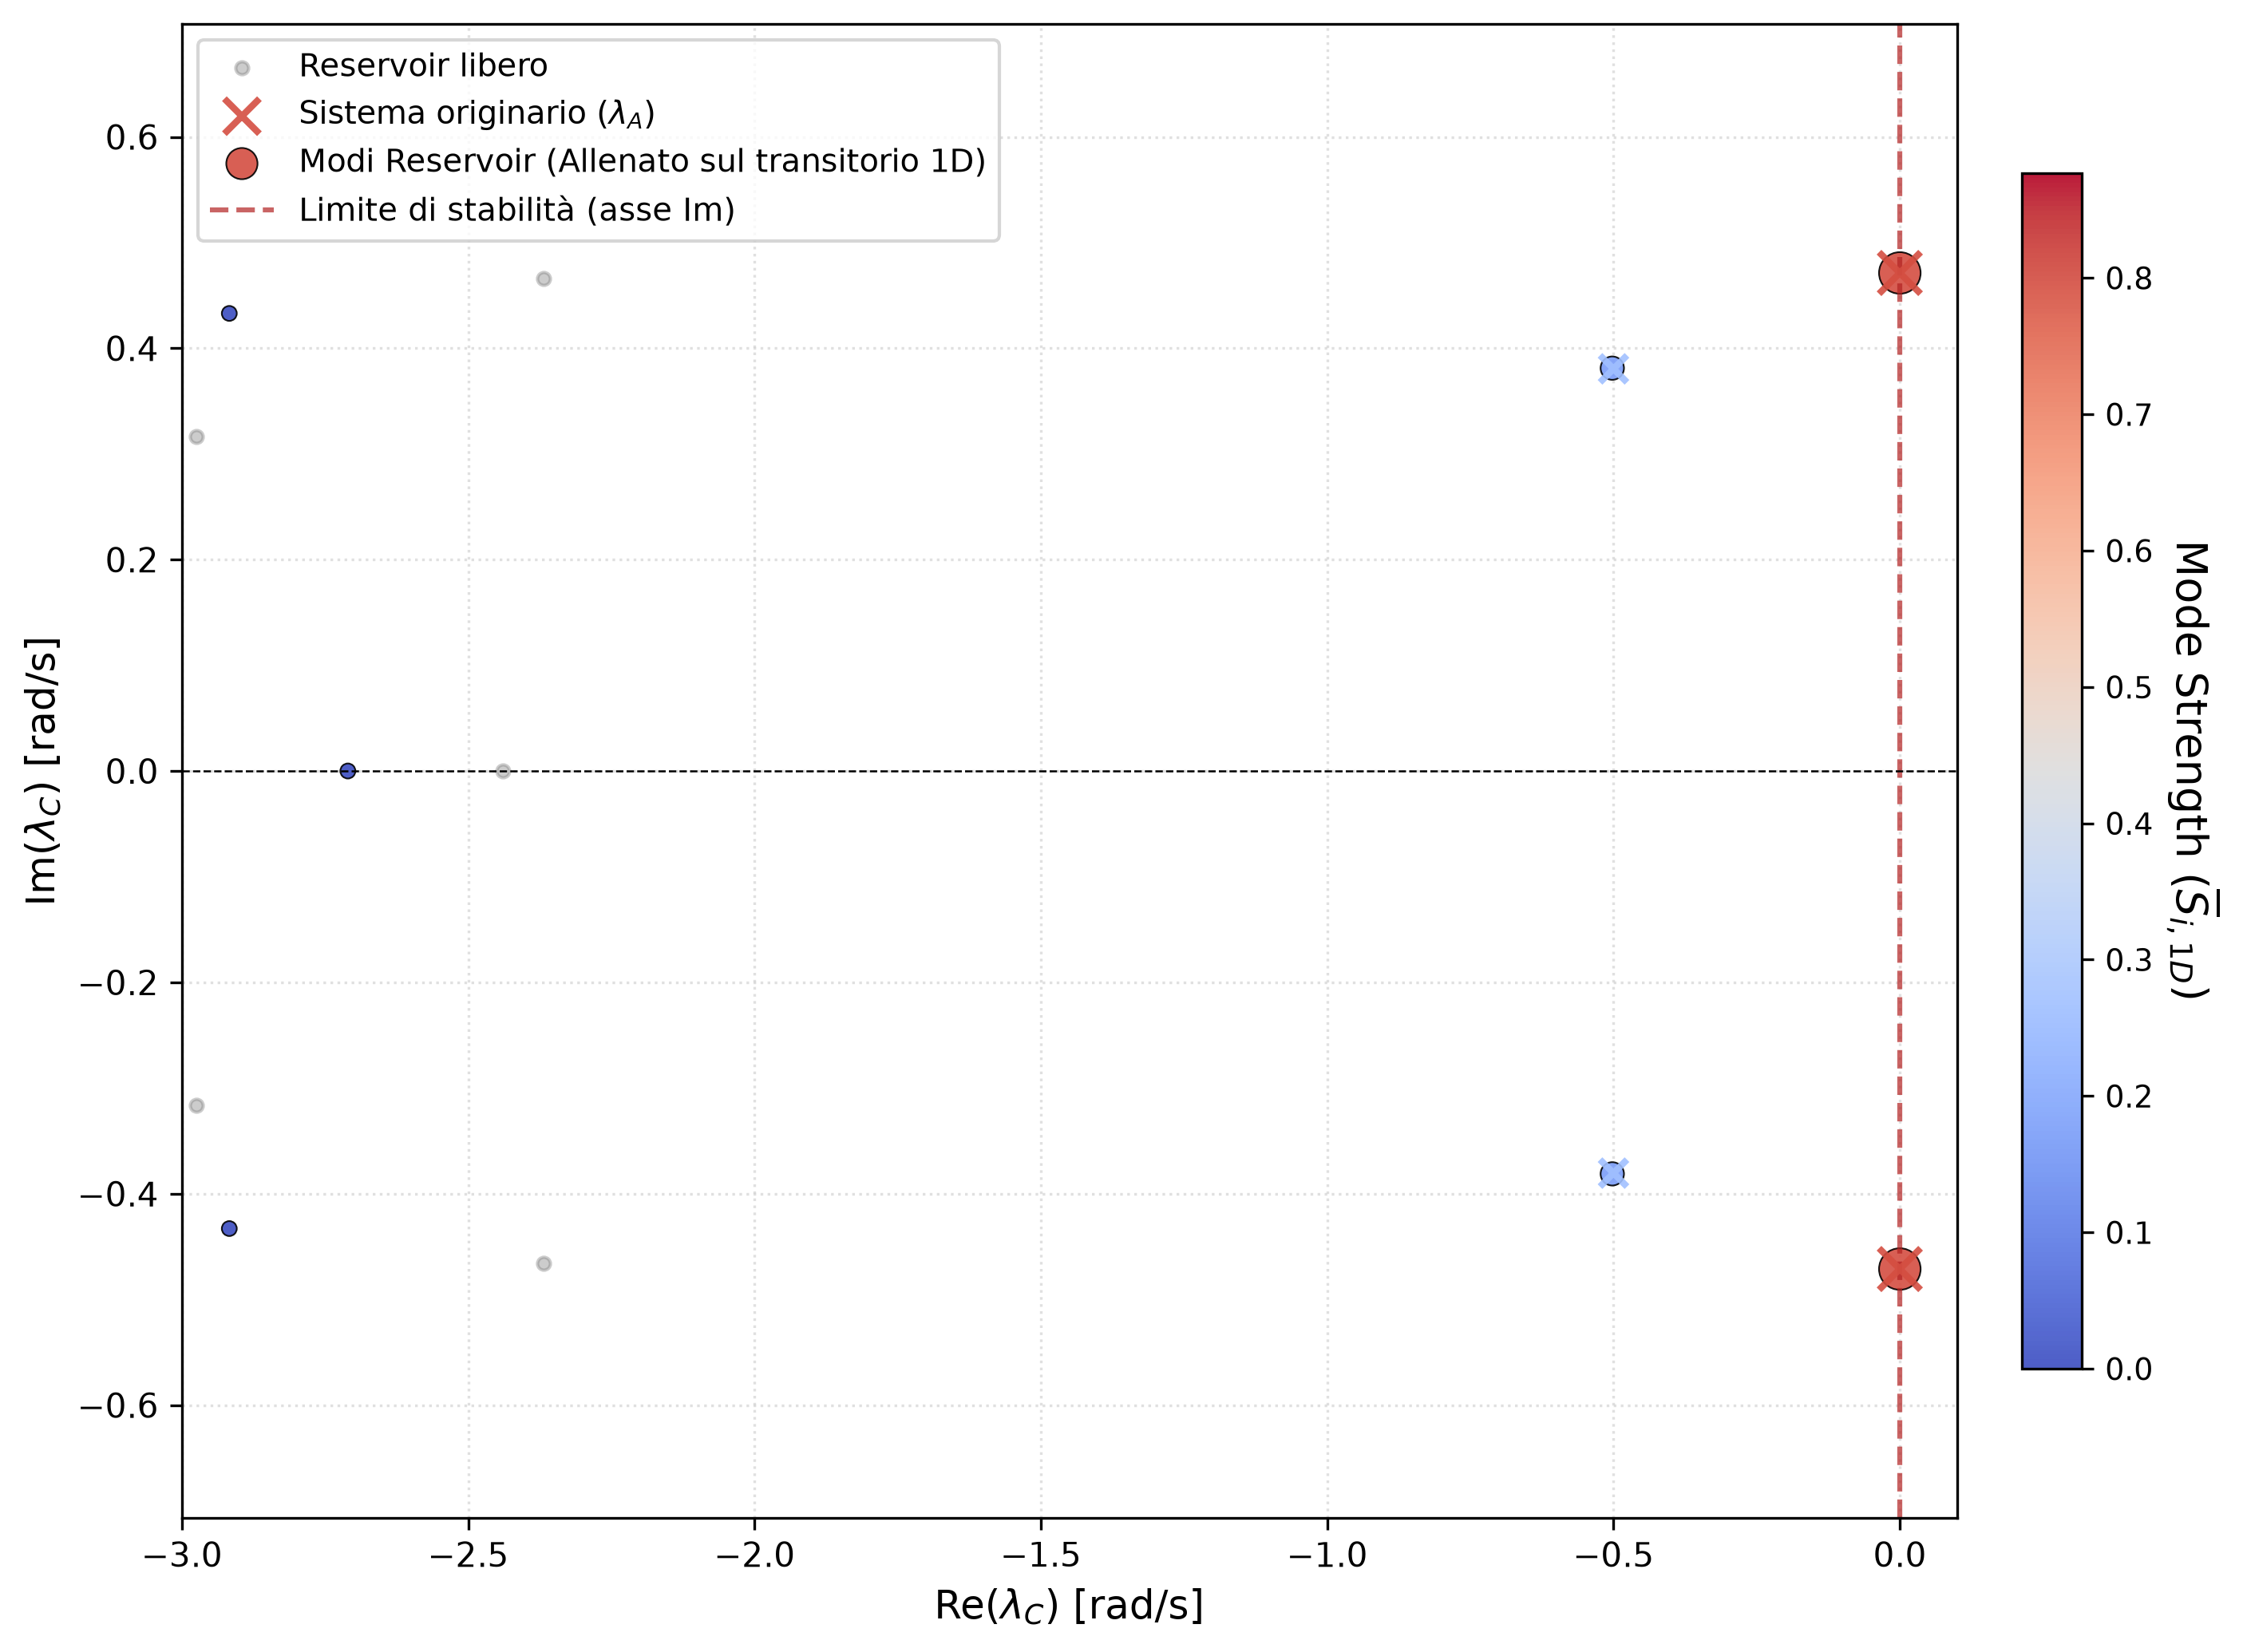

In [21]:
# =============================================================================
# 8-BIS. ABLAZIONE 1D SUL TRANSITORIO (senza Spin-Up)
# =============================================================================

# 1. Selezioniamo SOLO la fase iniziale (il transitorio) della variabile y
n_train_breve = 150  # Addestramento di soli 15 secondi fisici
u_train_breve_1d = u_integrato[:n_train_breve, 1].reshape(-1, 1)

np.random.seed(42) # Stesso seed per confronto equo
Win_1d = input_scaling * np.random.randn(N, D_1d) / np.sqrt(N)

# 2. Addestramento (partendo da zeri, saltando lo spin-up)
h_train_breve_1d = open_loop(u_train_breve_1d, np.zeros(N), W, Win_1d, b, alpha)
H_train_shifted_breve_1d = h_train_breve_1d[:-1]
Y_target_shifted_breve_1d = u_train_breve_1d[1:]
Wout_breve_raw_1d = ridge_regression(H_train_shifted_breve_1d, Y_target_shifted_breve_1d, 1e-14)
Wout_breve_1d = Wout_breve_raw_1d.reshape(1, N)

# --- CALCOLO RMSE TRAINING (1D Transitorio) ---
train_pred_breve_1d = H_train_shifted_breve_1d @ Wout_breve_1d.T
rmse_train_breve_1d = np.sqrt(np.mean((train_pred_breve_1d - Y_target_shifted_breve_1d)**2))
print(f"RMSE Training (1D Transitorio): {rmse_train_breve_1d:.6e}")

# =============================================================================
# INFERENZA SPETTRALE DEL SISTEMA ALLENATO SUL TRANSITORIO
# =============================================================================
# 1. Propagatore discreto e mappatura continua
W_tot_breve_1d = W + Win_1d @ Wout_breve_1d
W_eff_D_breve_1d = np.identity(N) + alpha * (W_tot_breve_1d - np.identity(N))
lambda_D_breve_1d, V_breve_1d = la.eig(W_eff_D_breve_1d)
lambda_C_breve_1d = np.log(lambda_D_breve_1d) / dt

# 2. Calcolo MODE STRENGTHS
#h0_breve_1d = h_train_breve_1d[-1]
#c_breve_1d = la.solve(V_breve_1d, h0_breve_1d)
#mode_strengths_matrix_breve_1d = Wout_breve_1d @ V_breve_1d @ np.diag(c_breve_1d)
#S_breve_1d = np.abs(mode_strengths_matrix_breve_1d).flatten()
### DECOMPOSIZIONE MODALE 1D SUL TRANSITORIO (Punto fisso + Media Temporale)
M_breve_1d = W_eff_D_breve_1d
d = alpha * b
# Punto fisso della dinamica affine
h_star_breve_1d = la.solve(np.eye(N) - M_breve_1d, d)

# Stato iniziale relativo al punto fisso
#h0_breve_1d = h_train_breve_1d[0]
#delta_h0_breve_1d = (h0_breve_1d - h_star_breve_1d)
# Coordinate modali
#c_breve_1d = la.solve(V_breve_1d, delta_h0_breve_1d)
# Strength del singolo output y
#mode_strengths_matrix_breve_1d = (Wout_breve_1d @ V_breve_1d @ np.diag(c_breve_1d))
#S_breve_1d = np.abs(mode_strengths_matrix_breve_1d[0, :])

#mode_strengths_A_breve_1d = mode_strengths_A_breve[1, :]
#S_A_breve_1d = np.abs(mode_strengths_A_breve_1d)

#S_A_breve_1d_norm = S_A_breve_1d / np.max(S_A_breve_1d)
#S_breve_1d_norm = S_breve_1d / np.max(S_breve_1d)
#S_global_max = max(np.max(S_A_breve_1d), np.max(S_breve_1d))
#S_A_breve_1d_norm = (S_A_breve_1d / S_global_max)
#S_breve_1d_norm = (S_breve_1d / S_global_max)

# Matrice di osservazione teorica 1D (estrae solo y, indice 1)
obs_matrix_1D_teorica = np.array([[0, 1, 0, 0]])

# NUOVO CALCOLO MEDIATO NEL TEMPO (Teoria 1D Transitorio)
S_A_breve_1d = compute_time_averaged_mode_strengths(V=V_A, 
                                                    trajectory=u_train_breve, 
                                                    fixed_point=np.zeros(4), 
                                                    observation_matrix=obs_matrix_1D_teorica)

# NUOVO CALCOLO MEDIATO NEL TEMPO (Reservoir 1D Transitorio)
S_breve_1d = compute_time_averaged_mode_strengths(V=V_breve_1d, 
                                                  trajectory=h_train_breve_1d, 
                                                  fixed_point=h_star_breve_1d, 
                                                  observation_matrix=Wout_breve_1d)
# =============================================================================
# STAMPA A SCHERMO 
# =============================================================================

indici_dominanti_breve_1d = np.argsort(S_breve_1d)[-4:]
lambda_C_dominanti_breve_1d = lambda_C_breve_1d[indici_dominanti_breve_1d]

print("=== INFERENZA SPETTRALE 1D (Transitorio, Senza Spin-Up) ===")
print("Autovalori Teorici (lambda_A):")
for val in lambda_A:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")

print("\nAutovalori Inferiti Dominanti (lambda_C_breve_1d):")
for val in lambda_C_dominanti_breve_1d:
    print(f"  {np.real(val):.6f} + {np.imag(val):.6f}j rad/s")
print("=============================================================")

# =============================================================================
# VISUALIZZAZIONE
# =============================================================================
plt.figure(figsize=(10, 7), dpi=300)

S_max_breve1d = np.max(S_A_breve_1d) * 1.1

# Nuvola del Reservoir libero
plt.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), 
            s=15, color="gray", alpha=0.4, zorder=1, label=r"Reservoir libero")

# Target Teorico (I 4 poli)
plt.scatter(np.real(lambda_A), np.imag(lambda_A), 
            marker='x', c=S_A_breve_1d, cmap='coolwarm', 
            vmin=0, vmax=S_max_breve1d,
            s=20 + 150 * (S_A_breve_1d / S_max_breve1d), 
            alpha=0.9, linewidth=2, zorder=3,
            label=r'Sistema originario ($\lambda_A$)')

# Spettro inferito dal Reservoir (Addestrato solo sul transitorio)
scatter = plt.scatter(np.real(lambda_C_breve_1d), np.imag(lambda_C_breve_1d), 
                      c=S_breve_1d, cmap='coolwarm', 
                      vmin=0, vmax=S_max_breve1d,
                      s=20 + 150 * np.clip(S_breve_1d / S_max_breve1d, 0, 1.2), 
                      alpha=0.9, edgecolors='k', linewidth=0.5, zorder=2, 
                      label=r"Modi Reservoir (Allenato sul transitorio 1D)")

plt.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7, label="Limite di stabilità (asse Im)")
plt.axhline(0, color='black', lw=0.6, ls='--')

plt.xlim(-3, 0.1) 
plt.ylim(-omega_x * 1.5, omega_x * 1.5)

cbar = plt.colorbar(scatter, shrink=0.8, pad=0.03)
cbar.set_label(r'Mode Strength ($\overline{S}_{i, 1D}$)', rotation=270, labelpad=20, fontsize=13)
cbar.ax.tick_params(labelsize=9)

plt.xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
plt.ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
plt.legend(loc="upper left", fontsize=9.5, frameon=True, facecolor='white')

#plt.title("Inferenza 4D da singola osservabile: transitorio iniziale (senza Spin-Up)", fontsize=13, pad=15)
plt.tight_layout()
#plt.savefig('spettroOSA_1Dtrans.pdf', dpi=300, bbox_inches='tight')
plt.show()

I risultati stampati a terminale documentano un'inferenza spettrale di notevole precisione: partendo unicamente dalla serie temporale $y(t)$, l'autovalore discreto della matrice $\mathbf{W}_{\mathrm{eff}}$, mappato nel continuo, riconosce la frequenza e il decadimento $\gamma$ asintotico dello Slave con un errore dell'ordine di $10^{-3}$ rad/s.

Visualizzando il risultato nel piano complesso, il Reservoir sovrappone i propri poli dominanti a tutte e quattro le radici teoriche del sistema, calcolando per esse le corrette *Mode Strengths* mediate nel tempo (pallini rossi per la forzante persistente, pallini azzurri per il transitorio in rapido decadimento). Ciò conferma numericamente la capacità della lRNN di separare le componenti ortogonali latenti a partire dall'ascolto di una singola variabile accoppiata.

## Calcolo incertezze

In [23]:
# =============================================================================
# STIMA STATISTICA DEGLI AUTOVALORI
# ABLAZIONE 1D SUL TRANSITORIO, SENZA SPIN-UP
# =============================================================================

N_REALIZZAZIONI = 50
N_MODI_DOMINANTI = 4

autovalori_driver_1d = []
autovalori_slave_1d = []
seed_scartati_1d = []

# Manteniamo la stessa configurazione dell'esperimento 8-BIS
n_train_stat_1d = 150
u_train_stat_1d = u_integrato[:n_train_stat_1d, 1].reshape(-1, 1)

D_stat_1d = 1
lambda_ridge_stat_1d = 1e-14


for seed in range(N_REALIZZAZIONI):

    try:
        # -----------------------------------------------------
        # 1. Inizializzazione casuale indipendente del reservoir
        # -----------------------------------------------------

        np.random.seed(seed)

        W_raw_seed = np.random.randn(N, N)

        raggio_spettrale_raw = np.max(
            np.abs(la.eigvals(W_raw_seed))
        )

        W_seed = (
            W_raw_seed
            / raggio_spettrale_raw
            * rho
        )

        Win_seed_1d = (
            input_scaling
            * np.random.randn(N, D_stat_1d)
            / np.sqrt(N)
        )

        b_seed = np.random.randn(N) / np.sqrt(N)

        # -----------------------------------------------------
        # 2. Evoluzione open-loop sul transitorio 1D
        # -----------------------------------------------------

        h_train_seed_1d = open_loop(
            u_train_stat_1d,
            np.zeros(N),
            W_seed,
            Win_seed_1d,
            b_seed,
            alpha
        )

        H_seed_1d = h_train_seed_1d[:-1]
        Y_seed_1d = u_train_stat_1d[1:]

        # -----------------------------------------------------
        # 3. Addestramento del readout
        # -----------------------------------------------------

        Wout_seed_raw_1d = ridge_regression(
            H_seed_1d,
            Y_seed_1d,
            alpha=lambda_ridge_stat_1d
        )

        Wout_seed_1d = np.asarray(
            Wout_seed_raw_1d
        ).reshape(1, N)

        # -----------------------------------------------------
        # 4. Operatore efficace closed-loop
        # -----------------------------------------------------

        W_tot_seed_1d = (
            W_seed
            + Win_seed_1d @ Wout_seed_1d
        )

        W_eff_D_seed_1d = (
            np.eye(N)
            + alpha * (W_tot_seed_1d - np.eye(N))
        )

        lambda_D_seed_1d, V_seed_1d = la.eig(
            W_eff_D_seed_1d
        )

        lambda_C_seed_1d = (
            np.log(lambda_D_seed_1d.astype(complex))
            / dt
        )

        # -----------------------------------------------------
        # 5. Punto fisso della dinamica affine
        # -----------------------------------------------------

        d_seed = alpha * b_seed

        h_star_seed_1d = la.solve(
            np.eye(N) - W_eff_D_seed_1d,
            d_seed
        )

        # -----------------------------------------------------
        # 6. Mode Strengths mediate nel tempo
        # -----------------------------------------------------

        S_seed_1d = compute_time_averaged_mode_strengths(
            V=V_seed_1d,
            trajectory=h_train_seed_1d,
            fixed_point=h_star_seed_1d,
            observation_matrix=Wout_seed_1d
        )

        S_seed_1d = np.asarray(S_seed_1d).reshape(-1)

        # -----------------------------------------------------
        # 7. Estrazione dei quattro modi dominanti
        # -----------------------------------------------------

        indici_dominanti_seed = np.argsort(
            S_seed_1d
        )[-N_MODI_DOMINANTI:]

        lambda_dominanti_seed = lambda_C_seed_1d[
            indici_dominanti_seed
        ]

        # Conserviamo il membro con parte immaginaria positiva
        # di ciascuna coppia complessa coniugata.
        lambda_positivi_seed = lambda_dominanti_seed[
            np.imag(lambda_dominanti_seed) > 0
        ]

        if len(lambda_positivi_seed) != 2:
            raise ValueError(
                f"Trovati {len(lambda_positivi_seed)} modi "
                "a frequenza positiva anziche 2."
            )

        # Il Driver ha parte reale più vicina a zero.
        indice_driver = np.argmin(
            np.abs(np.real(lambda_positivi_seed))
        )

        # Lo Slave è l'altro modo a frequenza positiva.
        indice_slave = 1 - indice_driver

        lambda_driver_seed = lambda_positivi_seed[
            indice_driver
        ]

        lambda_slave_seed = lambda_positivi_seed[
            indice_slave
        ]

        autovalori_driver_1d.append(
            lambda_driver_seed
        )

        autovalori_slave_1d.append(
            lambda_slave_seed
        )

    except Exception as errore:
        seed_scartati_1d.append((seed, str(errore)))
        print(f"Seed {seed} scartato: {errore}")


# =============================================================================
# CONVERSIONE IN ARRAY
# =============================================================================

autovalori_driver_1d = np.asarray(
    autovalori_driver_1d,
    dtype=complex
)

autovalori_slave_1d = np.asarray(
    autovalori_slave_1d,
    dtype=complex
)

N_VALIDE_1D = len(autovalori_driver_1d)

if N_VALIDE_1D < 2:
    raise RuntimeError(
        "Sono necessarie almeno due realizzazioni valide "
        "per stimare la deviazione standard."
    )


# =============================================================================
# MEDIA E DEVIAZIONE STANDARD CAMPIONARIA
# =============================================================================

media_driver_re_1d = np.mean(
    np.real(autovalori_driver_1d)
)

media_driver_im_1d = np.mean(
    np.imag(autovalori_driver_1d)
)

std_driver_re_1d = np.std(
    np.real(autovalori_driver_1d),
    ddof=1
)

std_driver_im_1d = np.std(
    np.imag(autovalori_driver_1d),
    ddof=1
)


media_slave_re_1d = np.mean(
    np.real(autovalori_slave_1d)
)

media_slave_im_1d = np.mean(
    np.imag(autovalori_slave_1d)
)

std_slave_re_1d = np.std(
    np.real(autovalori_slave_1d),
    ddof=1
)

std_slave_im_1d = np.std(
    np.imag(autovalori_slave_1d),
    ddof=1
)


# =============================================================================
# RISULTATI
# =============================================================================

print("\n" + "=" * 70)
print("STATISTICA ABLAZIONE 1D SUL TRANSITORIO")
print("=" * 70)

print(f"Realizzazioni richieste: {N_REALIZZAZIONI}")
print(f"Realizzazioni valide:    {N_VALIDE_1D}")
print(f"Realizzazioni scartate:  {len(seed_scartati_1d)}")

print("\nRisultati completi:")

print(
    "Driver: "
    f"({media_driver_re_1d:.6f} +/- {std_driver_re_1d:.6f}) "
    f"+ i({media_driver_im_1d:.6f} +/- {std_driver_im_1d:.6f})"
)

print(
    "Slave:  "
    f"({media_slave_re_1d:.6f} +/- {std_slave_re_1d:.6f}) "
    f"+ i({media_slave_im_1d:.6f} +/- {std_slave_im_1d:.6f})"
)

if seed_scartati_1d:
    print("\nSeed scartati:")

    for seed, motivo in seed_scartati_1d:
        print(f"  seed {seed}: {motivo}")

/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: S

Seed 6 scartato: Trovati 1 modi a frequenza positiva anziche 2.


/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: S


STATISTICA ABLAZIONE 1D SUL TRANSITORIO
Realizzazioni richieste: 50
Realizzazioni valide:    49
Realizzazioni scartate:  1

Risultati completi:
Driver: (-0.000016 +/- 0.000090) + i(0.471222 +/- 0.000306)
Slave:  (-0.500162 +/- 0.032383) + i(0.378967 +/- 0.016064)

Seed scartati:
  seed 6: Trovati 1 modi a frequenza positiva anziche 2.


/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/ileni/Desktop/TESI/TESI/RC_nbks/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


# Analisi di convergenza spettrale - Information Bottleneck

Sebbene la rete neurale sia in grado di ricostruire l'intero spettro 4D a partire dalla singola osservabile $y(t)$, tale inferenza richiede che il reservoir incameri una "storia" sufficientemente lunga del segnale per srotolare la geometria dell'attrattore nascosto.

Per quantificare questo limite intrinseco (*Information Bottleneck*), calcoliamo l'Errore Spettrale Medio Assoluto ($|\lambda_C - \lambda_A|$) sui 4 poli dominanti in funzione della lunghezza della finestra di addestramento temporale. In questo modo eseguiamo un test di convergenza e robustezza dell'inferenza spettrale.

### Formulazione analitica dell'Errore Spettrale

Definiamo un intervallo temporale troncato $T = n \Delta t$. Per ogni lunghezza $T$, il protocollo di valutazione segue questi passaggi analitici:

1. **Troncamento progressivo della finestra di addestramento:** Si calcola la matrice di *readout* $\mathbf{W}_{\text{out}}(T)$ minimizzando l'errore quadratico esclusivamente sull'intervallo $[0, T]$, mantenendo costante l'iperparametro di regolarizzazione di Ridge ($\lambda_{\text{opt}}$) già selezionato per il caso 1D transitorio sulla base della qualità dell'inferenza spettrale.
2. **Estrazione dello spettro continuo:** Si costruisce l'operatore di evoluzione discreto *closed-loop* $\mathbf{W}_{\mathrm{eff}}^D(T)$ associato alla matrice ottimizzata e, tramite mappatura logaritmica, si ricava l'insieme dei $N$ autovalori continui $\{\lambda_C(T)\}$.
3. **Selezione tramite Mode Strength:** Si isolano i 4 autovalori dominanti massimizzando la Mode Strength mediata nel tempo $\overline{S}_i(T)$. Indichiamo questo sottoinsieme inferito di poli dinamici con $\Lambda_C(T)$.
4. **Accoppiamento Spettrale (Sorting):** Il generatore dinamico possiede coppie di radici complesse coniugate ($\pm \omega_x, \pm \omega_y$). Per garantire un confronto biunivoco corretto tra l'insieme inferito $\Lambda_C(T)$ e l'insieme teorico del *ground truth* $\Lambda_A$, gli elementi di entrambi gli insiemi vengono preventivamente ordinati in senso monotòno crescente in base alla loro componente immaginaria $\text{Im}(\lambda)$.
5. **Metrica di Distanza:** Definiamo infine l'Errore Medio Assoluto spettrale (MAE):
   $$ \mathcal{E}(T) = \frac{1}{4} \sum_{k=1}^4 \left| \lambda_{C,k}^{\mathrm{ord}}(T) - \lambda_{A,k}^{\mathrm{ord}} \right| $$

L'andamento di $\mathcal E(T)$ permette quindi di valutare la convergenza dell'inferenza spettrale al crescere della quantità di informazione temporale disponibile.

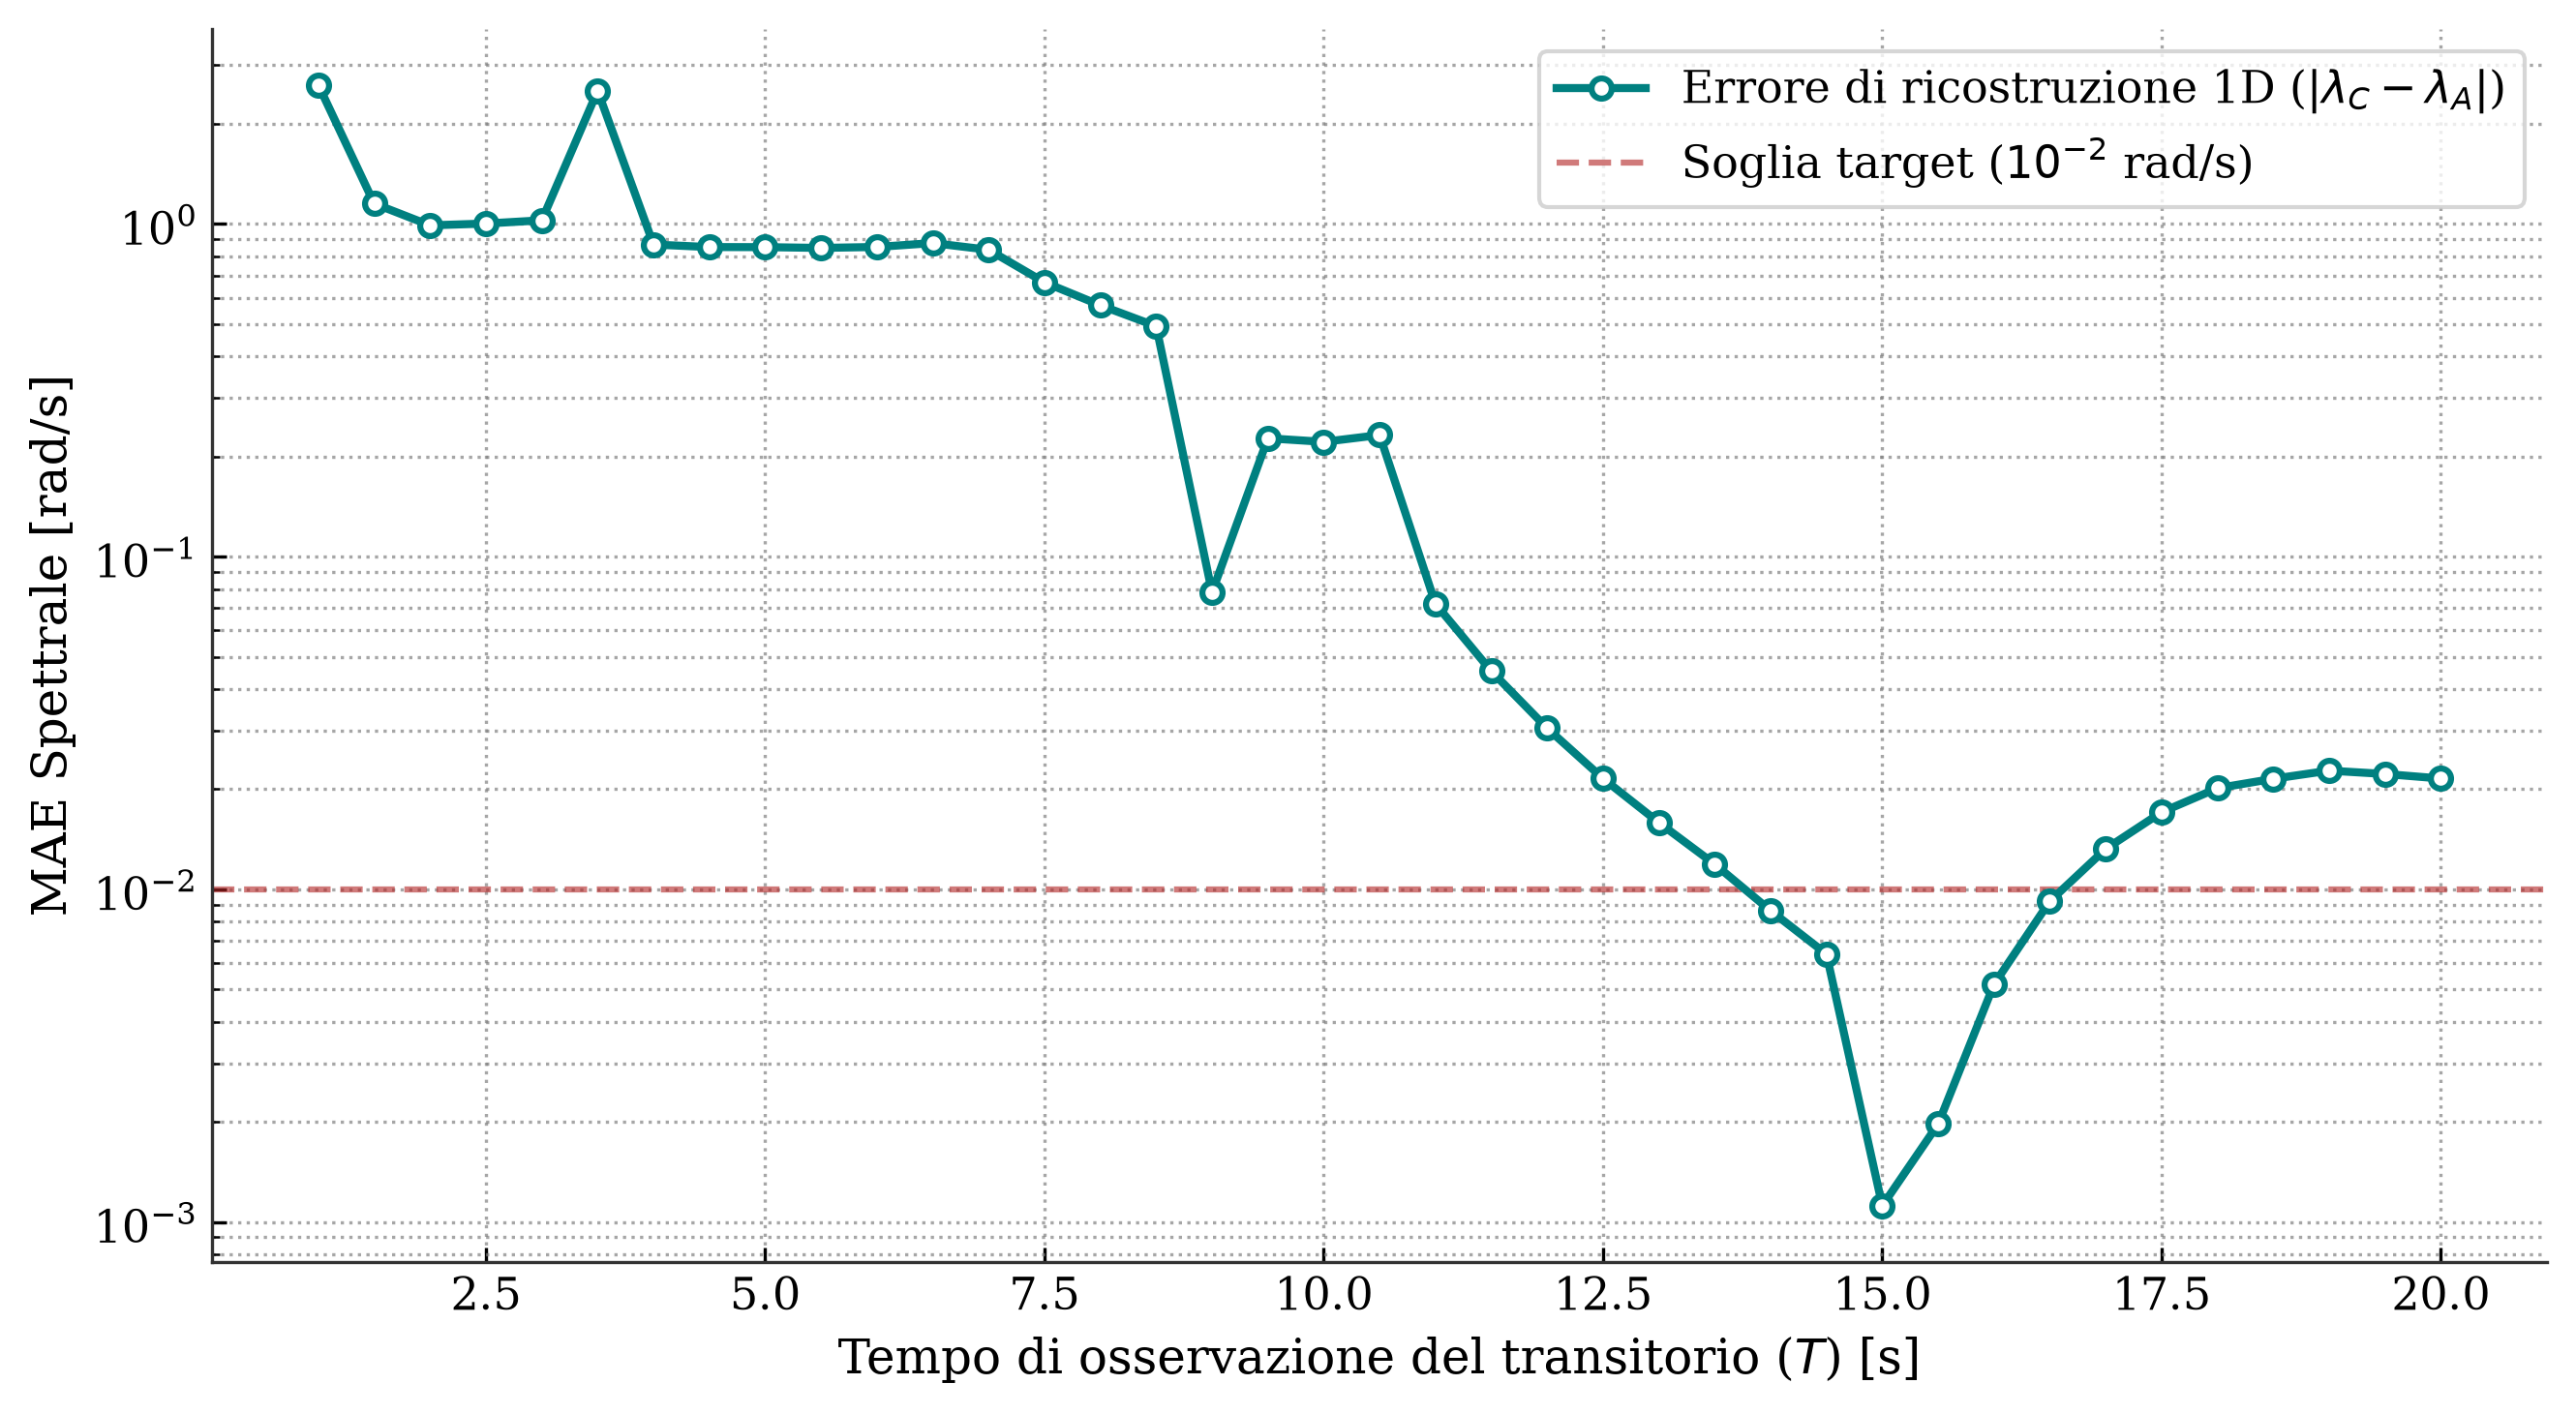

Sweet-spot inferenziale: T = 15.0 s | MAE = 1.119e-03 rad/s
Errore spettrale medio finale a t = 20.0s: 2.15e-02 rad/s


In [ ]:
# =============================================================================
# 9. ANALISI DELL'ERRORE SPETTRALE VS TEMPO DI OSSERVAZIONE (Ablazione 1D)
# =============================================================================
import warnings
warnings.filterwarnings('ignore') # NOTA: nasconde i warning dovuti all'ill-conditioning
#ma vengono commentati sotto

n_trains = np.arange(10, 201, 5)
errori_spettrali = []

# Manteniamo la regolarizzazione del blocco 8-BIS
lam_opt = 1e-14

lambda_A_sorted = lambda_A[np.argsort(np.imag(lambda_A))]

for n in n_trains:
    # 1. Troncamento serie temporale
    u_train_n = u_integrato[:n, 1].reshape(-1, 1)
    
    # 2. Integrazione reservoir (senza spin-up, partendo da zero)
    h_train_n = open_loop(u_train_n, np.zeros(N), W, Win_1d, b, alpha)
    
    # 3. Addestramento Wout
    H_n = h_train_n[:-1]
    Y_n = u_train_n[1:]
    Wout_n_raw = ridge_regression(H_n, Y_n, alpha=lam_opt)
    Wout_n = Wout_n_raw.reshape(1, N)
    
    # 4. Spettro inferito
    W_tot_n = W + Win_1d @ Wout_n
    W_eff_D_n = np.eye(N) + alpha * (W_tot_n - np.eye(N))
    lambda_D_n, V_n = la.eig(W_eff_D_n)
    lambda_C_n = np.log(lambda_D_n) / dt
    
    # 5. Calcolo Mode Strengths
    d_n = alpha * b
    h_star_n = la.solve(np.eye(N) - W_eff_D_n, d_n)
    S_n = compute_time_averaged_mode_strengths(V=V_n, 
                                               trajectory=h_train_n, 
                                               fixed_point=h_star_n, 
                                               observation_matrix=Wout_n)
    
    # 6. Estrazione dei 4 poli dominanti e ordinamento
    indici_dom_n = np.argsort(S_n)[-4:]
    lambda_C_dom_n = lambda_C_n[indici_dom_n]
    lambda_C_dom_n_sorted = lambda_C_dom_n[np.argsort(np.imag(lambda_C_dom_n))]
    
    # 7. Errore Medio Assoluto (MAE)
    errore = np.mean(np.abs(lambda_C_dom_n_sorted - lambda_A_sorted))
    errori_spettrali.append(errore)

# =============================================================================
# VISUALIZZAZIONE DEL GRAFICO DI CONVERGENZA
# =============================================================================
tempi_fisici = n_trains * dt

plt.figure(figsize=(9, 5), dpi=300)

plt.semilogy(tempi_fisici, errori_spettrali, marker='o', color='teal', 
             linewidth=2, markersize=5, markerfacecolor='white', markeredgewidth=1.5, 
             zorder=3, label=r"Errore di ricostruzione 1D ($|\lambda_C - \lambda_A|$)")

plt.axhline(1e-2, color='firebrick', lw=1.5, ls='--', alpha=0.6, label="Soglia target ($10^{-2}$ rad/s)")
plt.xlabel("Tempo di osservazione del transitorio ($T$) [s]", fontsize=12)
plt.ylabel(r"MAE Spettrale [rad/s]", fontsize=12)

plt.grid(True, which="both", linestyle=':', alpha=0.7, color='gray')
plt.legend(loc="upper right", fontsize=11, frameon=True, facecolor='white')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('convergenza_errore_spettrale_1d.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Conferma numerica del punto di minimo
idx_min = np.argmin(errori_spettrali)
print(f"Sweet-spot inferenziale: T = {tempi_fisici[idx_min]:.1f} s | MAE = {errori_spettrali[idx_min]:.3e} rad/s")
# Stampa del plateau finale

print(f"Errore spettrale medio finale a t = {tempi_fisici[-1]:.1f}s: {errori_spettrali[-1]:.2e} rad/s")

L'andamento di $\mathcal{E}(T)$ evidenzia tre regimi fisici distinti, nella finestra temporale considerata:
1. **Regime di under-embedding ($T < 10$ s):** Per finestre brevi, la storia osservata non è sufficiente a discriminare in modo affidabile le quattro componenti dinamiche latenti.
2. **Transizione e minimo locale ($10$ s $\le T \le 15$ s):** Superata la soglia critica di *embedding*, l'errore crolla rapidamente, raggiungendo un minimo assoluto dell'ordine di $10^{−3}\,rad/s$ in corrispondenza di $T = 15$ s.
3. **Plateau asintotico ($T > 15$ s):** Dopo una risalita che riflette la natura non monotona della selezione dei modi dominanti durante il riaddestramento del reservoir, l'errore tende infine a stabilizzarsi su un valore residuo, indicando che l'aggiunta di ulteriore informazione temporale non produce miglioramenti sostanziali dell'inferenza.

NOTA: L'utilizzo di una regolarizzazione estremamente debole conduce a un problema di regressione fortemente mal condizionato in alcune finestre temporali, come evidenziato dai warning numerici e dagli elevati numeri di condizionamento. Tuttavia, il minimo dell'errore spettrale osservato intorno a $T=15$ s mostra che, per quella durata della finestra di training e nella configurazione considerata con $\lambda=10^{-14}$, la corrispondenza tra i quattro poli inferiti e quelli teorici risulta la più accurata, a conferma della scelta effettuata nella sezione precedente per spingere al limite assoluto la risoluzione spettrale in quel preciso istante.

Notifichiamo inoltre che l'incremento successivo a 15s può essere associato alla maggiore sensibilità della procedura di regressione e dell'estrazione spettrale al condizionamento numerico, particolarmente rilevante nel regime di regolarizzazione molto debole.

## Test di Robustezza Asintotica ($\lambda = 10^{-8}$)

L'impiego di una regolarizzazione infinitesima ha permesso di confermare l'istante esatto in cui l'informazione latente viene massimizzata ($T=15$ s), ma rende la matrice suscettibile al rumore numerico per tempi di osservazione superiori. 
Per dimostrare la solidità strutturale dell'architettura lRNN, si ripete l'analisi ripristinando una regolarizzazione conservativa ($\lambda = 10^{-8}$), identica a quella impiegata per l'oscillatore armonico semplice. L'obiettivo è verificare se, rinunciando alla precisione locale, il modello garantisce la stabilità asintotica.

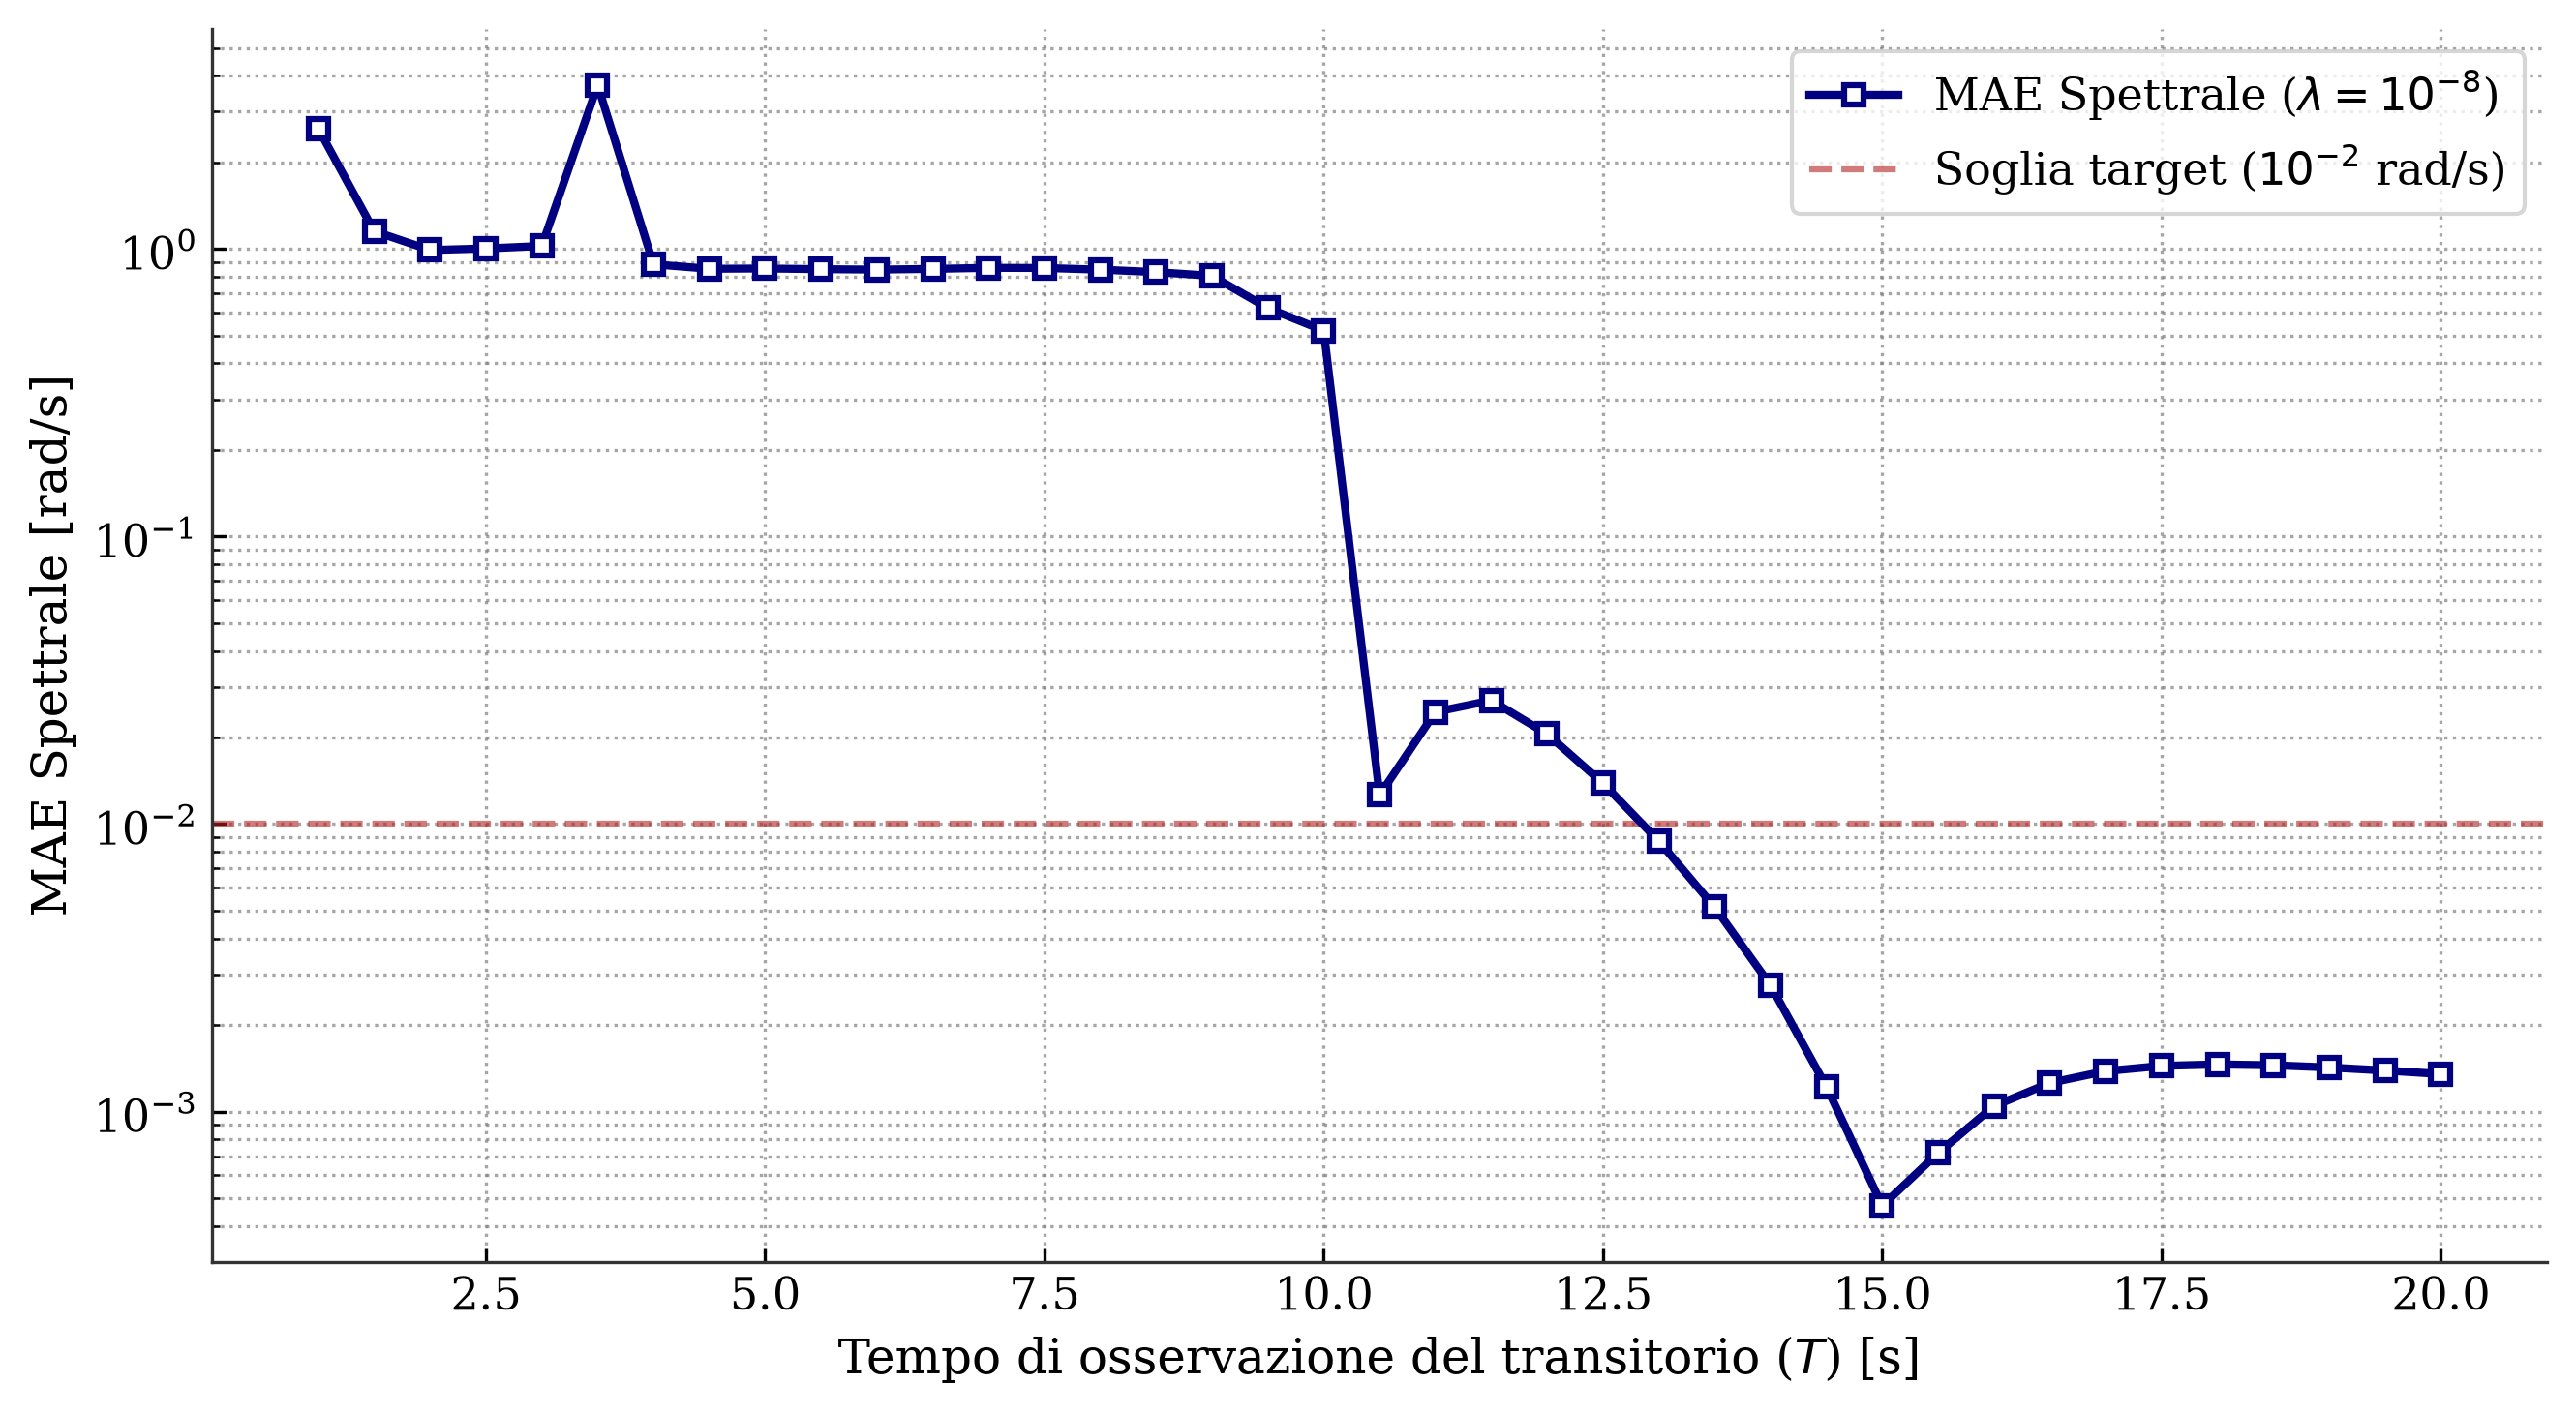

In [ ]:
# =============================================================================
# ANALISI DI ROBUSTEZZA ASINTOTICA (Regolarizzazione Strutturale)
# =============================================================================

# Qui non nascondiamo i warning perché la matrice è ben condizionata
errori_spettrali_robusti = []
lam_robusto = 1e-8

for n in n_trains:
    u_train_n = u_integrato[:n, 1].reshape(-1, 1)
    h_train_n = open_loop(u_train_n, np.zeros(N), W, Win_1d, b, alpha)
    
    H_n = h_train_n[:-1]
    Y_n = u_train_n[1:]
    
    # Regressione stabile
    Wout_n_raw = ridge_regression(H_n, Y_n, alpha=lam_robusto)
    Wout_n = Wout_n_raw.reshape(1, N)
    
    W_tot_n = W + Win_1d @ Wout_n
    W_eff_D_n = np.eye(N) + alpha * (W_tot_n - np.eye(N))
    lambda_D_n, V_n = la.eig(W_eff_D_n)
    lambda_C_n = np.log(lambda_D_n) / dt
    
    d_n = alpha * b
    h_star_n = la.solve(np.eye(N) - W_eff_D_n, d_n)
    S_n = compute_time_averaged_mode_strengths(V=V_n, 
                                               trajectory=h_train_n, 
                                               fixed_point=h_star_n, 
                                               observation_matrix=Wout_n)
    
    indici_dom_n = np.argsort(S_n)[-4:]
    lambda_C_dom_n = lambda_C_n[indici_dom_n]
    lambda_C_dom_n_sorted = lambda_C_dom_n[np.argsort(np.imag(lambda_C_dom_n))]
    
    errore = np.mean(np.abs(lambda_C_dom_n_sorted - lambda_A_sorted))
    errori_spettrali_robusti.append(errore)

# --- GRAFICO ---
plt.figure(figsize=(9, 5), dpi=300)

plt.semilogy(tempi_fisici, errori_spettrali_robusti, marker='s', color='navy', 
             linewidth=2, markersize=5, markerfacecolor='white', markeredgewidth=1.5, 
             zorder=3, label=r"MAE Spettrale ($\lambda = 10^{-8}$)")

plt.axhline(1e-2, color='firebrick', lw=1.5, ls='--', alpha=0.6, label="Soglia target ($10^{-2}$ rad/s)")
plt.xlabel("Tempo di osservazione del transitorio ($T$) [s]", fontsize=12)
plt.ylabel(r"MAE Spettrale [rad/s]", fontsize=12)

plt.grid(True, which="both", linestyle=':', alpha=0.7, color='gray')
plt.legend(loc="upper right", fontsize=11, frameon=True, facecolor='white')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('robustezza_errore_spettrale_1d.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Disaccoppiamento tra accuratezza di fitting e inferenza spettrale

Un quesito fondamentale nell'applicazione del *Machine Learning* ai sistemi dinamici riguarda la relazione tra la capacità predittiva fenomenologica e la comprensione della struttura fisica latente. Una minimizzazione efficace dell'errore di predizione sulla traiettoria (basso RMSE) implica necessariamente la corretta inferenza della struttura spettrale sottostante?

Estendiamo quindi l'analisi di convergenza confrontando simultaneamente l'evoluzione dell'Errore Quadratico Medio di *fitting* sull'osservabile (RMSE) e l'Errore Spettrale Medio Assoluto (MAE) in funzione della finestra temporale di osservazione $T$.

Calcolo simultaneo di MAE spettrale e RMSE su 39 finestre temporali...


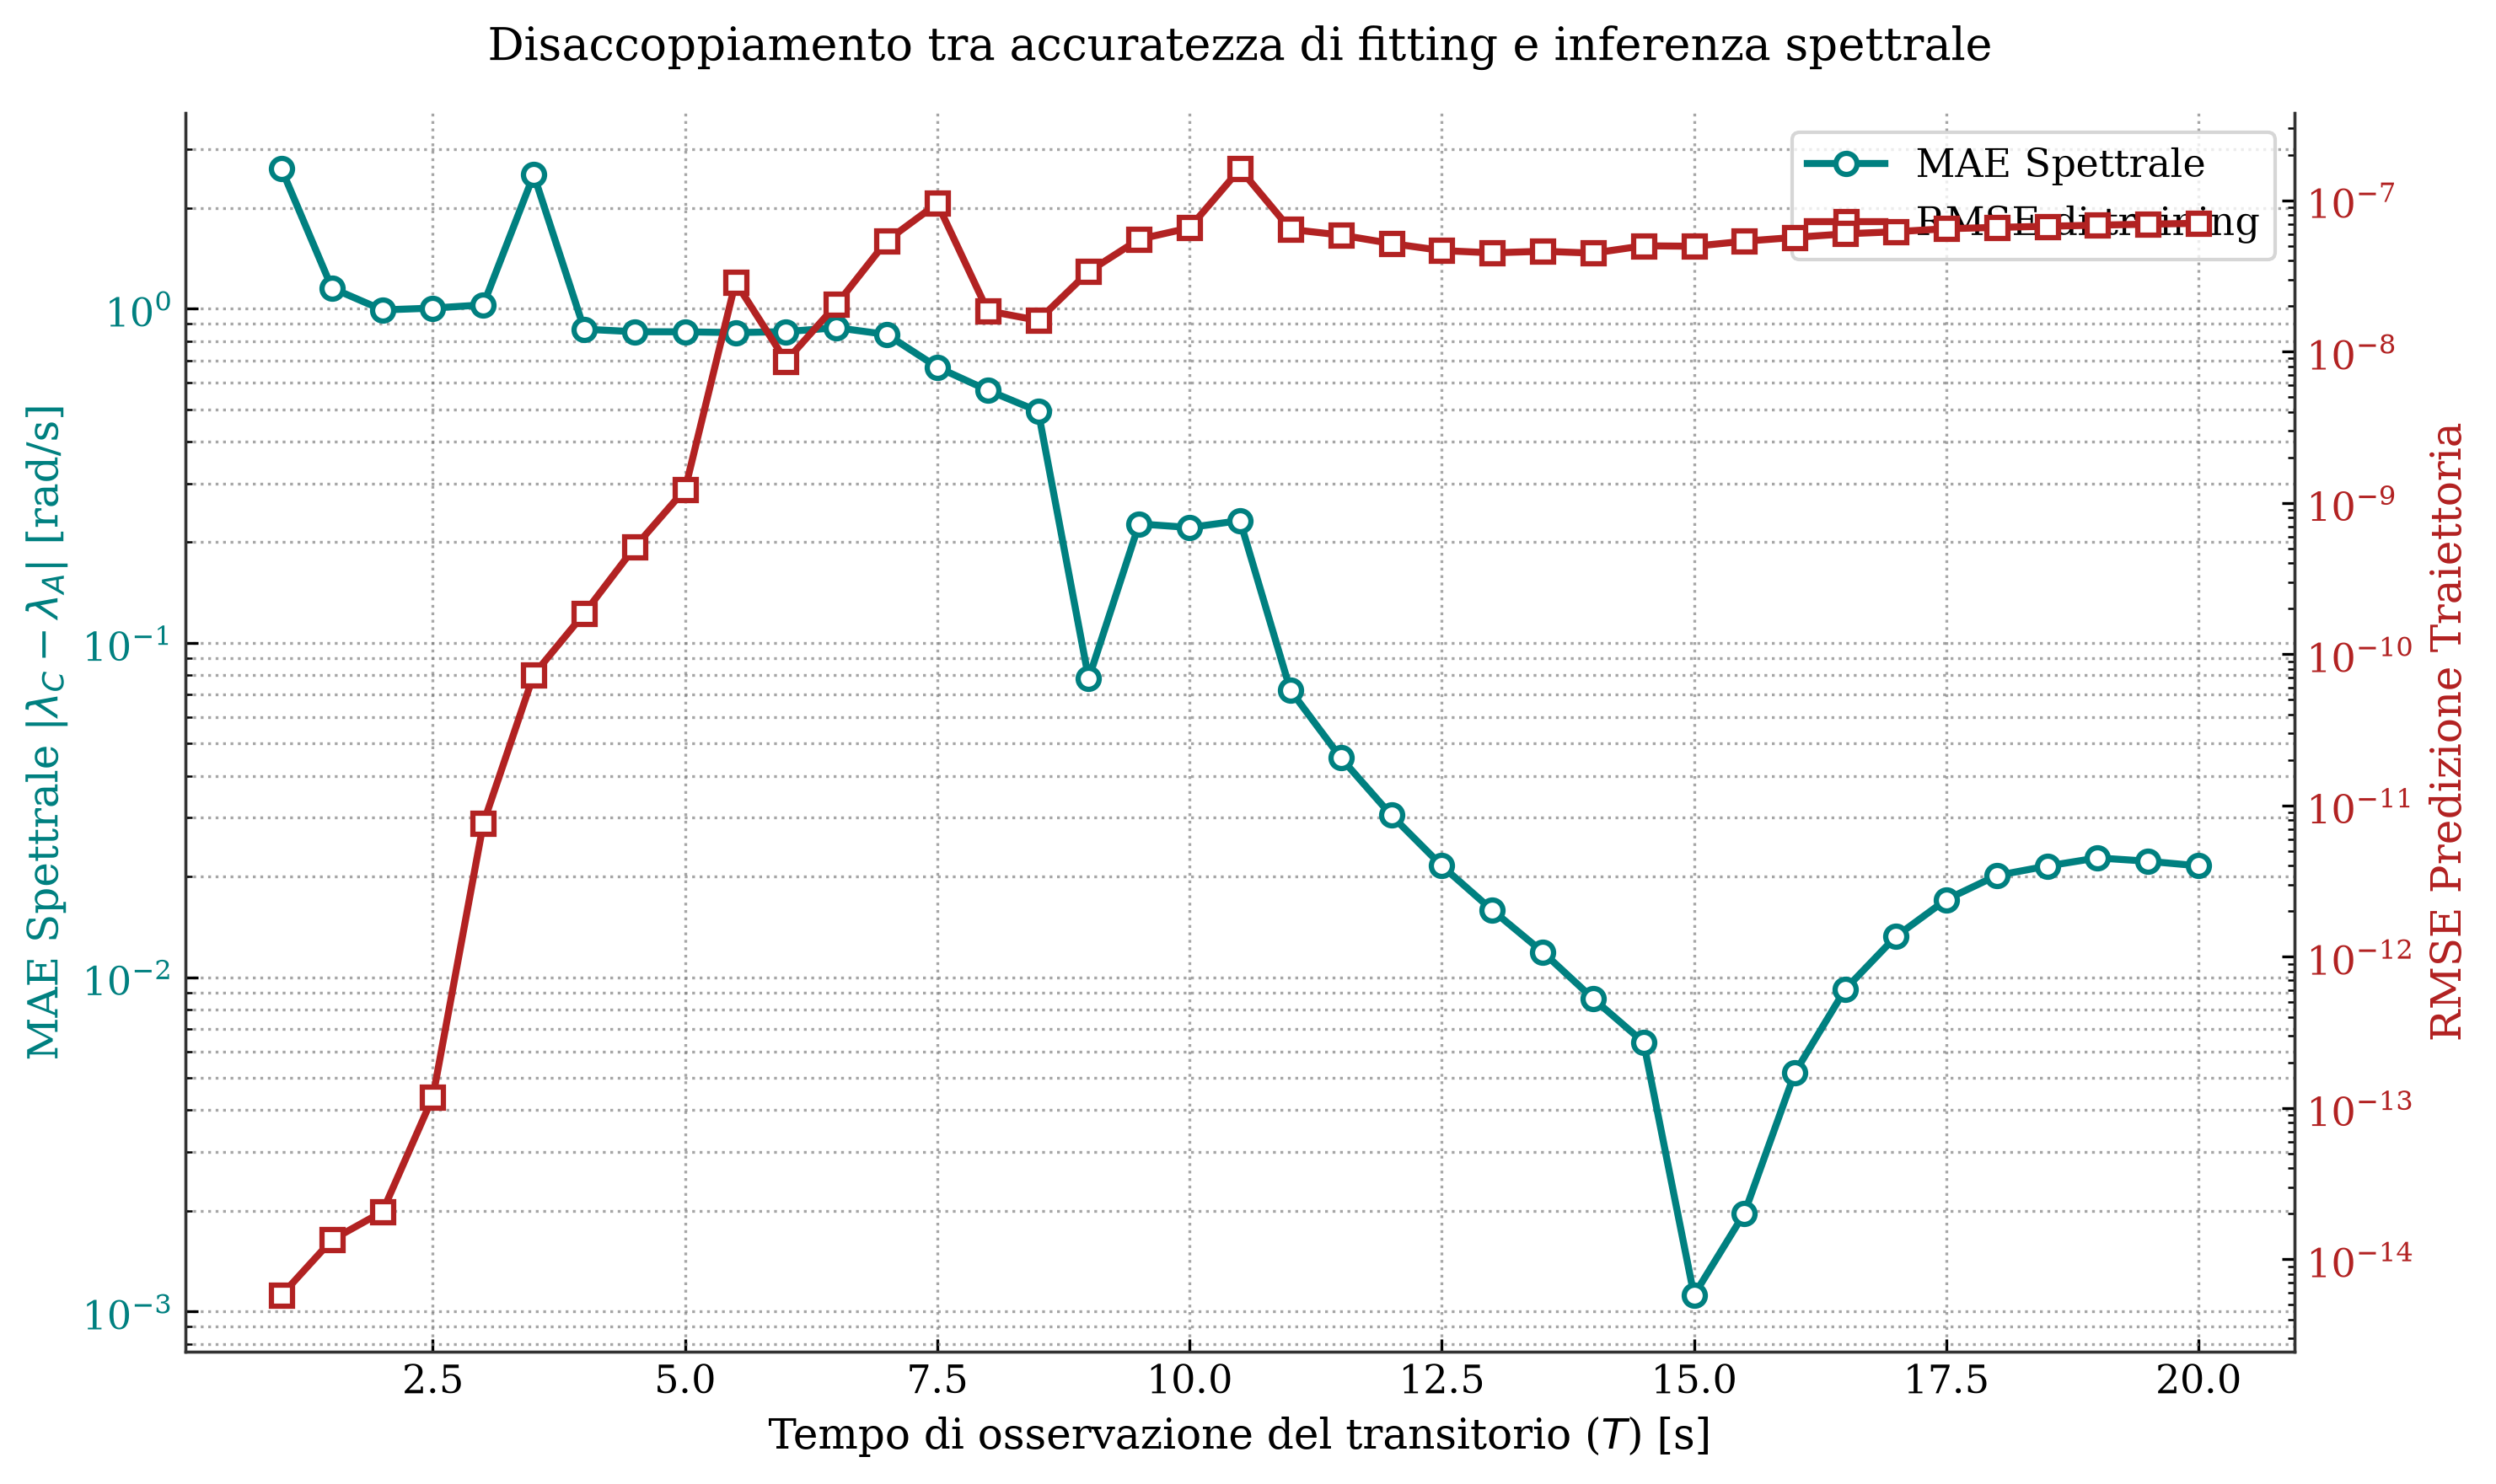

In [45]:
# =============================================================================
# 10. CONFRONTO DI CONVERGENZA: ERRORE SPETTRALE VS RMSE 
# =============================================================================

n_trains = np.arange(10, 201, 5)
errori_spettrali = []
errori_rmse = []

# Manteniamo la regolarizzazione strutturale stabile
lam_opt = 1e-14
lambda_A_sorted = lambda_A[np.argsort(np.imag(lambda_A))]

print(f"Calcolo simultaneo di MAE spettrale e RMSE su {len(n_trains)} finestre temporali...")

for n in n_trains:
    # 1. Troncamento serie temporale
    u_train_n = u_integrato[:n, 1].reshape(-1, 1)
    
    # 2. Integrazione reservoir (senza spin-up, partendo da zero)
    h_train_n = open_loop(u_train_n, np.zeros(N), W, Win_1d, b, alpha)
    
    # 3. Addestramento Wout
    H_n = h_train_n[:-1]
    Y_n = u_train_n[1:]
    Wout_n_raw = ridge_regression(H_n, Y_n, alpha=lam_opt)
    Wout_n = Wout_n_raw.reshape(1, N)
    
    # --- CALCOLO RMSE SUL READOUT ---
    train_pred_n = H_n @ Wout_n.T
    rmse_n = np.sqrt(np.mean((train_pred_n - Y_n)**2))
    errori_rmse.append(rmse_n)
    
    # 4. Spettro inferito
    W_tot_n = W + Win_1d @ Wout_n
    W_eff_D_n = np.eye(N) + alpha * (W_tot_n - np.eye(N))
    lambda_D_n, V_n = la.eig(W_eff_D_n)
    lambda_C_n = np.log(lambda_D_n) / dt
    
    # 5. Calcolo Mode Strengths
    d_n = alpha * b
    h_star_n = la.solve(np.eye(N) - W_eff_D_n, d_n)
    S_n = compute_time_averaged_mode_strengths(V=V_n, 
                                               trajectory=h_train_n, 
                                               fixed_point=h_star_n, 
                                               observation_matrix=Wout_n)
    
    # 6. Estrazione e sorting dei 4 poli dominanti
    indici_dom_n = np.argsort(S_n)[-4:]
    lambda_C_dom_n = lambda_C_n[indici_dom_n]
    lambda_C_dom_n_sorted = lambda_C_dom_n[np.argsort(np.imag(lambda_C_dom_n))]
    
    # 7. Errore Medio Assoluto (MAE)
    errore = np.mean(np.abs(lambda_C_dom_n_sorted - lambda_A_sorted))
    errori_spettrali.append(errore)

# =============================================================================
# VISUALIZZAZIONE DEL GRAFICO A DOPPIO ASSE
# =============================================================================
tempi_fisici = n_trains * dt

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# --- Asse Sinistro: Errore Spettrale (MAE) ---
color_mae = 'teal'
ax1.set_xlabel("Tempo di osservazione del transitorio ($T$) [s]", fontsize=12)
ax1.set_ylabel(r"MAE Spettrale $|\lambda_C - \lambda_A|$ [rad/s]", color=color_mae, fontsize=12)

line1 = ax1.semilogy(tempi_fisici, errori_spettrali, marker='o', color=color_mae, 
                     linewidth=2, markersize=6, markerfacecolor='white', markeredgewidth=1.5,
                     label=r"MAE Spettrale")
ax1.tick_params(axis='y', labelcolor=color_mae)
ax1.grid(True, which="both", linestyle=':', alpha=0.7, color='gray')

# --- Asse Destro: Errore di Traiettoria (RMSE) ---
ax2 = ax1.twinx()  
color_rmse = 'firebrick'
ax2.set_ylabel(r"RMSE Predizione Traiettoria", color=color_rmse, fontsize=12)  

line2 = ax2.semilogy(tempi_fisici, errori_rmse, marker='s', color=color_rmse, 
                     linewidth=2, markersize=6, markerfacecolor='white', markeredgewidth=1.5,
                     label=r"RMSE di training")
ax2.tick_params(axis='y', labelcolor=color_rmse)

# --- Gestione unificata della legenda ---
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=11, frameon=True, facecolor='white')

# Pulizia assi superiori
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.title("Disaccoppiamento tra accuratezza di fitting e inferenza spettrale", fontsize=13, pad=15)
plt.tight_layout()
#plt.savefig('confronto_convergenza_rmse_mae.pdf', dpi=300, bbox_inches='tight')
plt.show()

L'analisi rivela una marcata separazione delle scale temporali di convergenza. La regressione di Ridge è in grado di ottimizzare i pesi di *readout* per minimizzare l'RMSE fin dai primissimi istanti (raggiungendo quasi la precisione di macchina $\sim 10^{-14}$ per pura interpolazione algebrica su pochissimi campioni), stabilizzandosi poi su un valore asintotico trascurabile attorno a $10^{-7}$.L'inferenza topologica, al contrario, necessita di un accumulo di informazione differenziale nella memoria del reservoir superiore. Il crollo del MAE spettrale avviene solo quando la finestra temporale diviene sufficientemente ampia da ricostruire la dinamica latente, dimostrando una dissociazione empirica tra errore di fitting della traiettoria ed errore di inferenza spettrale.

Concludiamo quindi che un basso errore di ricostruzione dell'osservabile non implica necessariamente un'accurata inferenza della struttura spettrale; in altre parole l'accuratezza predittiva standard (RMSE) è una condizione necessaria ma non sufficiente per l'inferenza fisica: un modello puramente *data-driven* può interpolare perfettamente una dinamica caotica o transitoria pur mantenendo una rappresentazione spettrale interna completamente errata.

## Analisi delle Componenti Principali (PCA) e dimensionalità efficace

L'inferenza spettrale precedente ha mostrato che la lRNN, ricevendo esclusivamente la singola osservabile y(t), è in grado di recuperare i quattro modi dinamici del sistema target. È ora interessante caratterizzare la struttura geometrica della rappresentazione interna che rende possibile tale inferenza.

A questo scopo viene applicata un'Analisi delle Componenti Principali (PCA) alla traiettoria degli stati interni del reservoir durante la stessa finestra transitoria utilizzata per l'addestramento 1D.

Sebbene lo stato del reservoir evolva in uno spazio ad altissima dimensionalità ($N=300$), la PCA permette di verificare empiricamente se la traiettoria osservata degli stati interni sia concentrata in un sottospazio lineare di dimensione inferiore. La frazione di varianza spiegata dalle prime componenti (visualizzata tramite lo *Scree Plot*) permette di stimare empiricamente questa dimensionalità lineare efficace della rappresentazione ottenuta nella specifica finestra temporale analizzata.

Se la rappresentazione interna conserva una descrizione a bassa dimensionalità della dinamica fisica, ci si aspetta che una frazione elevata della varianza sia concentrata in un numero limitato di componenti principali. L'analisi PCA viene quindi utilizzata come misura indipendente della dimensionalità lineare efficace della rappresentazione interna, senza assumere a priori che essa debba coincidere con la dimensione dello stato fisico.

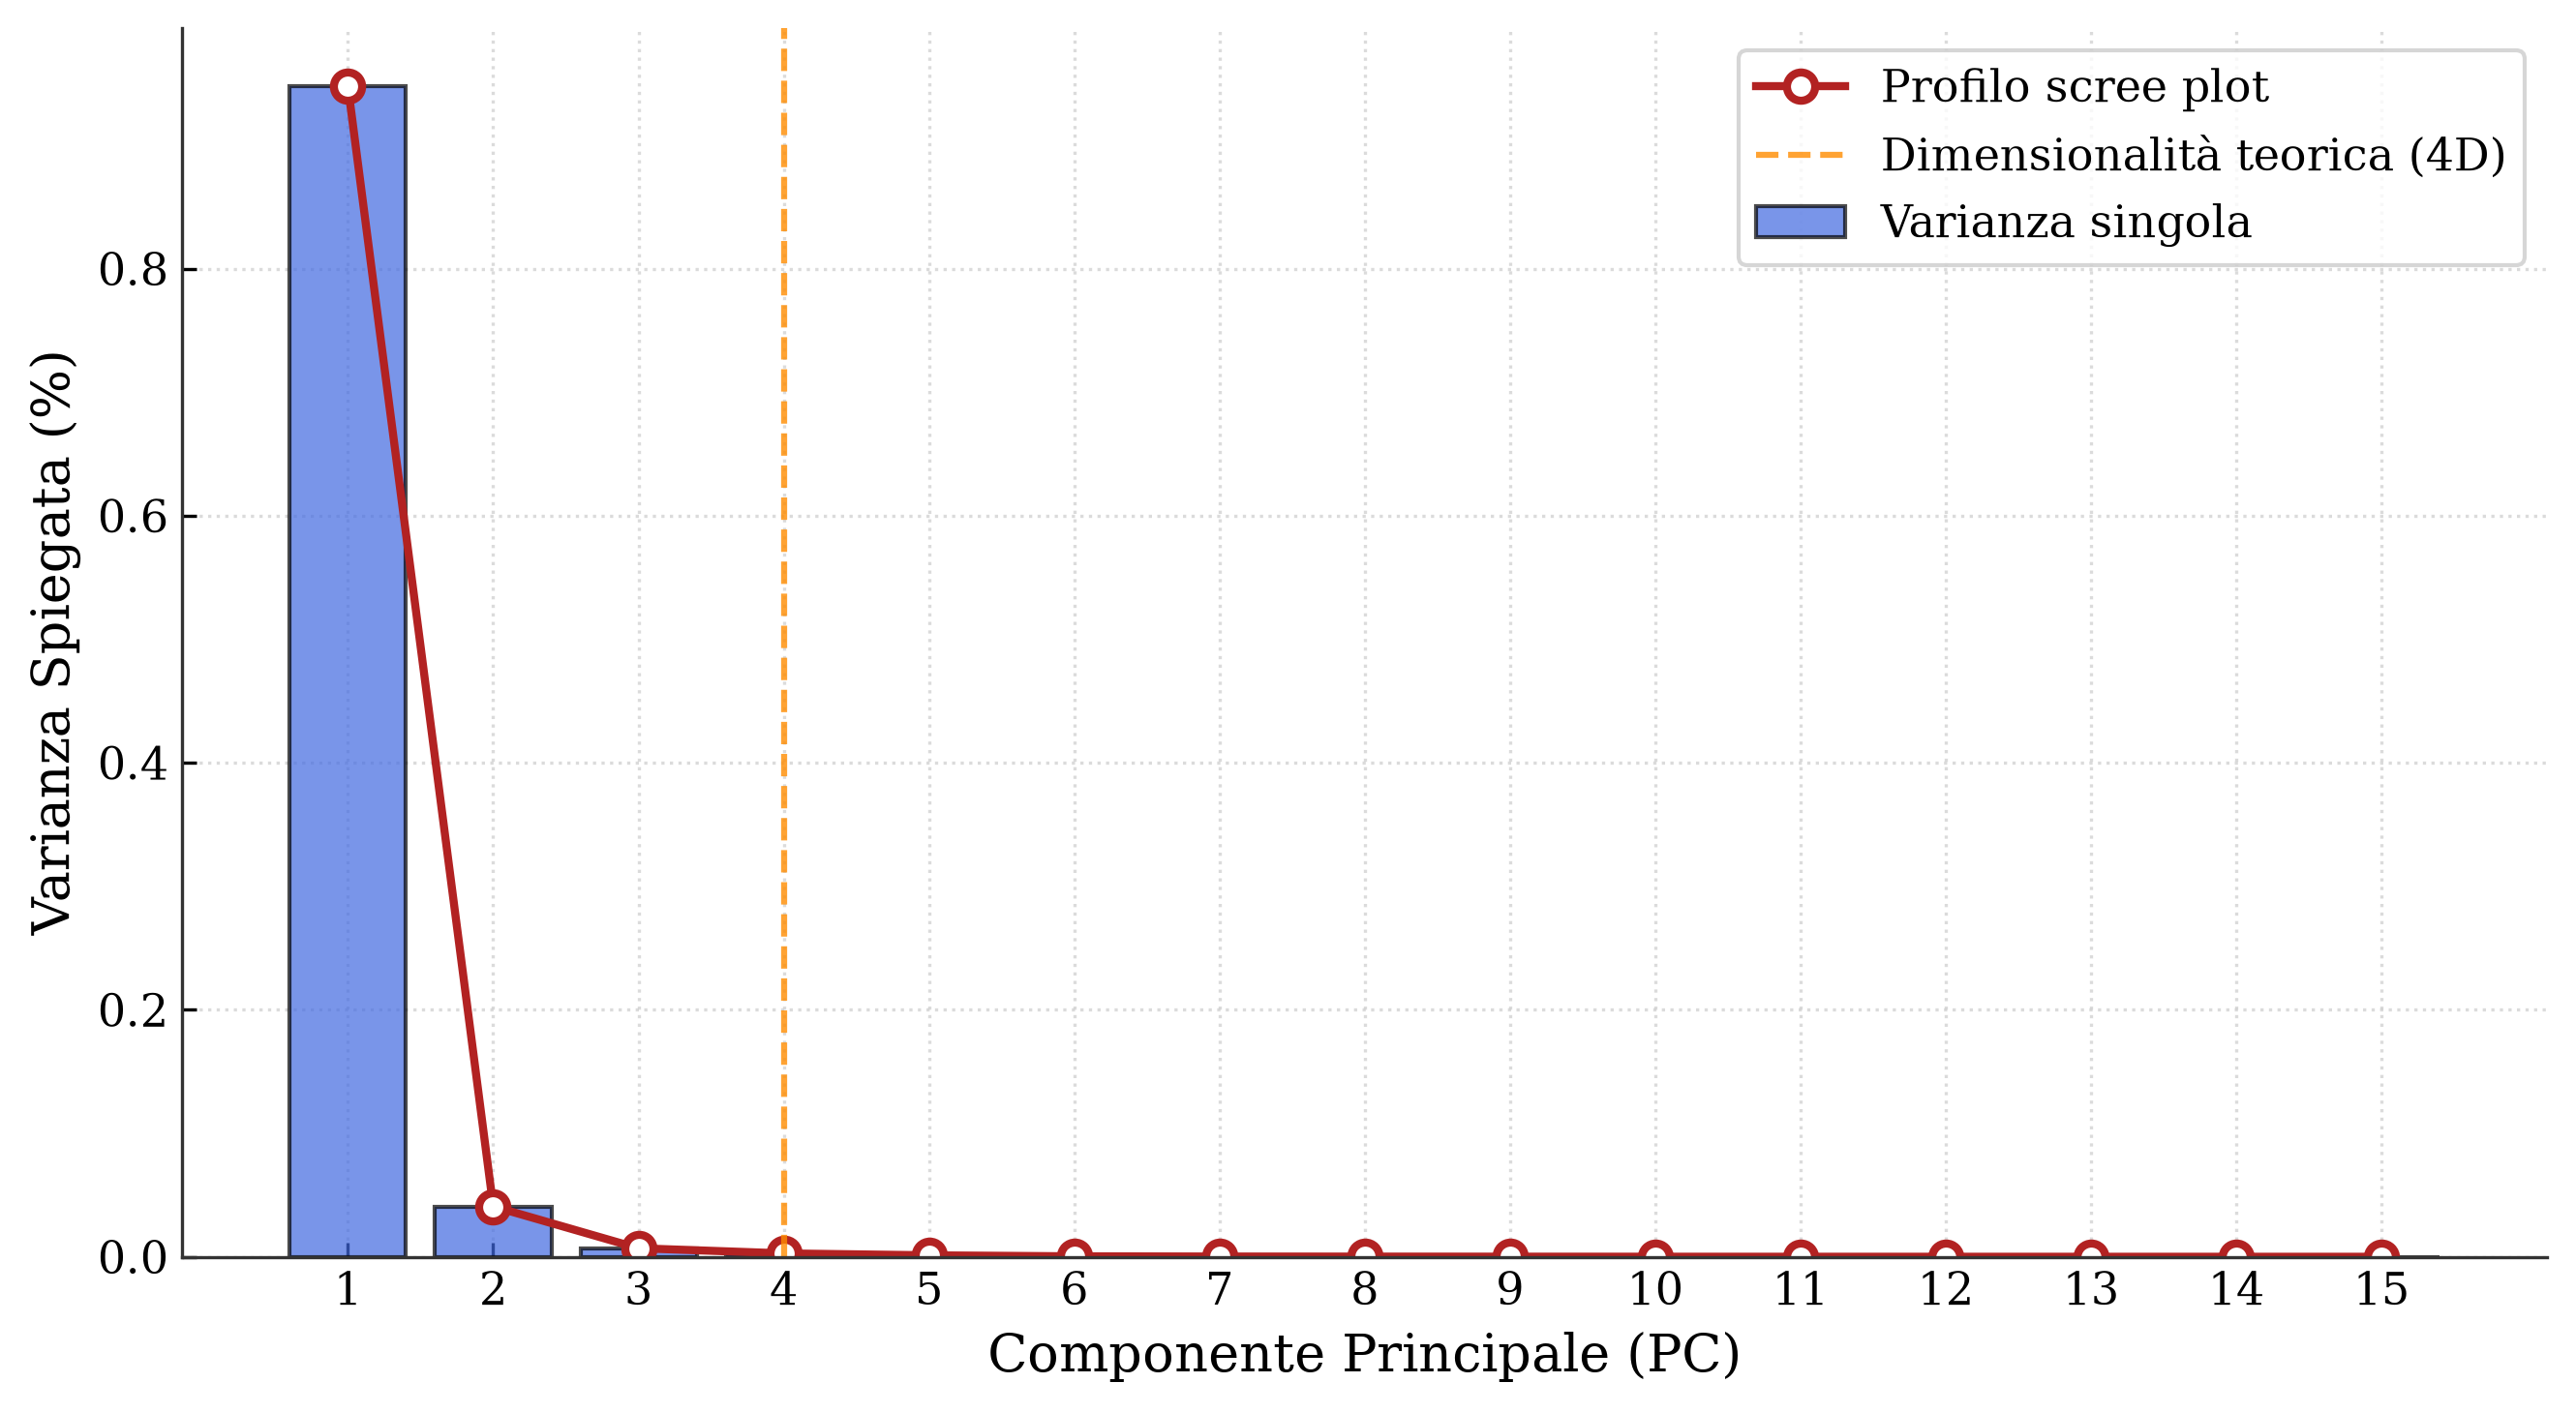

=== VARIANZA SPIEGATA SUL TRANSITORIO (ABLAZIONE 1D) ===
Componente 1: 94.7385%
Componente 2: 4.0789%
Componente 3: 0.6916%
Componente 4: 0.2756%
Componente 5: 0.1204%
Componente 6: 0.0376%

Varianza totale prime 4 componenti: 99.7846%


In [ ]:
# =============================================================================
# 11.1 PCA DEGLI STATI INTERNI E SCREE PLOT (Scala Lineare)
# =============================================================================
from sklearn.decomposition import PCA

# Inizializziamo ed eseguiamo la PCA sugli stati interni del Reservoir
# (Usiamo h_train_breve, derivato esclusivamente dall'input 1D sul transitorio)
pca_breve = PCA()
pca_breve.fit(h_train_breve_1d)

# Estraiamo la percentuale di varianza spiegata da ciascuna componente
var_ratio_breve = pca_breve.explained_variance_ratio_

# =============================================================================
# VISUALIZZAZIONE SCREE PLOT
# =============================================================================
plt.figure(figsize=(9, 5), dpi=300)

# Plottiamo le prime 15 componenti 
n_components_to_plot = 15
componenti = np.arange(1, n_components_to_plot + 1)

# Barre della varianza individuale
plt.bar(componenti, var_ratio_breve[:n_components_to_plot], color='royalblue', edgecolor='black', alpha=0.7, zorder=2, label='Varianza singola')

# Linea di trend
plt.plot(componenti, var_ratio_breve[:n_components_to_plot], 
         marker='o', linestyle='-', color='firebrick', linewidth=2, 
         markersize=7, markerfacecolor='white', markeredgewidth=2,
         label="Profilo scree plot")

# Linea verticale per segnare la dimensionalità teorica attesa
plt.axvline(4, color='darkorange', lw=1.5, ls='--', alpha=0.8, 
            label="Dimensionalità teorica (4D)")

#plt.title("Scree Plot: Dimensionalità Efficace (Scala Lineare)", fontsize=14, pad=15)
plt.xlabel("Componente Principale (PC)", fontsize=13)
plt.ylabel("Varianza Spiegata (%)", fontsize=13)

plt.xticks(componenti)
plt.grid(True, linestyle=':', alpha=0.7, color='#cccccc')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white')

plt.tight_layout()
#plt.savefig('pca_osa.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- Output a terminale dei valori esatti ---
print("=== VARIANZA SPIEGATA SUL TRANSITORIO (ABLAZIONE 1D) ===")
for i in range(6):
    print(f"Componente {i+1}: {var_ratio_breve[i]*100:.4f}%")
print(f"\nVarianza totale prime 4 componenti: {np.sum(var_ratio_breve[:4])*100:.4f}%")

L'analisi PCA degli stati interni del reservoir durante il transitorio mostra una forte concentrazione della varianza in un sottospazio lineare di dimensionalità efficace prossima a 2, con le prime due componenti che spiegano il 98.82% della varianza. Le prime quattro componenti spiegano complessivamente il 99.78% della varianza. Questo non implica che la dinamica sottostante possieda soltanto due modi dinamici: infatti, l'analisi spettrale del reservoir recupera anche i due modi dissipativi associati al transitorio.

Dunque, confermiamo che nonostante il reservoir evolva in uno spazio di 300 dimensioni, la traiettoria degli stati interni durante il transitorio è fortemente concentrata in poche direzioni lineari.

## Analisi delle correlazioni e anatomia dello spazio latente

Per determinare l'interpretazione dinamica delle singole componenti principali, analizziamo in seguito le loro correlazioni con le variabili fisiche del sistema (tramite **Coefficienti di Correlazione di Pearson ($r$)**) e la loro evoluzione temporale.

La correlazione di Pearson quantifica il grado di dipendenza lineare tra due variabili temporali continue. Data una Componente Principale $\text{PC}_i(t)$ e una variabile fisica analitica $v(t)$, il coefficiente è definito come il rapporto tra la covarianza campionaria delle due variabili e il prodotto delle loro deviazioni standard:

$$ r(\mathrm{PC}_i, v) = \frac{\sum_{t=1}^{T} (\text{PC}_i(t) - \overline{\mathrm{PC}_i})(v(t) - \bar{v})}{\sqrt{\sum_{t=1}^{T} (\mathrm{PC}_i(t) - \overline{\mathrm{PC}_i})^2 \sum_{t=1}^{T} (v(t) - \bar{v})^2}} $$

Il coefficiente è strettamente limitato nel range $[-1, 1]$. Un valore prossimo a $\pm 1$ dimostra un allineamento lineare quasi perfetto (diretto o invertito). 
Calcolando la matrice di correlazione tra le componenti proiettate $\mathbf{H}_{\text{pca}}$ e l'esatto stato fisico del sistema originale ($x, y, v_x, v_y$), otterremo la verifica empirica della misura in cui le principali direzioni dello spazio PCA sono associate alle diverse coordinate dello stato fisico. Elevate correlazioni indicano che la rappresentazione interna contiene informazione relativa a variabili che non erano fornite direttamente in ingresso, a conferma del ruolo della memoria temporale del reservoir.

=== CORRELAZIONE PRIME 4 PC CON LO STATO FISICO ===

PC1 (Varianza: 94.7385%):
  corr(x (Posizione Driver)  ) = +0.2209
  corr(y (Posizione Slave)   ) = +0.9801
  corr(v_x (Velocità Driver) ) = -0.9564
  corr(v_y (Velocità Slave)  ) = -0.0202

PC2 (Varianza: 4.0789%):
  corr(x (Posizione Driver)  ) = +0.7541
  corr(y (Posizione Slave)   ) = +0.1896
  corr(v_x (Velocità Driver) ) = +0.1572
  corr(v_y (Velocità Slave)  ) = +0.9042

PC3 (Varianza: 0.6916%):
  corr(x (Posizione Driver)  ) = -0.5457
  corr(y (Posizione Slave)   ) = -0.0378
  corr(v_x (Velocità Driver) ) = -0.0837
  corr(v_y (Velocità Slave)  ) = -0.3540

PC4 (Varianza: 0.2756%):
  corr(x (Posizione Driver)  ) = -0.2768
  corr(y (Posizione Slave)   ) = -0.0448
  corr(v_x (Velocità Driver) ) = +0.1029
  corr(v_y (Velocità Slave)  ) = -0.2312


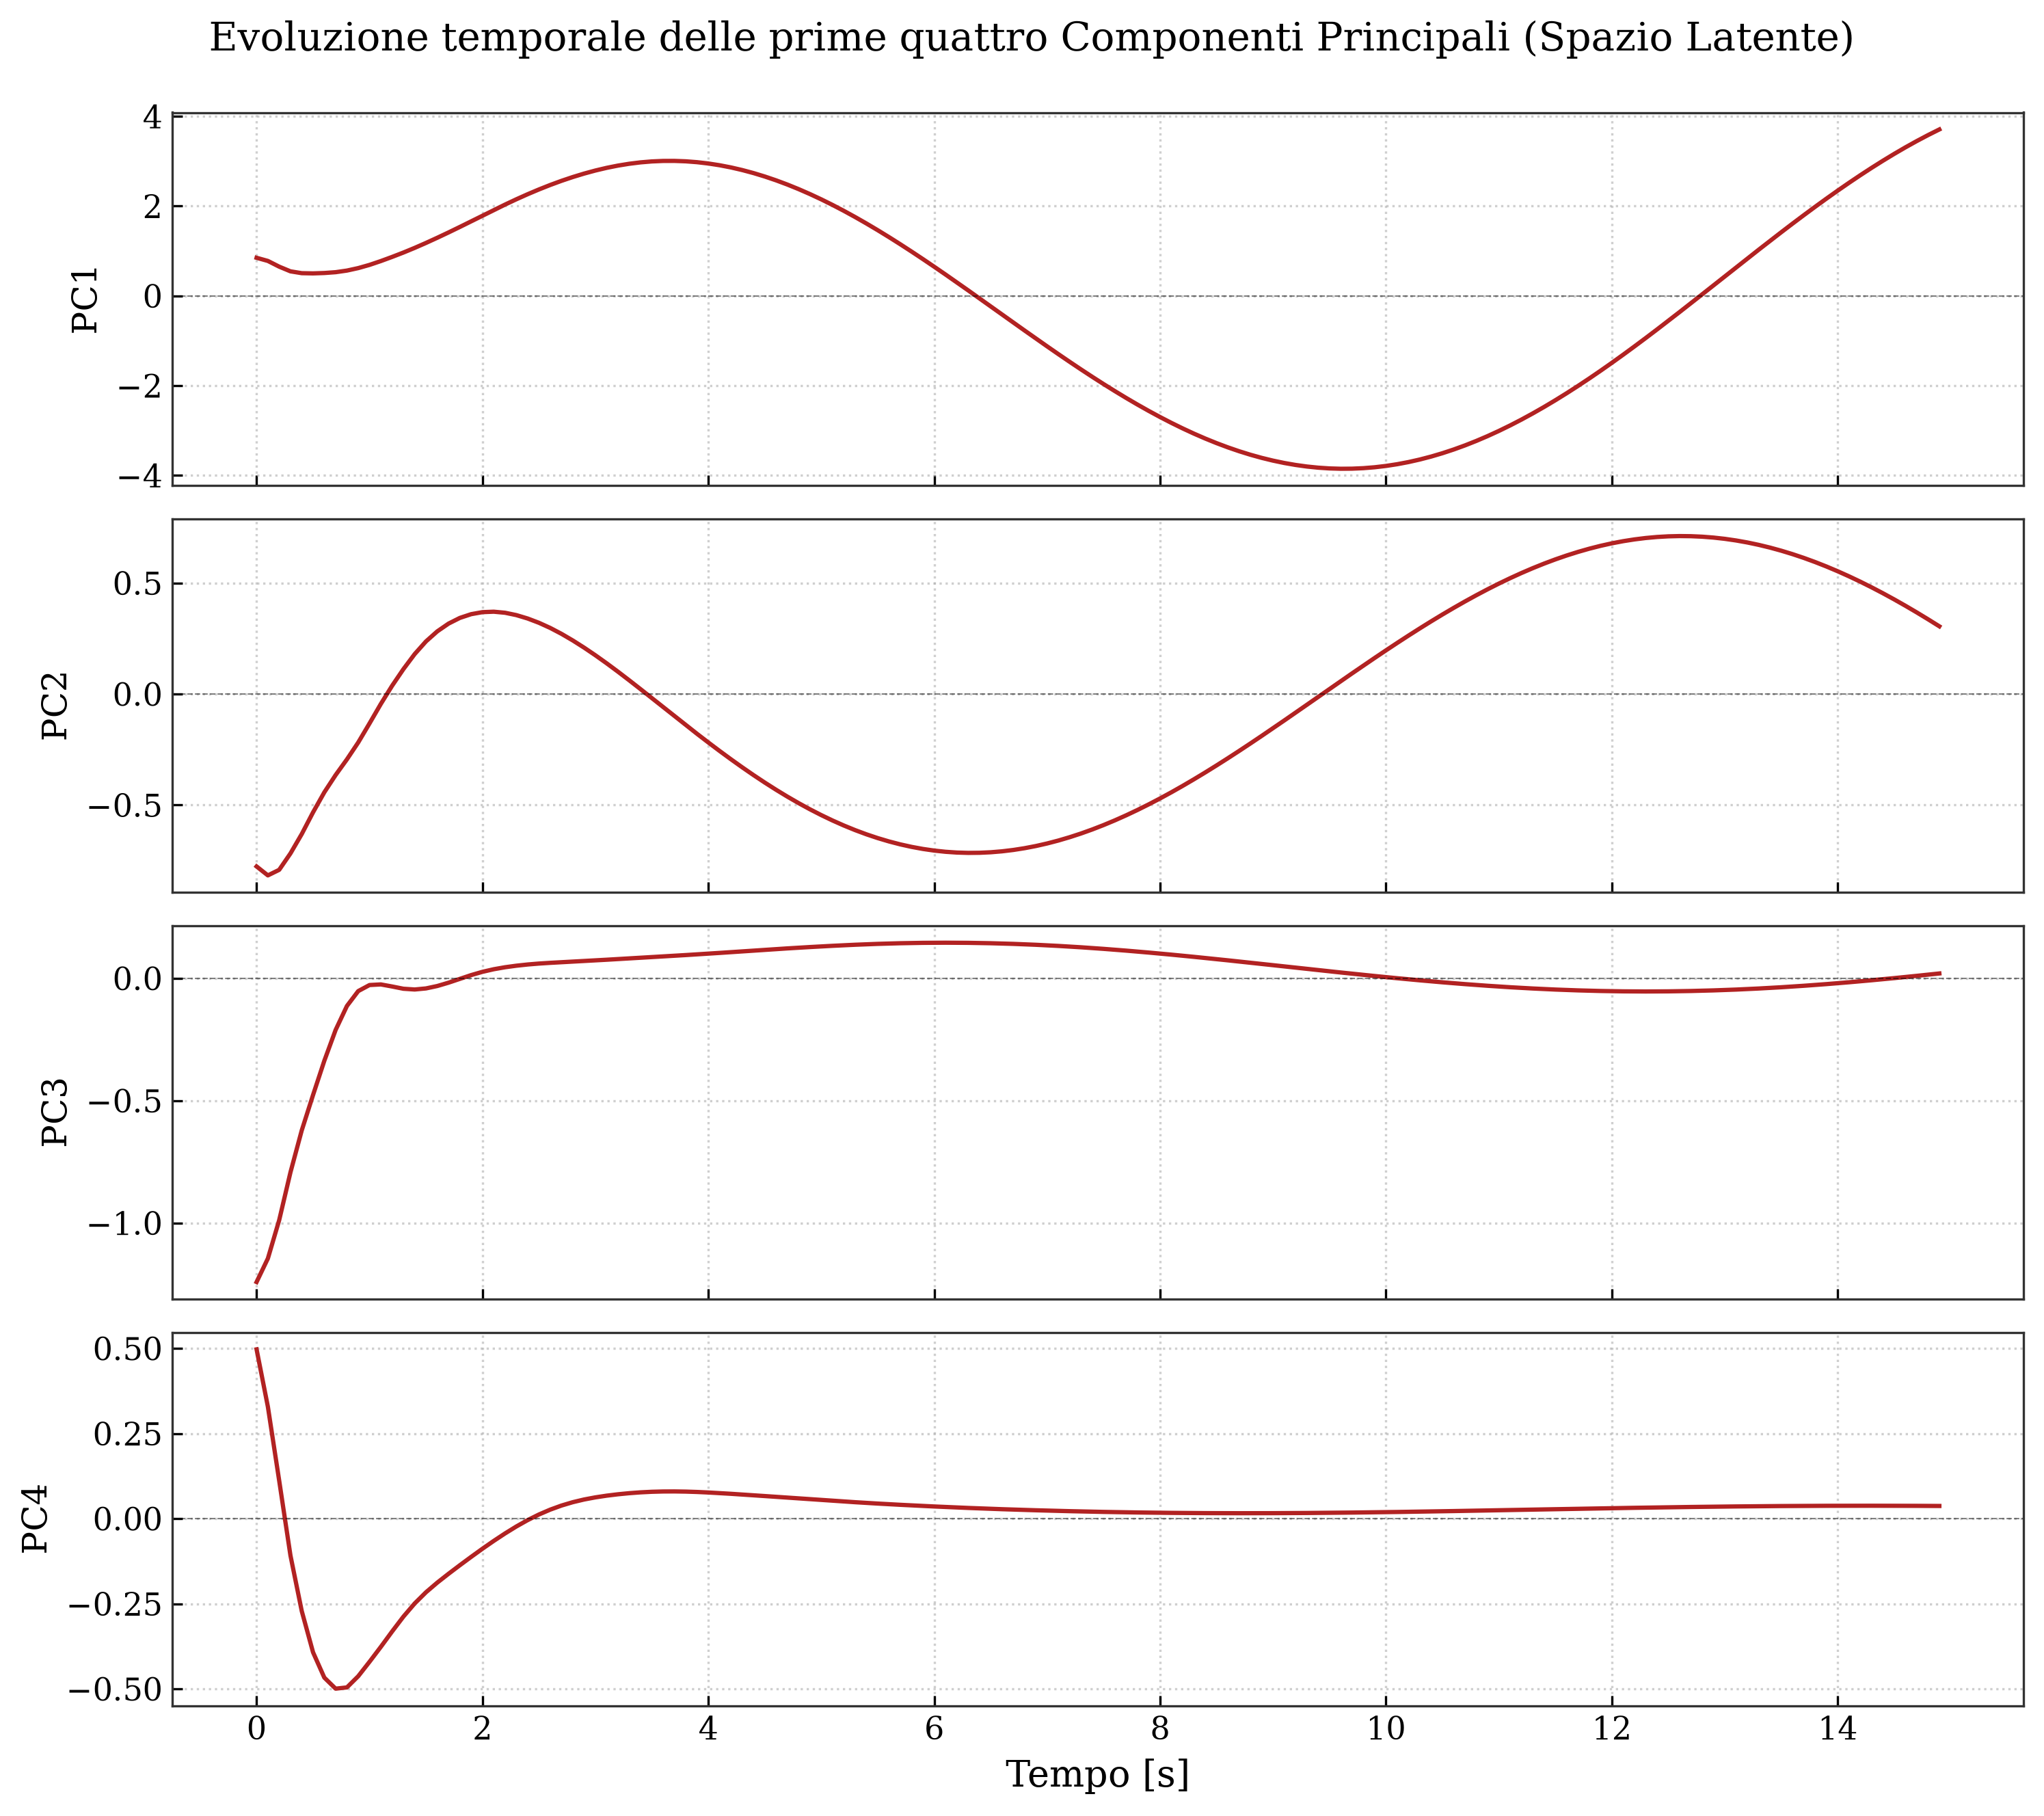

In [48]:
# =============================================================================
# 11.2 CORRELAZIONE E DINAMICA DELLE COMPONENTI PRINCIPALI
# =============================================================================
# 1. Estraiamo le proiezioni della PCA (coordinate latenti)
h_pca_breve = pca_breve.transform(h_train_breve_1d)

# 2. Dizionario delle variabili fisiche target nella stessa finestra temporale
physical_vars = {
    "x (Posizione Driver)": u_integrato[:n_train_breve, 0],
    "y (Posizione Slave)":  u_integrato[:n_train_breve, 1],
    "v_x (Velocità Driver)": u_integrato[:n_train_breve, 2],
    "v_y (Velocità Slave)":  u_integrato[:n_train_breve, 3]
}

# =============================================================================
# CALCOLO CORRELAZIONI DI PEARSON
# =============================================================================
print("=== CORRELAZIONE PRIME 4 PC CON LO STATO FISICO ===")
for i in range(4):
    print(f"\nPC{i+1} (Varianza: {var_ratio_breve[i]*100:.4f}%):")
    for name, signal in physical_vars.items():
        corr = np.corrcoef(h_pca_breve[:, i], signal)[0, 1]
        print(f"  corr({name:<22}) = {corr:+.4f}")
print("===================================================")

# =============================================================================
# EVOLUZIONE TEMPORALE DELLE PRIME 4 COMPONENTI PRINCIPALI
# =============================================================================
time_breve = np.arange(n_train_breve) * dt

fig, axes = plt.subplots(4, 1, figsize=(10, 9), dpi=300, sharex=True)

for i in range(4):
    axes[i].plot(time_breve, h_pca_breve[:, i], color='firebrick', linewidth=1.5)
    axes[i].set_ylabel(f"PC{i+1}", fontsize=12)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    # Evidenziamo lo zero per chiarezza
    axes[i].axhline(0, color='black', lw=0.5, ls='--', alpha=0.5)

axes[-1].set_xlabel("Tempo [s]", fontsize=13)

fig.suptitle("Evoluzione temporale delle prime quattro Componenti Principali (Spazio Latente)", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
#plt.savefig('pcavst_osa.pdf', dpi=300, bbox_inches='tight')
plt.show()

I coefficienti di correlazione di Pearson tra le prime quattro Componenti Principali e lo stato fisico del sistema mostrano che PC1 è fortemente correlata con la posizione dello Slave $y(t)$, con r=0.9801, mentre PC2 presenta una forte correlazione con la velocità dello Slave $v_y(t)$, con r=0.9042. Entrambe le componenti risultano inoltre correlate con variabili del Driver, evidenziando che la rappresentazione interna non costituisce una semplice copia dell'osservabile fornita in ingresso, ma una trasformazione ricorrente che combina informazione proveniente dalla storia temporale di $y(t)$.
Le componenti PC3 e PC4 contribuiscono complessivamente per circa lo 0.97% alla varianza totale, e non mostrano una correlazione lineare dominante con una singola variabile fisica. Non è pertanto possibile identificarle direttamente con i gradi di libertà dissipativi del sistema sulla base della sola PCA.

L'analisi dell'evoluzione temporale delle prime quattro Componenti Principali evidenzia inoltre una diversa struttura dinamica delle componenti. PC1 e PC2 mantengono un andamento oscillatorio persistente. PC3 e PC4 presentano invece una forte variazione concentrata nei primi secondi, seguita da un rapido avvicinamento a valori di piccola ampiezza. La scala temporale di tale decadimento è compatibile, a livello qualitativo, con il tempo caratteristico $2/\gamma$ della dinamica dissipativa dello Slave. Tale comportamento suggerisce che la rappresentazione interna separi in parte la componente oscillatoria persistente dalla componente transitoria della dinamica. Tuttavia, poiché le Componenti Principali sono direzioni di massima varianza e non autovettori dell'operatore dinamico, PC3 e PC4 non possono essere identificate direttamente con i singoli modi dissipativi. La loro interpretazione come contenitori di informazione associata al transitorio deve pertanto essere considerata come un'evidenza empirica, corroborata dal successivo recupero dei poli dissipativi attraverso l'inferenza spettrale.

Il confronto con l'inferenza spettrale mostra quindi anche che il contributo di una componente principale alla varianza non coincide necessariamente con la sua rilevanza per l'informazione dinamica.
Infatti è significativo che, nonostante la ridotta varianza di PC3 e PC4, l'analisi spettrale del reservoir riesca a recuperare con elevata accuratezza anche i due autovalori dissipativi. Questo risultato evidenzia che la PCA e l'inferenza spettrale caratterizzano proprietà differenti della rappresentazione interna: la prima ordina le direzioni in funzione della varianza statistica, mentre la seconda individua le strutture dinamiche necessarie a descrivere l'evoluzione temporale del sistema.

Possiamo quindi concludere che la rappresentazione del reservoir è statisticamente quasi bidimensionale, ma conserva informazione dinamica sufficiente a recuperare anche i modi dissipativi a bassa varianza.

# Visualizzazione dinamica dell'inferenza spettrale (animazioni)

Le analisi statiche precedenti hanno dimostrato la capacità della lRNN di inferire le frequenze naturali del sistema dinamico a valle dell'addestramento. Per comprendere più a fondo la fenomenologia dell'apprendimento e la natura fisica dei modi estratti, introduciamo in questa sezione una serie di visualizzazioni dinamiche.

L'obiettivo è osservare l'evoluzione dello spettro latente al variare di due parametri fondamentali:
1. **L'iperparametro di regolarizzazione $\lambda$ (Ridge Regression):** per visualizzare il processo spaziale di "ricerca e aggancio" dei poli fisici da parte del reservoir.
2. **Il tempo di osservazione (Sliding Window):** per fornire una dimostrazione empirica diretta della dissipazione modale.

In tutte le animazioni, gli autovalori del reservoir sono rappresentati nel piano complesso nel dominio continuo mediante $\lambda_C = \frac{\ln(\lambda_D)}{\Delta t}$, mentre il colore e la dimensione dei punti sono determinati dalla Mode Strength. La scala cromatica viene mantenuta fissa durante l'intera sequenza, così da rendere direttamente confrontabili i diversi fotogrammi.

## Animazione 1 — Evoluzione dell'inferenza spettrale al variare della Ridge Regression: 4D a regime

La regressione di Ridge (Tikhonov) introduce un termine di penalità $\lambda$ per evitare l'overfitting. Quando $\lambda \rightarrow \infty$, la rete è essenzialmente "spenta": i pesi di readout tendono a zero e i poli si posizionano sulla configurazione del reservoir libero. Riducendo progressivamente $\lambda$, i gradi di libertà vengono sbloccati, consentendo alla rete di accoppiarsi al segnale. L'animazione seguente mostra la migrazione degli autovalori nel piano complesso e la conseguente accensione delle Mode Strengths ($\overline{S}_i$) nel momento in cui il reservoir "aggancia" matematicamente il *ground truth* teorico.

Nello specifico: il parametro di regolarizzazione $\lambda$ viene fatto variare su una scala logaritmica, da valori molto elevati, $\lambda \sim 10^5$, fino a valori molto piccoli, $\lambda \sim 10^{-10}$. Per ciascun valore di $\lambda$ viene ricalcolata la matrice di readout $\mathbf{W}_{\mathrm{out}}$. Da questa vengono quindi ricostruiti l'operatore closed-loop, i relativi autovalori discreti e gli autovalori continui ottenuti mediante la mappatura logaritmica.
Per ogni configurazione viene inoltre ricalcolato il punto fisso della dinamica affine, e le Mode Strengths vengono valutate sulla traiettoria di training rispetto a tale punto fisso.
Nel grafico sono inoltre mantenuti come riferimento fisso gli autovalori del sistema teorico e la nube di autovalori del reservoir libero.

In [38]:
# =============================================================================
# 12.1 ANIMAZIONE DELL'APPRENDIMENTO (Variazione del parametro Ridge) - 4D REGIME
# =============================================================================
import os
import imageio.v2 as imageio # Usato per generare la GIF finale

# --- RIPRISTINO MEMORIA 4D ---
H_train_shifted = h_train[:-1]
Y_target_shifted = u_train[1:]
I = np.identity(N)
# ---------------------------------------------------------

cartella_out = "animazione_Ridge"
os.makedirs(cartella_out, exist_ok=True)

# 60 step logaritmici per lambda: da 10^5 (rete spenta) a 10^-10 (ottimo)
lams = np.logspace(5, -10, num=60)
frames_paths = []

fig = plt.subplots(figsize=(10, 7), dpi=150)[0] # Inizializziamo solo la figura

print(f"Inizio salvataggio di {len(lams)} frame nella cartella '{cartella_out}'...")

for idx, lam in enumerate(lams):
    fig.clf() # Pulisce intera figura (assi e colorbar inclusi) per evitare sovrapposizioni
    ax = fig.add_subplot(111)
    
    # 1. Calcolo di Wout con il lambda corrente
    Wout_corrente = ridge_regression(H_train_shifted, Y_target_shifted, alpha=lam)
    
    # 2. Ricalcolo della dinamica spettrale
    W_tot_corrente = W + Win @ Wout_corrente
    W_eff_D_corrente = I + alpha * (W_tot_corrente - I) 
    
    lambda_D_corrente, V_corrente = la.eig(W_eff_D_corrente)
    lambda_C_corrente = np.log(lambda_D_corrente) / dt
    
    # 3. Ricalcolo delle Mode Strengths
    M_corrente = W_eff_D_corrente
    d = alpha * b
    h_star_corrente = la.solve(I - M_corrente, d)
    
    S_corrente = compute_time_averaged_mode_strengths(V=V_corrente, 
                                                      trajectory=h_train, 
                                                      fixed_point=h_star_corrente, 
                                                      observation_matrix=Wout_corrente)
    
    # --- PLOTTING DEL FRAME ---
    ax.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), 
               s=15, color="gray", alpha=0.3, zorder=1)
    
    ax.scatter(np.real(lambda_A), np.imag(lambda_A), 
               marker='x', s=200, color='black', linewidths=2, zorder=2)
    
    scatter = ax.scatter(np.real(lambda_C_corrente), np.imag(lambda_C_corrente), 
                         c=S_corrente, cmap='coolwarm', 
                         s=20 + 150 * np.clip(S_corrente / S_max, 0, 1.2), 
                         alpha=0.9, edgecolors='k', linewidth=0.5, zorder=3,
                         vmin=0, vmax=S_max)
    
    # Assi e limiti
    ax.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.set_xlim(-4, 0.5)
    ax.set_ylim(-3, 3)
    
    ax.set_xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
    ax.set_ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
    
    # Colorbar coerente
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.03)
    cbar.set_label(r'Mode Strength ($\overline{S}_i$)', rotation=270, labelpad=20, fontsize=13)
    
    titolo = rf"Ridge Regression 4D: $\lambda$ = {lam:.1e}"
    ax.set_title(titolo, fontsize=14, pad=15)
    
    # Salvataggio
    nome_file = os.path.join(cartella_out, f"frame_{idx:03d}.png")
    plt.tight_layout()
    plt.savefig(nome_file, bbox_inches='tight')
    frames_paths.append(nome_file)

plt.close(fig) 

# --- GENERAZIONE GIF ---
print("Compilazione della GIF in corso...")
gif_path = os.path.join(cartella_out, "animazione_ridge_4d.gif")
with imageio.get_writer(gif_path, mode='I', duration=0.15) as writer:
    for filename in frames_paths:
        image = imageio.imread(filename)
        writer.append_data(image)
print(f"GIF salvata con successo in: {gif_path}")

Inizio salvataggio di 60 frame nella cartella 'animazione_Ridge'...
Compilazione della GIF in corso...
GIF salvata con successo in: animazione_Ridge/animazione_ridge_4d.gif


## Animazione 2 — Decadimento temporale dei modi con sliding window: 4D transitorio $\rightarrow$ regime

La formulazione temporale della Mode Strength ($\overline{S}_i$) evidenzia come l'energia associata ai modi dissipativi non sia costante, bensì decada nel tempo allontanandosi dalle condizioni iniziali. Per visualizzare esplicitamente questo fenomeno, calcoliamo l'inferenza spettrale su una finestra temporale mobile (*sliding window*). 
Mentre la finestra scorre verso il regime stazionario, si osserva lo spegnimento progressivo (decadimento termodinamico) dei poli dello *Slave*, lasciando attivi ed evidenti unicamente i poli persistenti del *Driver* ancorati sull'asse immaginario.

A differenza della precedente animazione, in questo caso l'operatore closed-loop e la matrice di readout sono mantenuti fissi. Ciò che varia è esclusivamente la finestra temporale sulla quale vengono calcolate le Mode Strengths.

Viene utilizzata una finestra di ampiezza $\Delta t = 15\mathrm{s}$, che viene fatta scorrere lungo la traiettoria con un avanzamento di cinque campioni, corrispondente a $0.5\mathrm{s}$.

Per ogni posizione della finestra viene calcolata la Mode Strength mediata temporalmente, utilizzando il medesimo punto fisso della dinamica affine.
La posizione degli autovalori nel piano complesso non cambia durante l'animazione: varia invece la loro rilevanza dinamica osservata, quantificata dalla Mode Strength nella finestra temporale corrente.


In [39]:
# =============================================================================
# 12.2 ANIMAZIONE DECADIMENTO MODALE (Sliding Window)
# =============================================================================

cartella_out_1 = "animazione_sliding_window"
os.makedirs(cartella_out_1, exist_ok=True)

# Generiamo una traiettoria lunga che parta da t=0 (SENZA spin-up), 
# usando l'input 4D completo (u_integrato)
h_decay = open_loop(u_integrato, np.zeros(N), W, Win, b, alpha)
window_size = 150 # Finestra di 15 secondi fisici
step_size = 5     # Scorrimento di 0.5 secondi

max_start = len(h_train) - window_size
starts = np.arange(0, max_start, step_size)
frames_paths_sw = []

fig = plt.subplots(figsize=(10, 7), dpi=150)[0]
print(f"Inizio salvataggio di {len(starts)} frame nella cartella '{cartella_out_1}'...")

for idx, start in enumerate(starts):
    fig.clf()
    ax = fig.add_subplot(111)
    
    h_window = h_decay[start : start + window_size]
    
    d = alpha * b
    h_star_breve = la.solve(np.eye(N) - W_eff_D_breve, d)
    
    # Usiamo le matrici _breve (addestrate sul transitorio 4D)
    S_window = compute_time_averaged_mode_strengths(V=V_breve, 
                                                    trajectory=h_window, 
                                                    fixed_point=h_star_breve, 
                                                    observation_matrix=Wout_breve)
    
    # --- PLOTTING ---
    ax.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), s=15, color="gray", alpha=0.3, zorder=1)
    ax.scatter(np.real(lambda_A), np.imag(lambda_A), marker='x', s=200, color='black', linewidths=2, zorder=2)
    
    scatter = ax.scatter(np.real(lambda_C_breve), np.imag(lambda_C_breve), 
                         c=S_window, cmap='coolwarm', 
                         s=20 + 150 * np.clip(S_window / S_max_breve, 0, 1.2), 
                         alpha=0.9, edgecolors='k', linewidth=0.5, zorder=3,
                         vmin=0, vmax=S_max_breve)
                         
    ax.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.set_xlim(-3, 0.5)
    ax.set_ylim(-3, 3)
    ax.set_xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
    ax.set_ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.03)
    cbar.set_label(r'Mode Strength ($\overline{S}_i$)', rotation=270, labelpad=20, fontsize=13)
    
    tempo_fisico = start * dt
    ax.set_title(rf"Decadimento Modale (Finestra: $t$ = {tempo_fisico:.1f}s $\to$ {tempo_fisico + window_size*dt:.1f}s)", fontsize=14, pad=15)
    
    nome_file = os.path.join(cartella_out_1, f"frame_{idx:03d}.png")
    plt.tight_layout()
    plt.savefig(nome_file, bbox_inches='tight')
    frames_paths_sw.append(nome_file)

plt.close(fig)

# --- GENERAZIONE GIF ---
print("Compilazione della GIF in corso...")
gif_path_sw = os.path.join(cartella_out_1, "animazione_decadimento.gif")
with imageio.get_writer(gif_path_sw, mode='I', duration=0.1) as writer: # Più fluido (0.1) per lo scorrimento
    for filename in frames_paths_sw:
        image = imageio.imread(filename)
        writer.append_data(image)
print(f"GIF salvata con successo in: {gif_path_sw}")

Inizio salvataggio di 170 frame nella cartella 'animazione_sliding_window'...
Compilazione della GIF in corso...
GIF salvata con successo in: animazione_sliding_window/animazione_decadimento.gif


## Animazione 3 — Evoluzione dell'inferenza spettrale al variare della ridge regression: 1D transitorio

La terza animazione analizza il caso più restrittivo: l'esperimento di ablazione spaziale. Replichiamo qui lo studio del parametro $\lambda$, applicato questa volta alla rete che ascolta esclusivamente l'osservabile unidimensionale durante il transitorio.

Anche in questo caso il parametro di regolarizzazione della ridge regression viene fatto variare su una scala logaritmica, $\lambda\in[10^{-14},10^5]$, e, per ogni valore, viene ricalcolata la matrice di readout, la dinamica closed-loop e l'intero spettro del reservoir. Per ciascun valore di $\lambda$ viene inoltre determinato il punto fisso associato alla dinamica affine e le Mode Strengths vengono calcolate utilizzando la traiettoria transitoria e la matrice di osservazione scalare fornita dal readout $1D$.

In [40]:
# =============================================================================
# 12.3 ANIMAZIONE DELL'APPRENDIMENTO (Variazione del Ridge) - 1D TRANSITORIO
# =============================================================================

cartella_out_2 = "animazione_ridge_1d4d"
os.makedirs(cartella_out_2, exist_ok=True)

lams = np.logspace(5, -14, num=60)
frames_paths_1d = []

fig = plt.subplots(figsize=(10, 7), dpi=150)[0]
print(f"Inizio salvataggio di {len(lams)} frame nella cartella '{cartella_out_2}'...")

for idx, lam in enumerate(lams):
    fig.clf()
    ax = fig.add_subplot(111)
    
    Wout_curr_raw = ridge_regression(H_train_shifted_breve_1d, Y_target_shifted_breve_1d, alpha=lam)
    Wout_curr = Wout_curr_raw.reshape(1, N)
    
    W_tot_curr = W + Win_1d @ Wout_curr
    W_eff_curr = np.identity(N) + alpha * (W_tot_curr - np.identity(N))
    
    lambda_D_curr, V_curr = la.eig(W_eff_curr)
    lambda_C_curr = np.log(lambda_D_curr) / dt
    
    d = alpha * b
    h_star_curr = la.solve(np.identity(N) - W_eff_curr, d)
    
    S_curr = compute_time_averaged_mode_strengths(V=V_curr, 
                                                  trajectory=h_train_breve_1d, 
                                                  fixed_point=h_star_curr, 
                                                  observation_matrix=Wout_curr)
    
    # --- PLOTTING ---
    ax.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), s=15, color="gray", alpha=0.3, zorder=1)
    ax.scatter(np.real(lambda_A), np.imag(lambda_A), marker='x', s=200, color='black', linewidths=2, zorder=2)
    
    scatter = ax.scatter(np.real(lambda_C_curr), np.imag(lambda_C_curr), 
                         c=S_curr, cmap='coolwarm', 
                         s=20 + 150 * np.clip(S_curr / S_max_breve1d, 0, 1.2), 
                         alpha=0.9, edgecolors='k', linewidth=0.5, zorder=3,
                         vmin=0, vmax=S_max_breve1d) 
    
    ax.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.set_xlim(-3, 0.5)
    ax.set_ylim(-3, 3)
    ax.set_xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
    ax.set_ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.03)
    cbar.set_label(r'Mode Strength ($\overline{S}_{i, 1D}$)', rotation=270, labelpad=20, fontsize=13)
    
    titolo = rf"Inferenza Spettrale 1D $\rightarrow$ 4D: $\lambda$ = {lam:.1e}"
    ax.set_title(titolo, fontsize=14, pad=15)
    
    nome_file = os.path.join(cartella_out_2, f"frame_{idx:03d}.png")
    plt.tight_layout()
    plt.savefig(nome_file, bbox_inches='tight')
    frames_paths_1d.append(nome_file)

plt.close(fig) 

# --- GENERAZIONE GIF ---
print("Compilazione della GIF in corso...")
gif_path_1d = os.path.join(cartella_out_2, "animazione_ridge_1d.gif")
with imageio.get_writer(gif_path_1d, mode='I', duration=0.15) as writer:
    for filename in frames_paths_1d:
        image = imageio.imread(filename)
        writer.append_data(image)
print(f"GIF salvata con successo in: {gif_path_1d}")

Inizio salvataggio di 60 frame nella cartella 'animazione_ridge_1d4d'...
Compilazione della GIF in corso...
GIF salvata con successo in: animazione_ridge_1d4d/animazione_ridge_1d.gif
